# Problem Statement - INN Hotels

### **Problem Statements**

**Context**

A significant number of hotel bookings are called off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impacts a hotel on various fronts:
1. Loss of resources (revenue) when the hotel cannot resell the room.
2. Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
3. Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
4. Human resources to make arrangements for the guests.



**Objective**

The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.



**Data Description**

The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.



**Data Dictionary**

* **Booking_ID :**  the unique identifier of each booking
* **no_of_adults :** Number of adults
* **no_of_children :** Number of Children
* **no_of_weekend_nights :** Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* **no_of_week_nights :** Number of weeknights (Monday to Friday) the guest stayed or booked to stay at the hotel
* **type_of_meal_plan :** Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* **required_car_parking_space :** Does the customer require a car parking space? (0 - No, 1- Yes)
* **room_type_reserved :** Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels Group
* **lead_time :** Number of days between the date of booking and the arrival date
* **arrival_year :** Year of arrival date
* **arrival_month :** Month of arrival date
* **arrival_date :** Date of the month
* **market_segment_type :** Market segment designation.
* **repeated_guest :** Is the customer a repeated guest? (0 - No, 1- Yes)
* **no_of_previous_cancellations :** Number of previous bookings that were canceled by the customer before the current booking
* **no_of_previous_bookings_not_canceled :** Number of previous bookings not canceled by the customer before the current booking
* **avg_price_per_room :** Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* **no_of_special_requests :** Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* **booking_status :** Flag indicating if the booking was canceled or not.



## **Importing the necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom
from scipy.stats import norm
from scipy.stats import t
import scipy.stats as stats

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from scipy.stats import zscore
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
  )

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

## **Loading the dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# read the data from the drive
file_path = r"/content/drive/MyDrive/INNHotelsGroup.csv"
data = pd.read_csv(file_path)

## **Data Overview**

#### **Create a copy of the data**

In [4]:
# let's create a copy of the data to avoid any changes to original data
df = data.copy()

#### **Displaying the first & last few rows of the dataset**

In [5]:
# view the first 5 rows
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [6]:
# view the last 5 rows
df.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


#### **Checking 10 random rows of the dataset**

In [7]:
df.sample(n=10, random_state=1)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
30392,INN30393,1,0,1,0,Not Selected,0,Room_Type 1,53,2018,9,11,Online,0,0,0,94.32,0,Not_Canceled
6685,INN06686,2,0,1,2,Meal Plan 1,0,Room_Type 1,63,2018,4,22,Online,0,0,0,105.30,1,Canceled
8369,INN08370,2,0,2,3,Meal Plan 1,0,Room_Type 4,55,2018,9,11,Online,0,0,0,106.24,0,Not_Canceled
2055,INN02056,2,0,0,2,Not Selected,0,Room_Type 1,53,2017,12,29,Online,0,0,0,81.00,1,Not_Canceled
10969,INN10970,1,0,2,4,Meal Plan 1,0,Room_Type 1,245,2018,7,6,Offline,0,0,0,110.00,0,Canceled
24881,INN24882,2,0,3,7,Meal Plan 1,0,Room_Type 2,231,2018,8,1,Online,0,0,0,81.82,2,Canceled
28658,INN28659,2,0,0,3,Meal Plan 2,0,Room_Type 1,71,2018,5,10,Offline,0,0,0,126.00,1,Not_Canceled
20853,INN20854,2,0,1,2,Meal Plan 1,0,Room_Type 1,66,2017,10,9,Offline,0,0,0,75.00,0,Canceled
8501,INN08502,2,0,0,3,Meal Plan 1,0,Room_Type 2,40,2018,1,14,Online,0,0,0,77.55,1,Not_Canceled
1942,INN01943,2,0,0,2,Meal Plan 1,0,Room_Type 1,63,2018,8,9,Online,0,0,0,144.90,2,Not_Canceled


#### **Checking the shape of the dataset**

In [8]:
# Checking how many rows and columns are present in the data
df.shape

(36275, 19)

##### Observations:
* There are `36275 rows` & `19 columns` in the given dataset.

#### **Checking the data types of the columns for the dataset**

In [9]:
# inspecting the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [10]:
# group by data type
df.dtypes.value_counts()

,count
int64,13
object,5
float64,1


##### Observations:
* *`5 columns`* are of the `object` type columns and *`13 columns`* are of `numerical` type columns.
* The `avg_price_per_room` column is continous in nature.
* All the columns have `36275 observations`, which means none of the columns has `null values`.

#### **Statistical summary of the dataset**

In [11]:
# Checking the statistical summary of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


##### Observations:

* `no_of_adults:` The majority of bookings involve 1 or 2 adults, as reflected by the mean and median being close to 2. The maximum number of adults in a booking is 4.

* `no_of_children:` On average, there are very few children accompanying the guests, with a mean of approximately 0.1. Most bookings do not include children, and the maximum number of children in a booking is 10.

* `required_car_parking_space:` The majority of bookings do not require a car parking space.

* `lead_time:` The average lead time between booking and arrival is about 85 days. The distribution is positively skewed, with the median at 57 days being lower than the mean.

* `arrival_year:` The majority of bookings occurred in the year 2018, as both the mean and median are 2018.

* `repeated_guest:` A small percentage of guests are repeated guests, reflected by the mean value of 0.03.

* `avg_price_per_room:` The average price per room is approximately €103.42. The minimum price is €0, suggesting the presence of free or special-priced bookings, while the maximum price is €540, indicating high-priced rooms in some bookings.

* `no_of_special_requests:` On average, guests make around 0.6 special requests per booking. The distribution is positively skewed, with the median being 0 and a maximum of 5 special requests.

#### **Checking for null values**

In [12]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


##### Observations:

* As we can see, all the columns has `0 missing values`. It means, there are no missing values in the data.

#### **Checking for duplicate values**

In [13]:
df.duplicated().sum()

0

##### Observations:
* There are *`no duplicate`* values in the data.

## **Exploratory Data Analysis (EDA)**

### **Model Support Functions**

In [14]:
# function to create both Histogram & Box-Plot

def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        # data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
        data=data, x=feature, ax=ax_box2, showmeans=True
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        # data[feature].mean(), color="green", linestyle="--"
        data[feature].mean(), linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        # data[feature].median(), color="black", linestyle="-"
        data[feature].median(), linestyle="-"
    )  # Add median to the histogram

In [15]:
# function to create Barplot

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top
    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="deep",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = int(p.get_height())  # count of each level of the category without decimals

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [16]:
def stacked_barplot(data, predictor, target):
    """
    Return category counts as a DataFrame with Canceled and Not_Canceled percentages and plot a stacked bar chart.

    Parameters:
    data: DataFrame
        The dataset to analyze.
    predictor: str
        The independent variable (x-axis).
    target: str
        The target variable (used for stacked bars).

    Returns:
    pd.DataFrame
        A DataFrame showing category counts with margins and percentage columns.
    """
    # Generate crosstab DataFrame and plot with counts
    crosstab_df = pd.crosstab(data[predictor], data[target])
    crosstab_df.plot(
        kind="bar", stacked=True, figsize=(10, 6), alpha=0.8, color=["#1f77b4", "#ff7f0e"]
    )

    # Add totals on top of bars
    for index, row in enumerate(crosstab_df.values):
        total = sum(row)
        plt.text(index, total + 0.02, str(total), ha="center", fontsize=10)

    # Add legend and labels
    plt.title(f"Stacked Bar Chart: {predictor} vs {target}")
    plt.ylabel("Count")
    plt.xlabel(predictor)
    plt.legend(title=target, loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()
    print()

    # Calculate totals and percentages
    crosstab_df["All"] = crosstab_df.sum(axis=1)
    if "Canceled" in crosstab_df.columns:
        crosstab_df["Canceled(%)"] = (
            (crosstab_df["Canceled"] / crosstab_df["All"]) * 100
        ).round(2)
    if "Not_Canceled" in crosstab_df.columns:
        crosstab_df["Not_Canceled(%)"] = (
            (crosstab_df["Not_Canceled"] / crosstab_df["All"]) * 100
        ).round(2)

    return crosstab_df

In [17]:
# function to plot distributions wrt target

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [18]:
def line_plot(data, numerical_col, categorical_col):
  """
  Creates a line plot to visualize the distribution of a numerical column
  against a categorical column. Automatically handles x-tick labels.

  Args:
      data: The input DataFrame.
      numerical_col: The name of the numerical column.
      categorical_col: The name of the categorical column.
  """
  # Create a pivot table to aggregate the numerical column for each category
  pivot_table = pd.pivot_table(
      data,
      values=numerical_col,
      index=categorical_col,
      aggfunc='mean'
  )

  # Create the line plot using seaborn
  sns.lineplot(data=pivot_table)

  # Customize the plot
  plt.title(f'Average {numerical_col} Trend Across {categorical_col}')
  plt.xlabel(categorical_col)
  plt.ylabel(numerical_col)

  # Automatically set x-axis tick labels based on categorical column values
  plt.xticks(pivot_table.index, pivot_table.index)  # Use index values as labels

  plt.show()

In [19]:
def line_plot_with_two_lines(df, index_col, columns_col, values_col='Booking_ID'):
  """
  Creates a line plot to visualize the booking status trend across a specified index column.
  Automatically handles x-tick labels.

  Args:
      df: The input DataFrame.
      index_col: The name of the column to use as the index (x-axis).
      columns_col: The name of the column to use for creating separate lines (booking status).
      values_col: The name of the column to aggregate (count of bookings). Defaults to 'Booking_ID'.
  """
  # Create a pivot table to aggregate booking counts
  pivot_table = pd.pivot_table(
      df,
      values=values_col,
      index=index_col,
      columns=columns_col,
      aggfunc='count',
      fill_value=0
  )

  # Rename columns if 'booking_status' is the columns_col
  if columns_col == 'booking_status':
    pivot_table = pivot_table.rename(
        columns={'Canceled': 'Canceled', 'Not_Canceled': 'Not_Canceled'}
    )

  # Create the line plot using seaborn
  sns.lineplot(data=pivot_table)

  # Customize the plot
  plt.title(f'Booking Status Trend Across {index_col.title()}')
  plt.xlabel(index_col.title())
  plt.ylabel('Number of Bookings')

  # Automatically set x-axis tick labels based on index column values
  plt.xticks(pivot_table.index, pivot_table.index)

  if columns_col == 'booking_status':
      plt.legend(title='Booking Status')
  else:
      plt.legend(title=columns_col.title())  # Use a generic legend title if columns_col is not 'booking_status'

  plt.show()

### Univariate Analysis

#### Distribution of **`no_of_adults`** *(Numerical Column)*

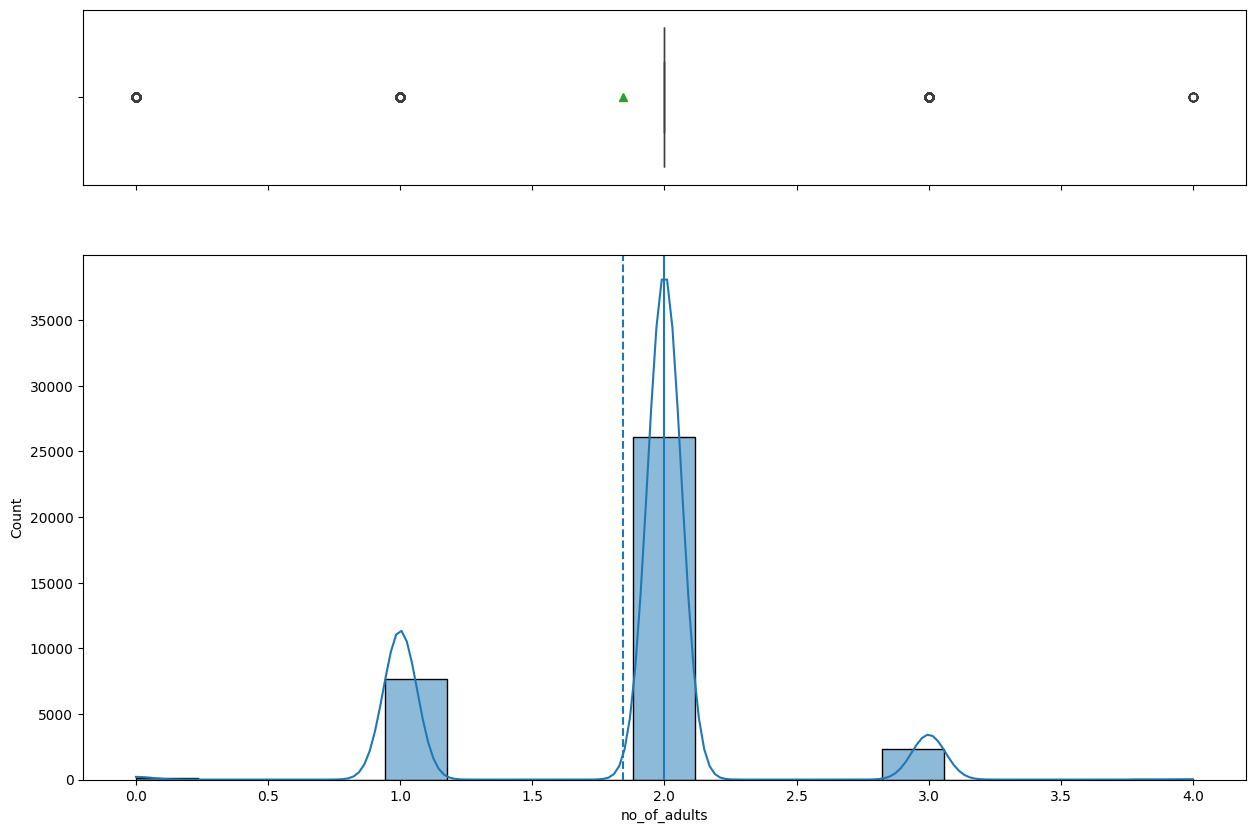

In [20]:
histogram_boxplot(df, "no_of_adults", kde=True)

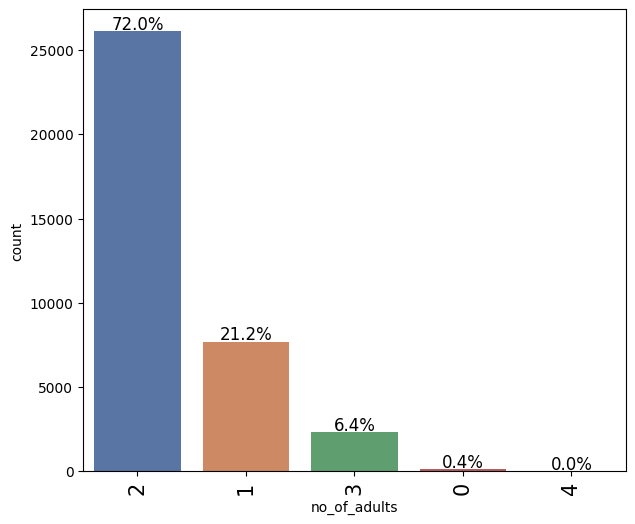

In [21]:
labeled_barplot(df, 'no_of_adults', perc=True);

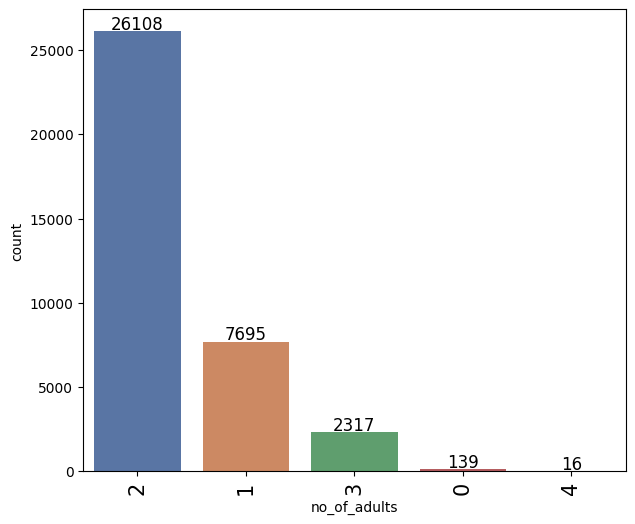

In [22]:
labeled_barplot(df, 'no_of_adults');

##### Observations:

* The highest number of bookings, `approximately 72%`, is for `2 adults`, followed by `1 adult` at around `21.2%`, and `3 adults` at about `6.4%`, and so on.

* The *`mean`* of *`no_of_adults`* is `1.844962`, indicating that, on average, there are `approximately 2 adults` per booking.

#### Distribution of **`no_of_children`** *(Numerical Column)*

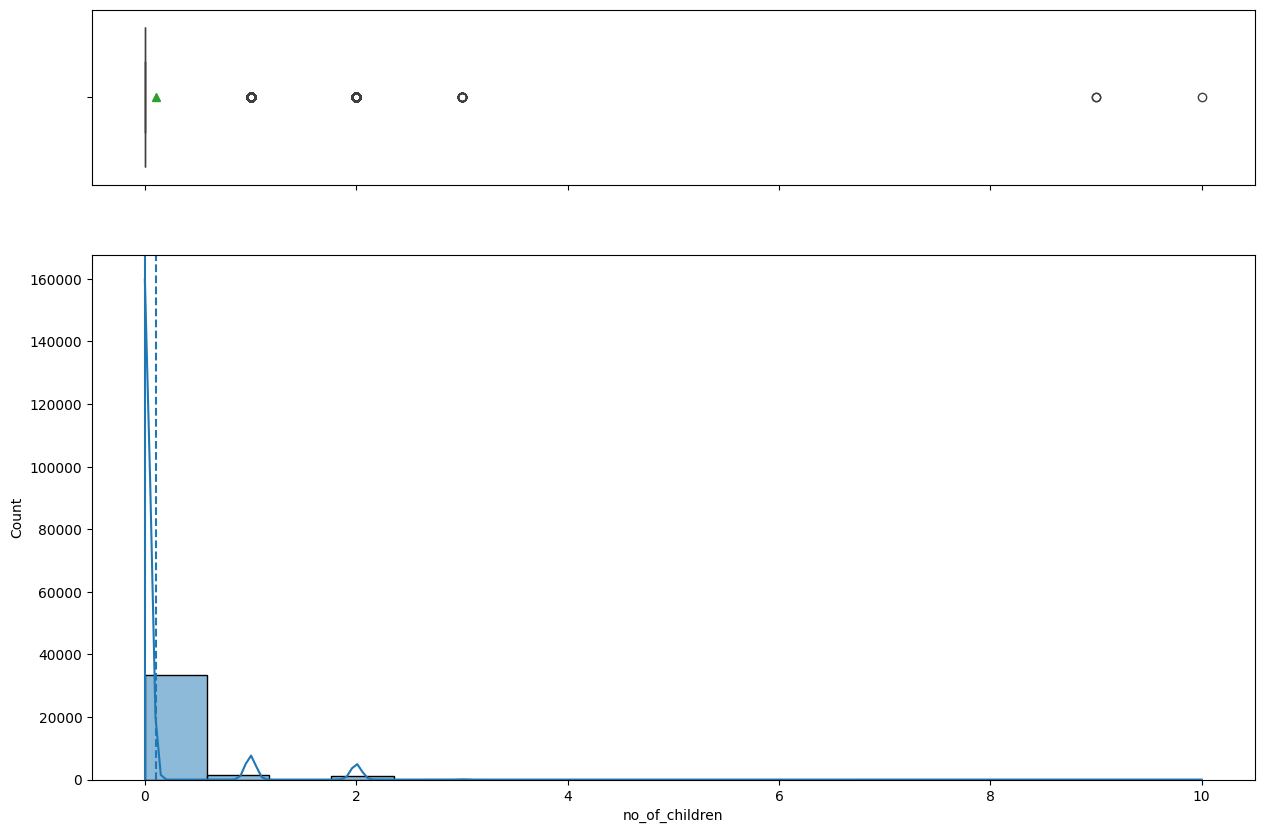

In [23]:
histogram_boxplot(df, "no_of_children", kde=True)

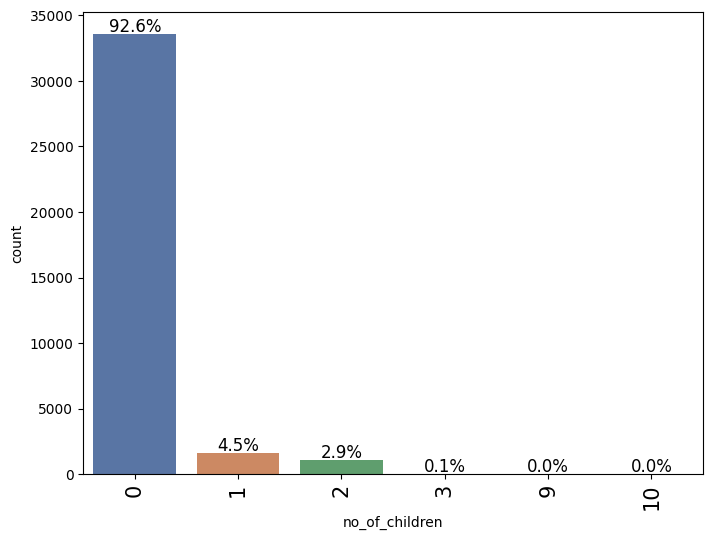

In [24]:
labeled_barplot(df, 'no_of_children', perc=True);

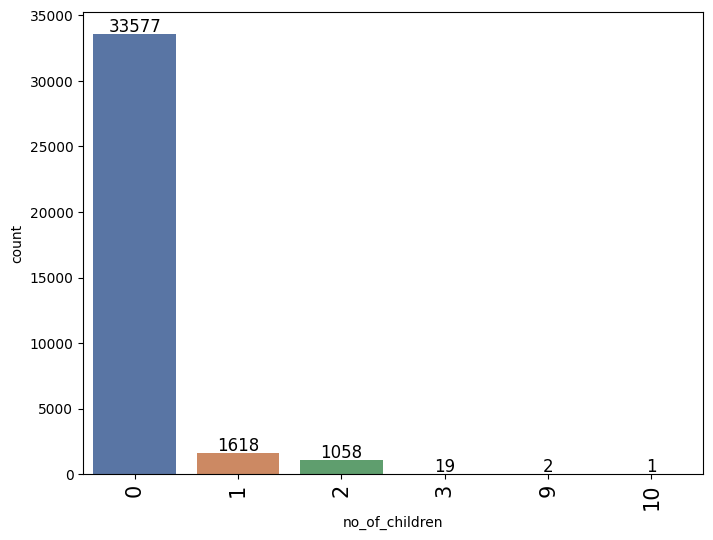

In [25]:
labeled_barplot(df, 'no_of_children');

##### Observations:

* `33577 bookings` (approximately `92.6%` of the data) fall under 0 `no_of_children`.

* The `no_of_children` variable has a right-skewed distribution with outliers.

* Some outliers include data points with `9 and 10` no_of_children.

* The mean of `no_of_children` is `0.105279`, which is very `close to zero`, reflecting that most observations have `no children`.

#### Distribution of **`no_of_weekend_nights`** *(Numerical Column)*

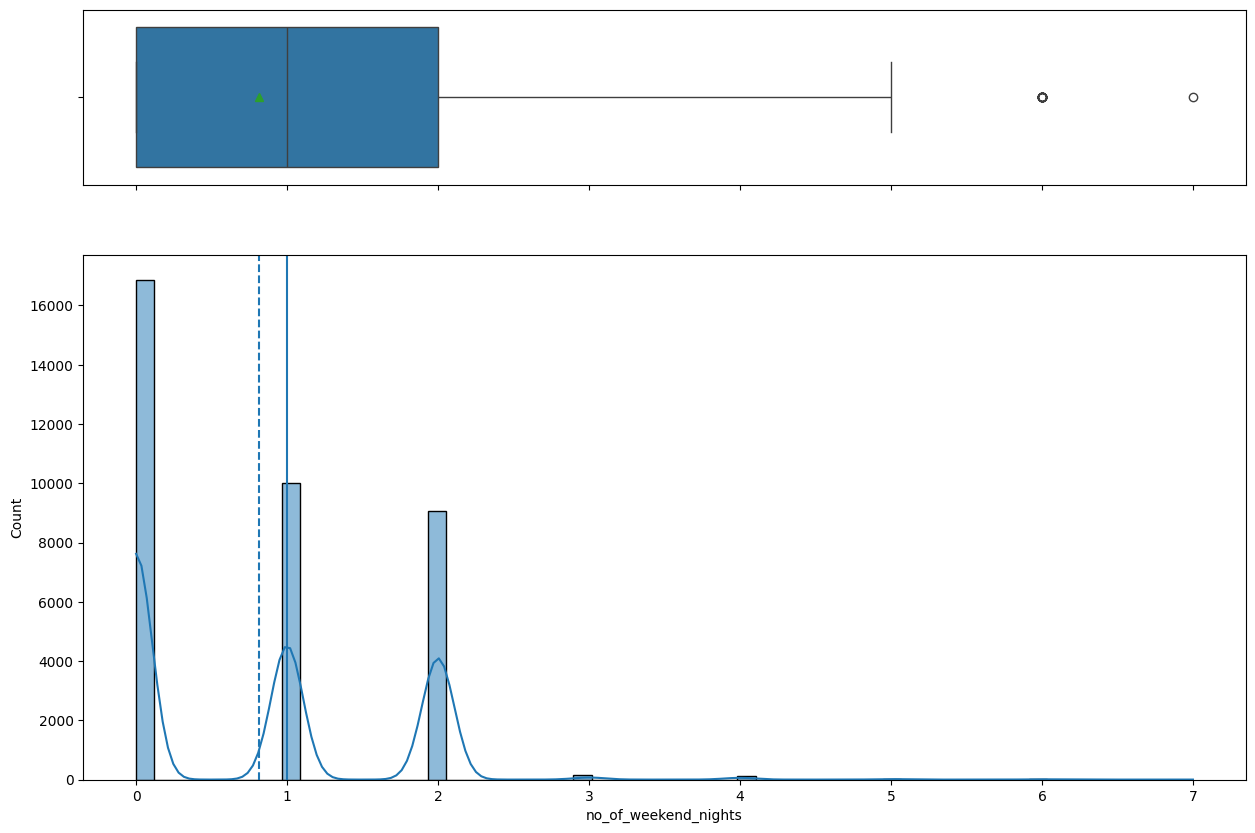

In [26]:
histogram_boxplot(df, "no_of_weekend_nights", kde=True)

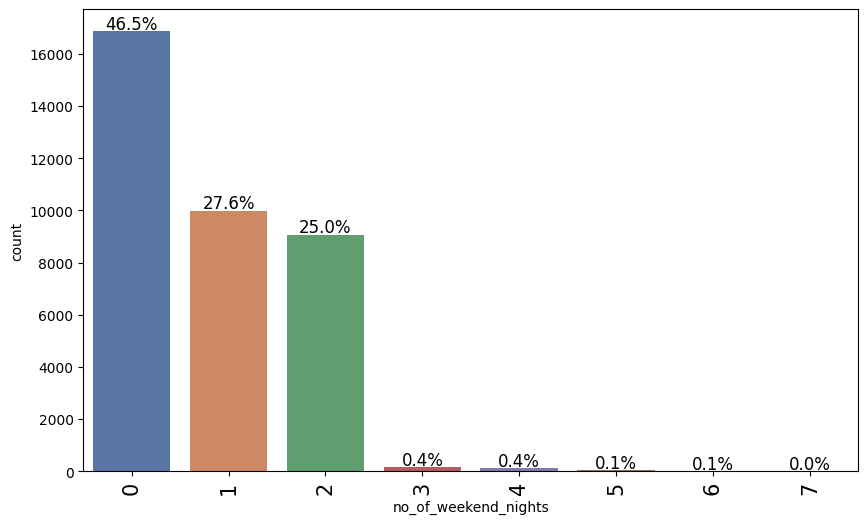

In [27]:
labeled_barplot(df, 'no_of_weekend_nights', perc=True);

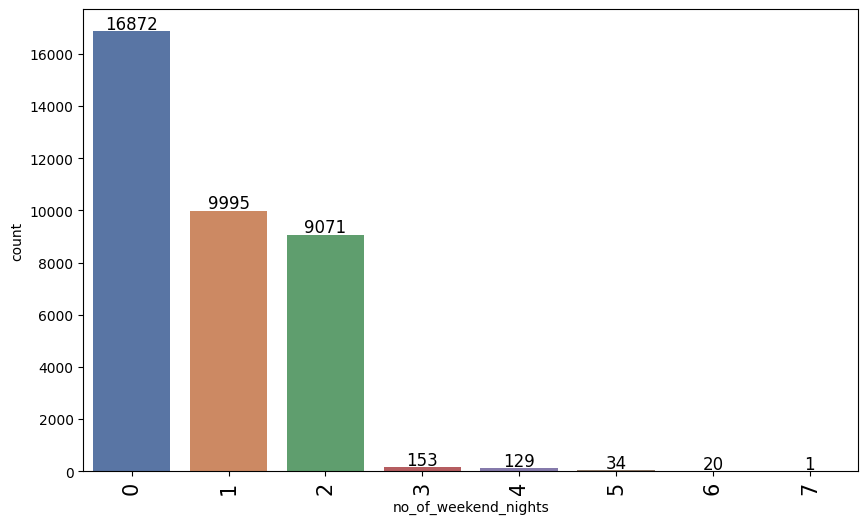

In [28]:
labeled_barplot(df, 'no_of_weekend_nights');

##### Observations:
* The `no_of_weekend_nights` variable has a right-skewed distribution with outliers.

* Some outliers include data points with more than 5 `no_of_weekend_nights`.

*  The *`mean`* of *`no_of_weekend_nights`* is `0.810724`, indicating that, on average, there is `around 1 weekend night` per observation.

* Approximately `46.5%` of the bokings `do not` included a night during `the weekend`.

#### Distribution of **`no_of_week_nights`** *(Numerical Column)*

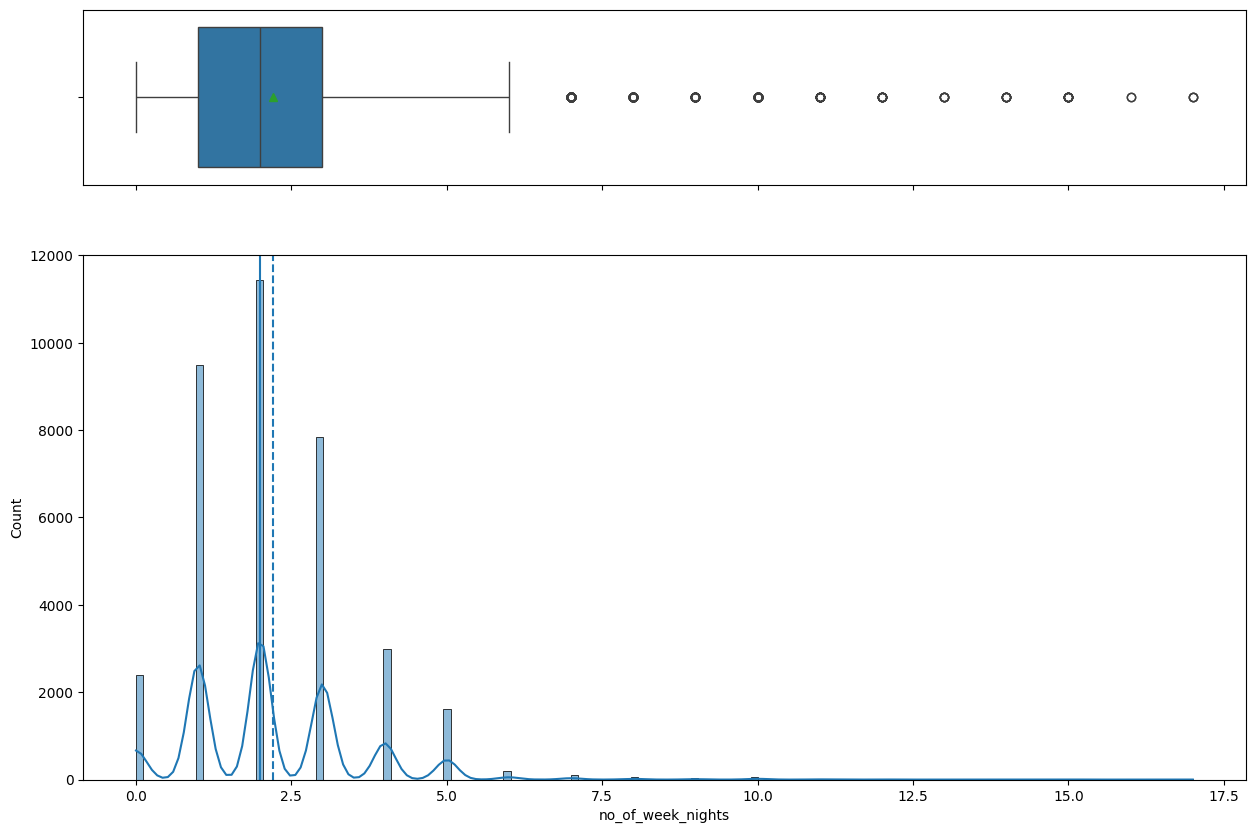

In [29]:
histogram_boxplot(df, "no_of_week_nights", kde=True)

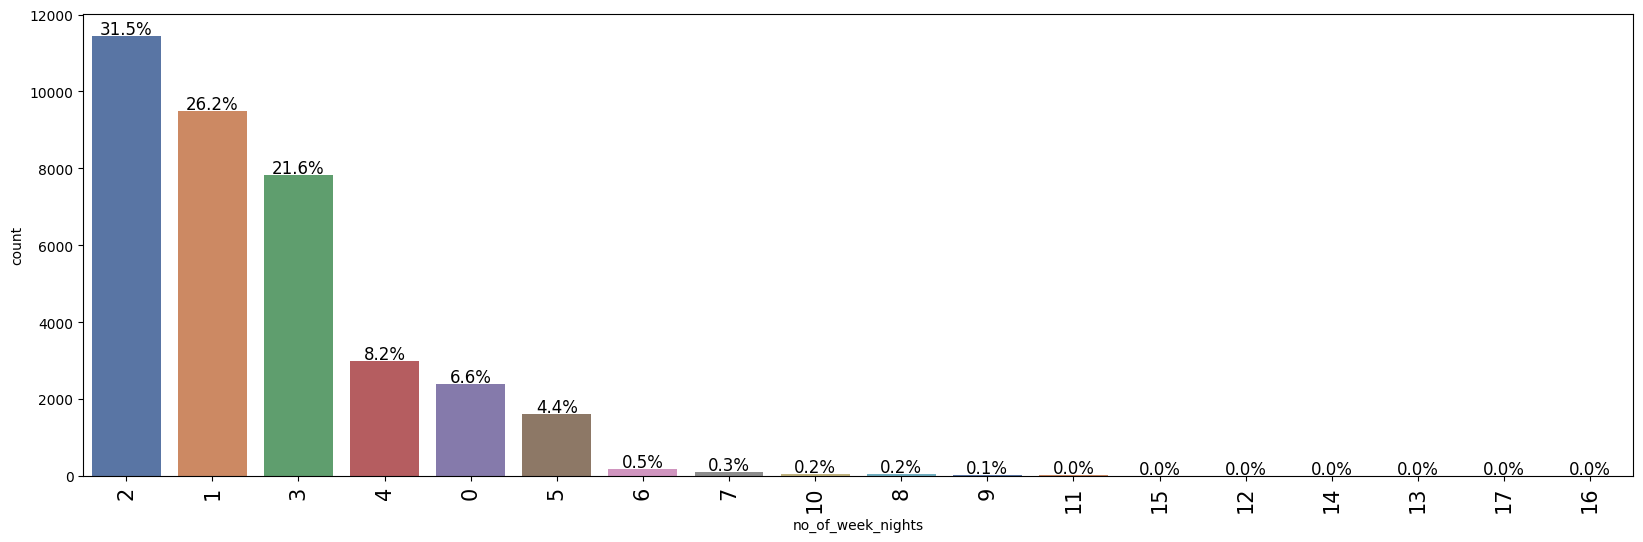

In [30]:
labeled_barplot(df, 'no_of_week_nights', perc=True);

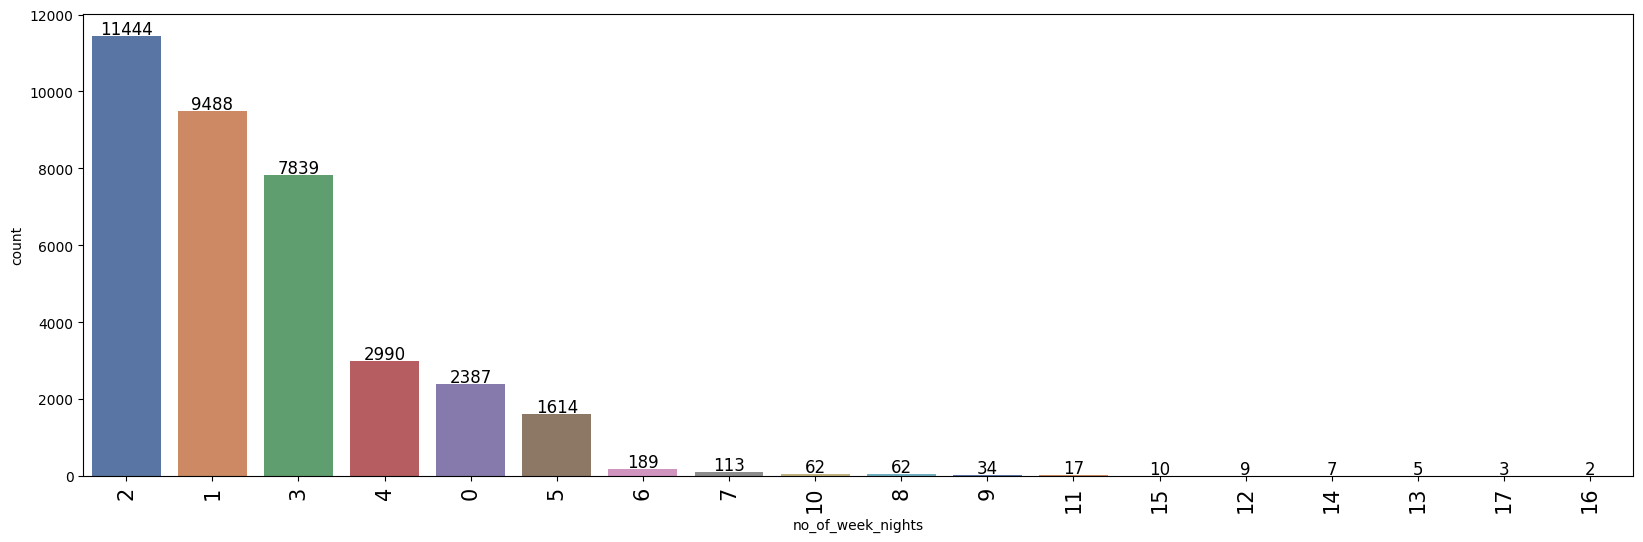

In [31]:
labeled_barplot(df, 'no_of_week_nights');

##### Observations:
* The `no_of_week_nights` variable has a right-skewed distribution with outliers.

* Some outliers include data points with more than 7 `no_of_week_nights`.

*  The *`mean`* of *`no_of_week_nights`* is `2.204300`, indicating that, on average, there were `around 2 no_of_week_nights` per booking.

* `31.5%` of the bookings include *`2 no_of_week_nights`*, followed by `26.2%` with *`1 no_of_week_nights`*, `21.6%` with *`3 no_of_week_nights`*, and so on.

#### Distribution of **`lead_time`** *(Numerical Column)*

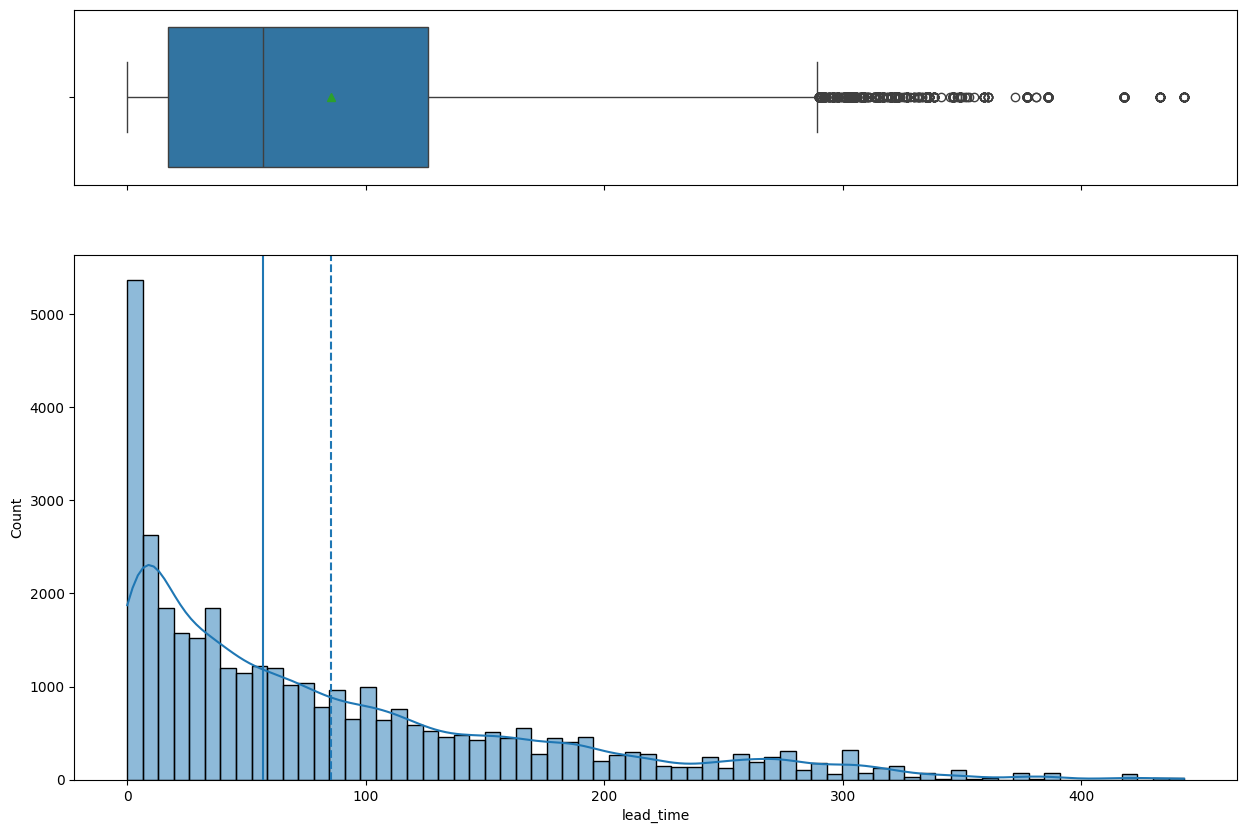

In [32]:
histogram_boxplot(df, "lead_time", kde=True)

##### Observations:

* The `lead_time` variable has a *`right-skewed`* distribution *`with outliers`*.

* The *`average`* `lead_time` is `85 days`.

#### Distribution of **`arrival_year`** *(Numerical Column)*

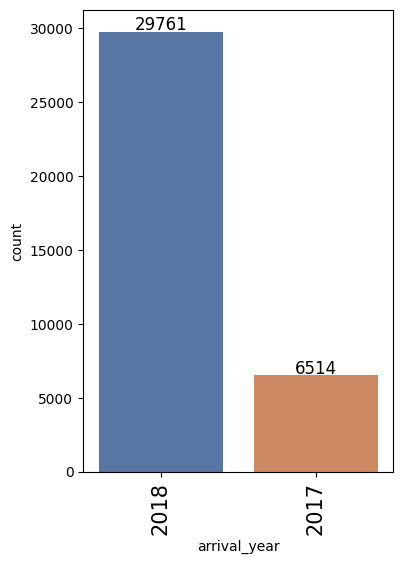

In [33]:
labeled_barplot(df, 'arrival_year');

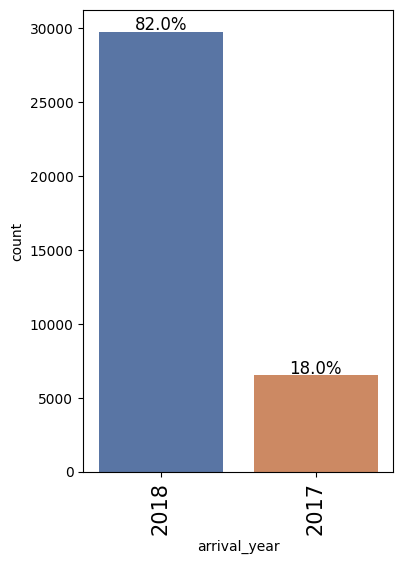

In [34]:
labeled_barplot(df, 'arrival_year', perc=True);

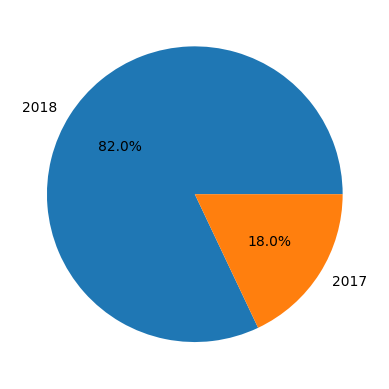

In [35]:
plt.pie(df['arrival_year'].value_counts(), labels=[2018, 2017], autopct='%1.1f%%');

##### Observations:

* The given dataset contains booking data for `only two years`: *`2017 and 2018`*.

* `Around 82%` of the bookings were made in *`2018`*, while `approximately 18%` were made in *`2017`*.

#### Distribution of **`arrival_month`** *(Numerical Column)*

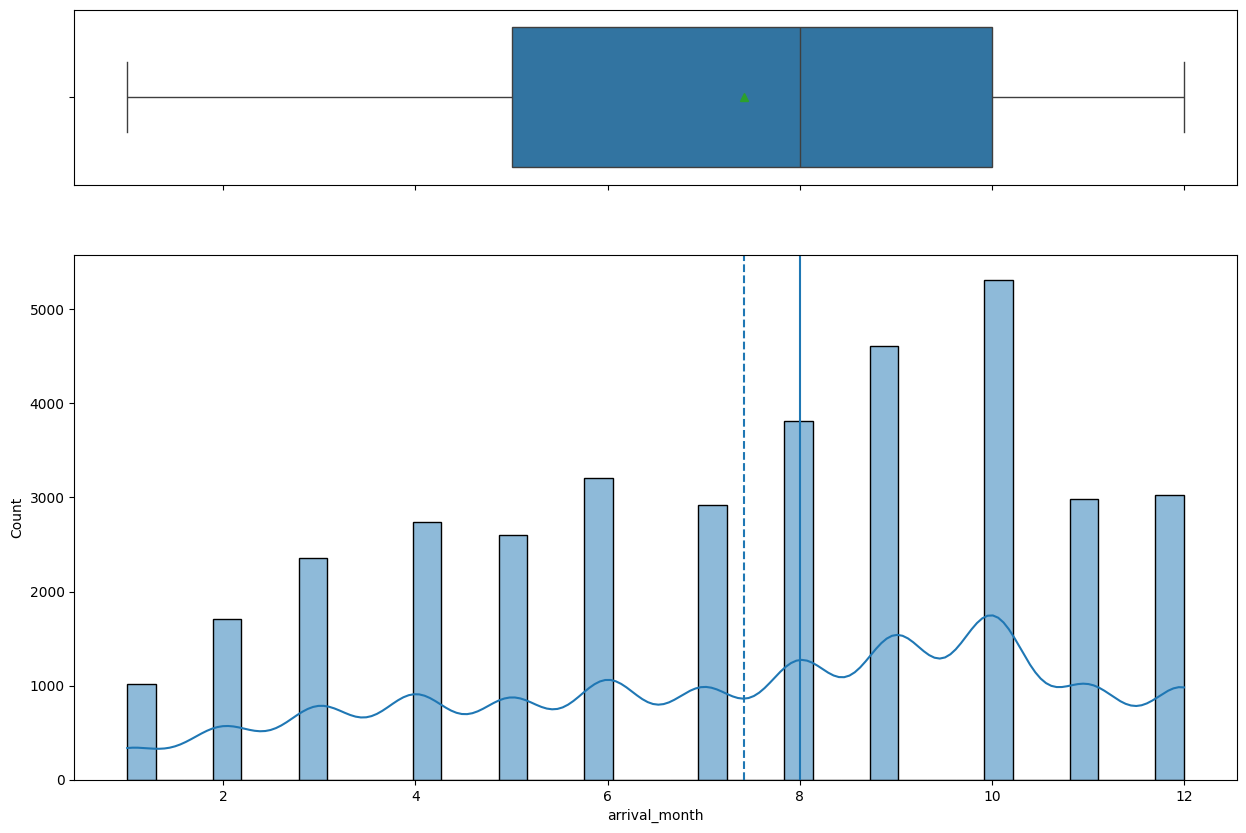

In [36]:
histogram_boxplot(df, "arrival_month", kde=True)

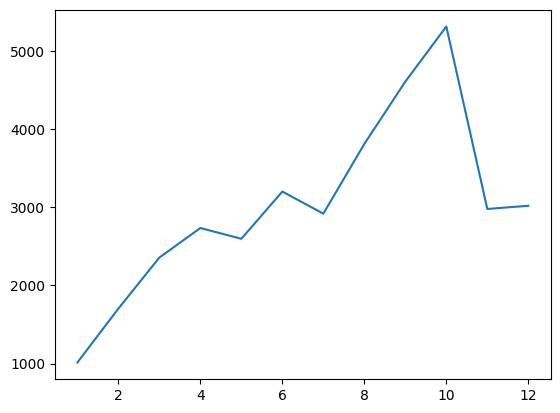

In [37]:
# create line graph
plt.plot(df['arrival_month'].value_counts().sort_index().index, df['arrival_month'].value_counts().sort_index().values);

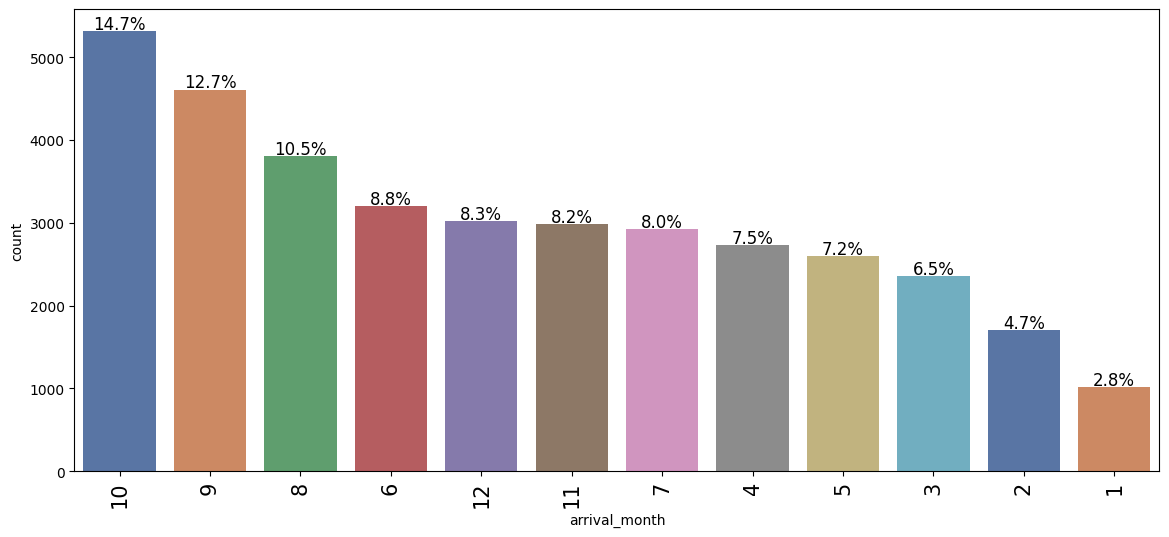

In [38]:
labeled_barplot(df, 'arrival_month', perc=True);

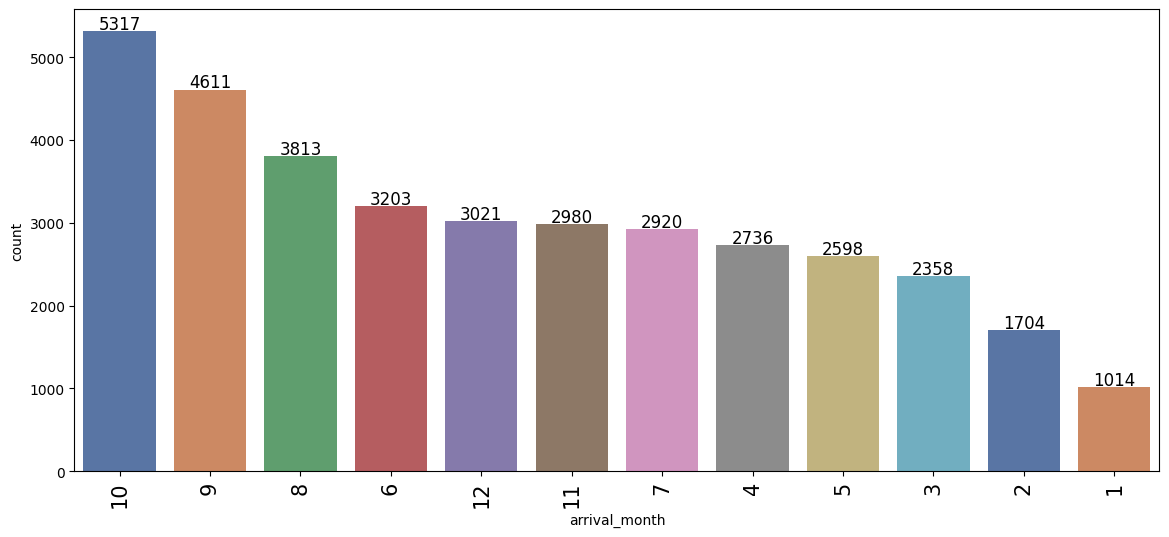

In [39]:
labeled_barplot(df, 'arrival_month');

##### Observations:

* `The highest number of bookings` occurred in *`October`*, with *`5317 bookings`* (*`approximately 14.7%`* of the total bookings).

* The number of bookings `increased` from `August` (*`2920 bookings, around 8% of the total`*) to `October` (*`5317 bookings, approximately 14.7% of the total`*).

* After October, the number of bookings gradually `decreased`, with *`2980 bookings (around 8.2%)`* in `November` and *`3021 bookings (about 8.3%)`* in `December`.

#### Distribution of **`arrival_date`** *(Numerical Column)*

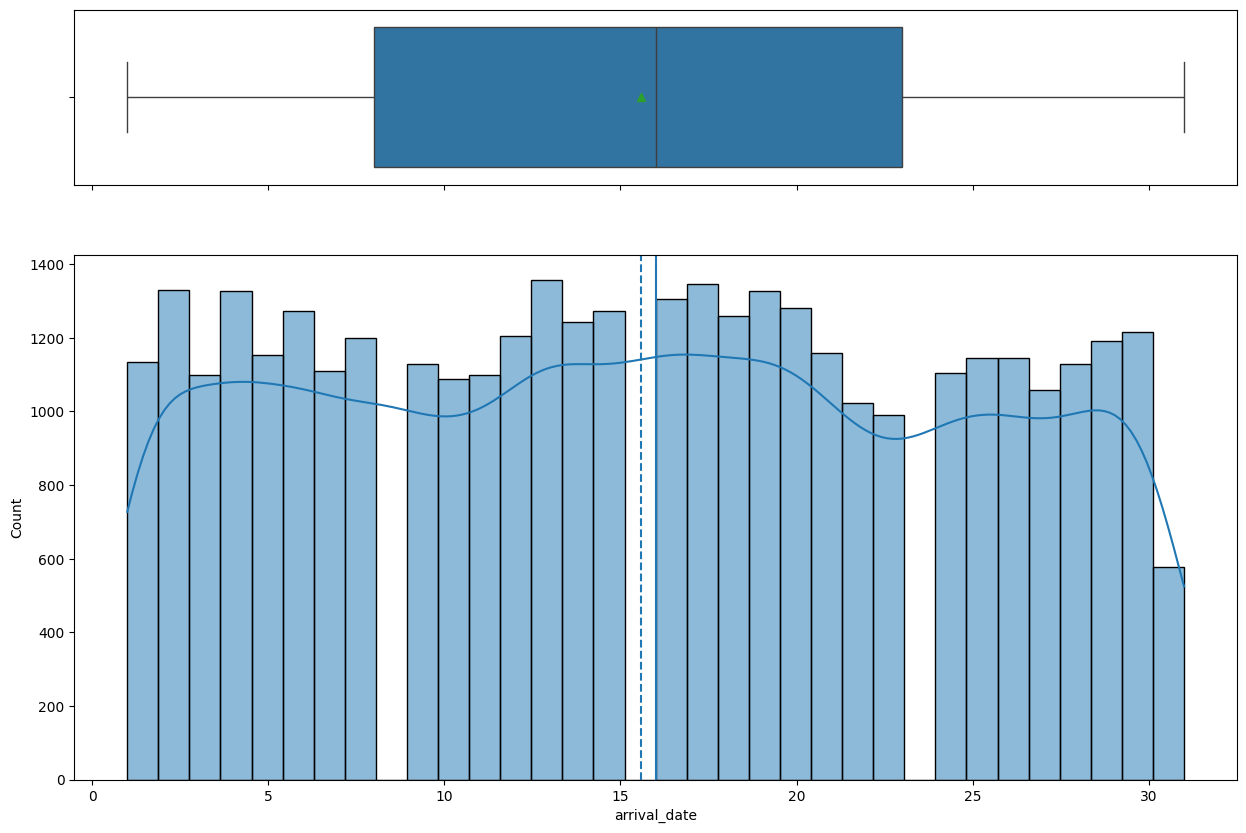

In [40]:
histogram_boxplot(df, "arrival_date", kde=True)

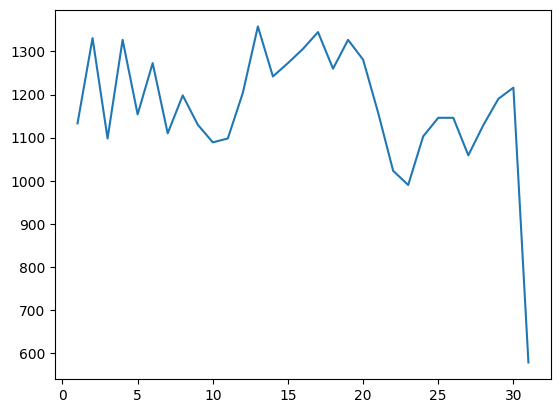

In [41]:
plt.plot(df['arrival_date'].value_counts().sort_index().index, df['arrival_date'].value_counts().sort_index().values);

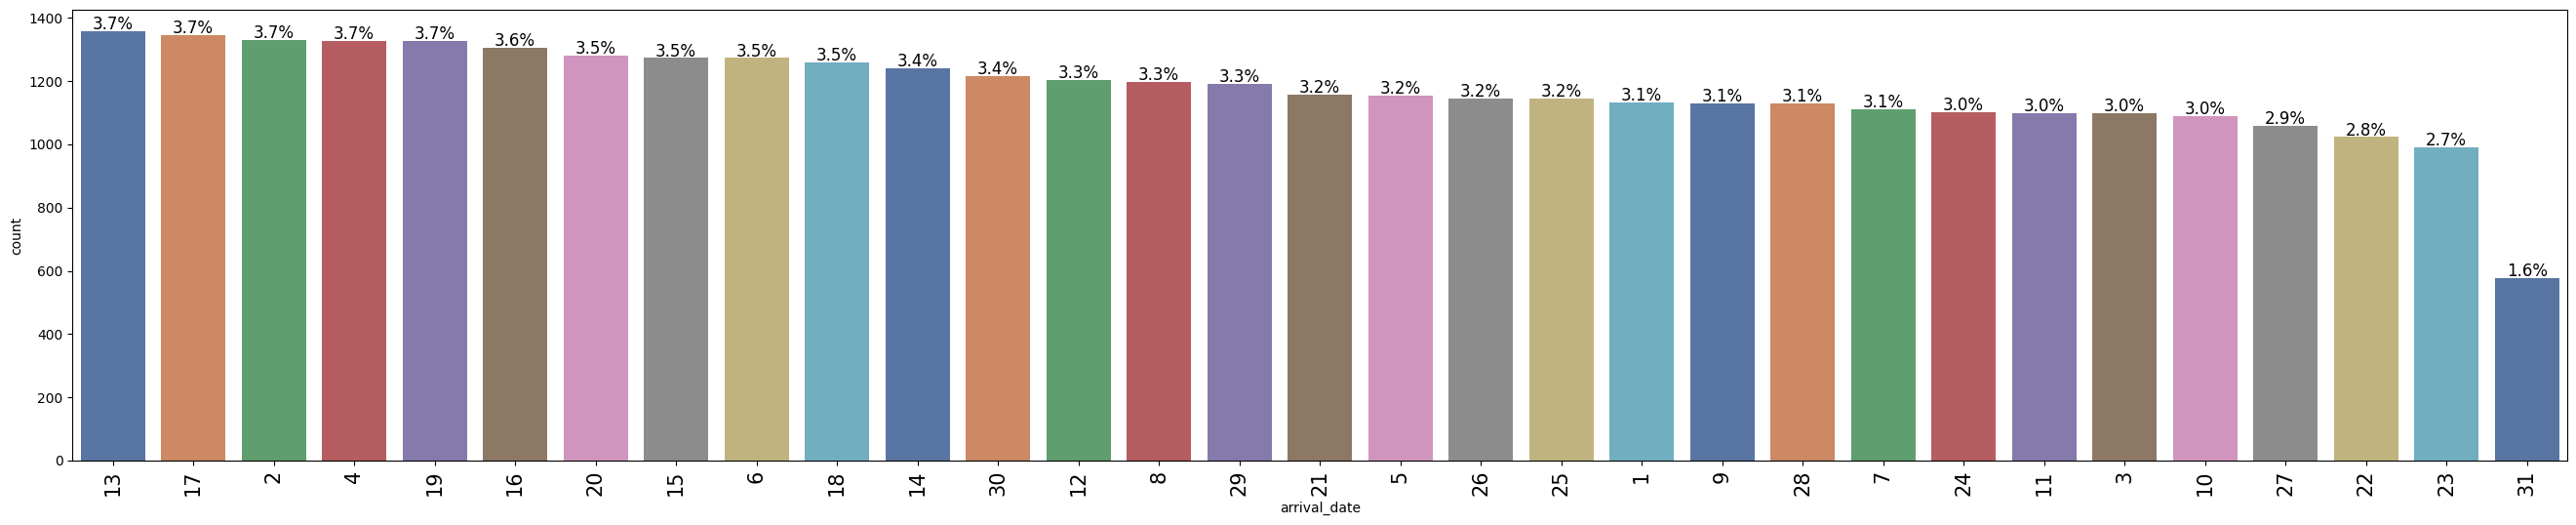

In [42]:
labeled_barplot(df, 'arrival_date', perc=True);

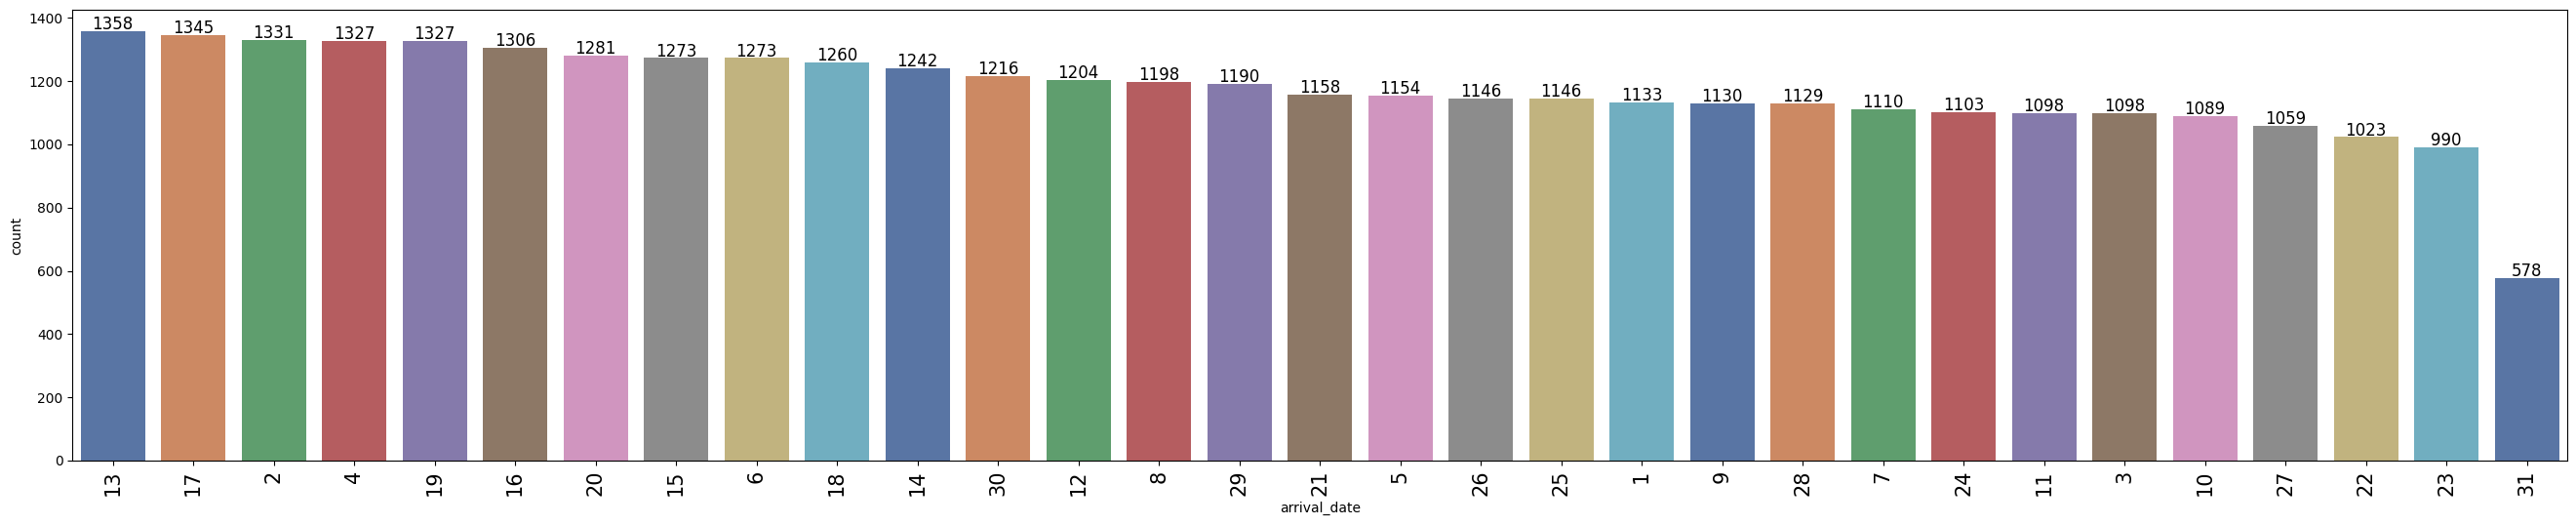

In [43]:
labeled_barplot(df, 'arrival_date');

##### Observations:

* The distribution of the `arrival_date` variable look like evenly distribution.

* `The highest` number of `arrivals` occurred on the `13th` (*1358 bookings, approximately 3.7% of the total*), followed by the `17th` (*1345 bookings, around 3.7%*), the `2nd` (*1331 bookings, around 3.7%*), the `4th` (*1327 bookings, around 3.7%*), and the `19th` (*1327 bookings, around 3.7%*), and so on.

#### Distribution of **`no_of_previous_cancellations`** *(Numerical Column)*

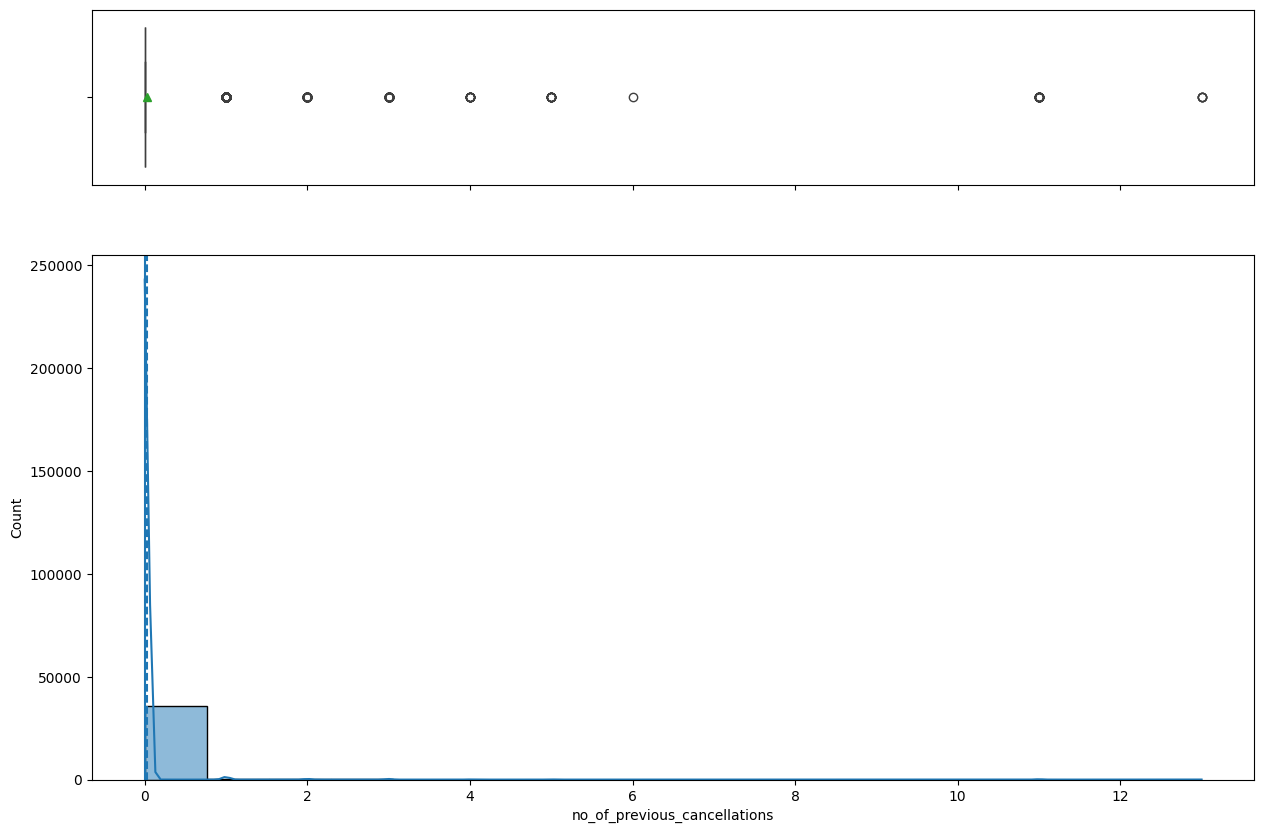

In [44]:
histogram_boxplot(df, "no_of_previous_cancellations", kde=True)

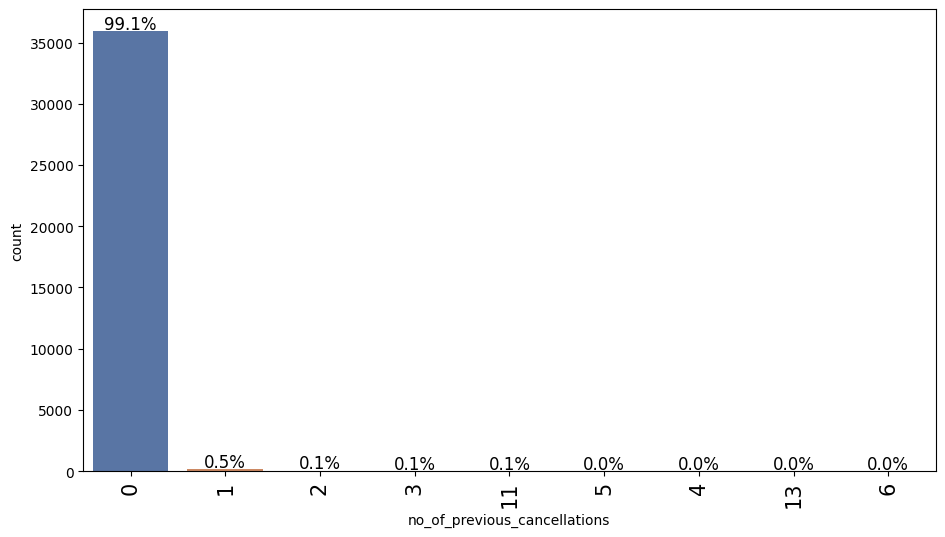

In [45]:
labeled_barplot(df, 'no_of_previous_cancellations', perc=True);

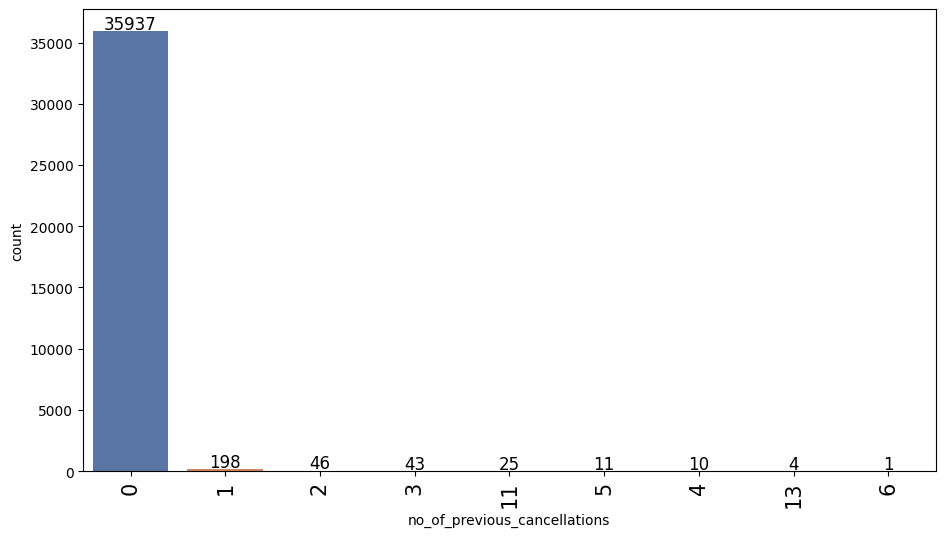

In [46]:
labeled_barplot(df, 'no_of_previous_cancellations');

##### Observations:

* Most customers `did not cancel` any previous bookings (*`35937 bookings, approximately 99.1%`* of the total bookings).

* Around `0.5%` (*198 bookings*) *`canceled one previous booking`*, followed by about `0.1%` (*46 bookings*) who *`canceled two previous bookings`*.

#### Distribution of **`no_of_previous_bookings_not_canceled`** *(Numerical Column)*

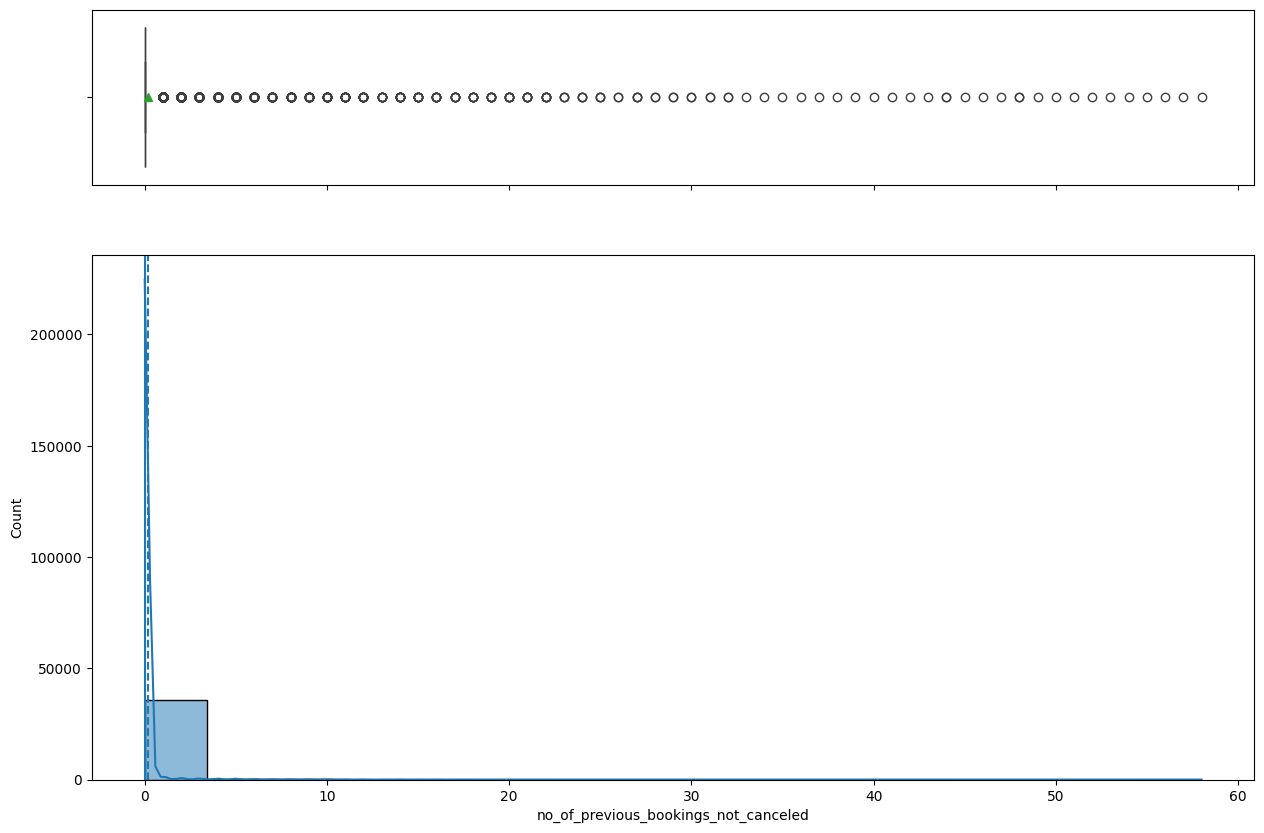

In [47]:
histogram_boxplot(df, "no_of_previous_bookings_not_canceled", kde=True)

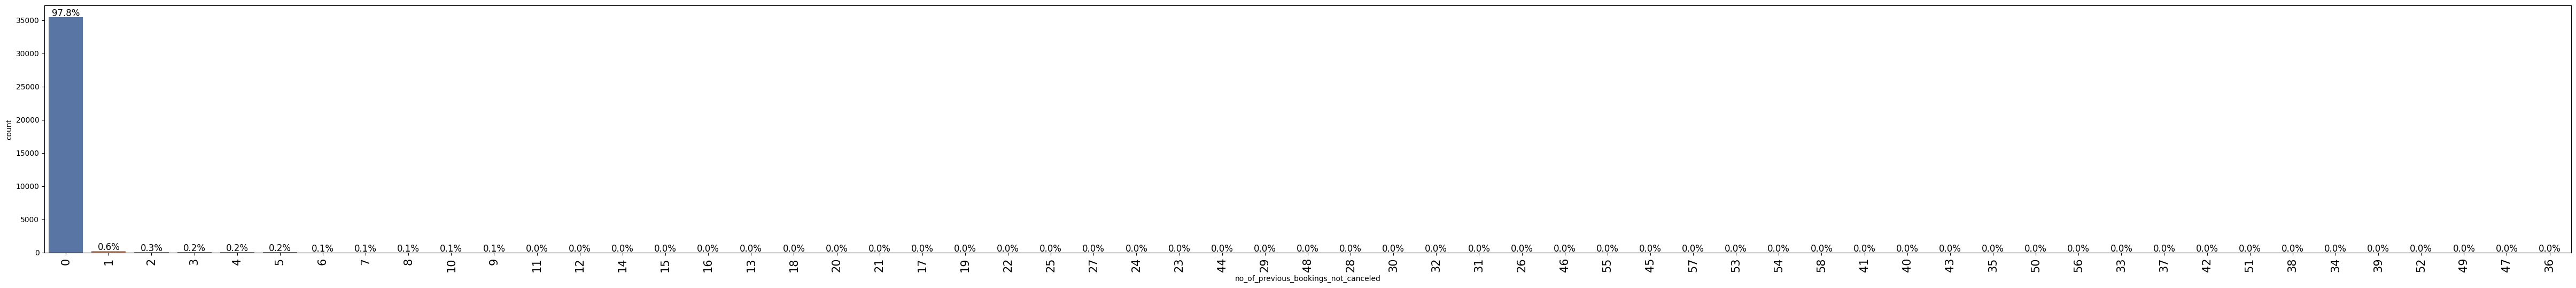

In [48]:
labeled_barplot(df, 'no_of_previous_bookings_not_canceled', perc=True);

In [49]:
value_counts = df['no_of_previous_bookings_not_canceled'].value_counts()

value_percentages = df['no_of_previous_bookings_not_canceled'].value_counts(normalize=True)*100

result_df = pd.DataFrame({'Count': value_counts, 'Percentage': value_percentages})

result_df = result_df.reset_index()

result_df = result_df.rename(columns={'index': 'no_of_previous_bookings_not_canceled'})

result_df

,no_of_previous_bookings_not_canceled,Count,Percentage
0,0,35463,97.761544
1,1,228,0.628532
2,2,112,0.308753
3,3,80,0.220538
4,4,65,0.179187
5,5,60,0.165403
6,6,36,0.099242
7,7,24,0.066161
8,8,23,0.063405
9,10,19,0.052378


##### Observations:

* Data shows that the majority of the bookings had `no previous bookings to be canceled` (*`35463 bookings, around 97.76% of the total bookings`*).

#### Distribution of **`avg_price_per_room`** *(Numerical Column)*

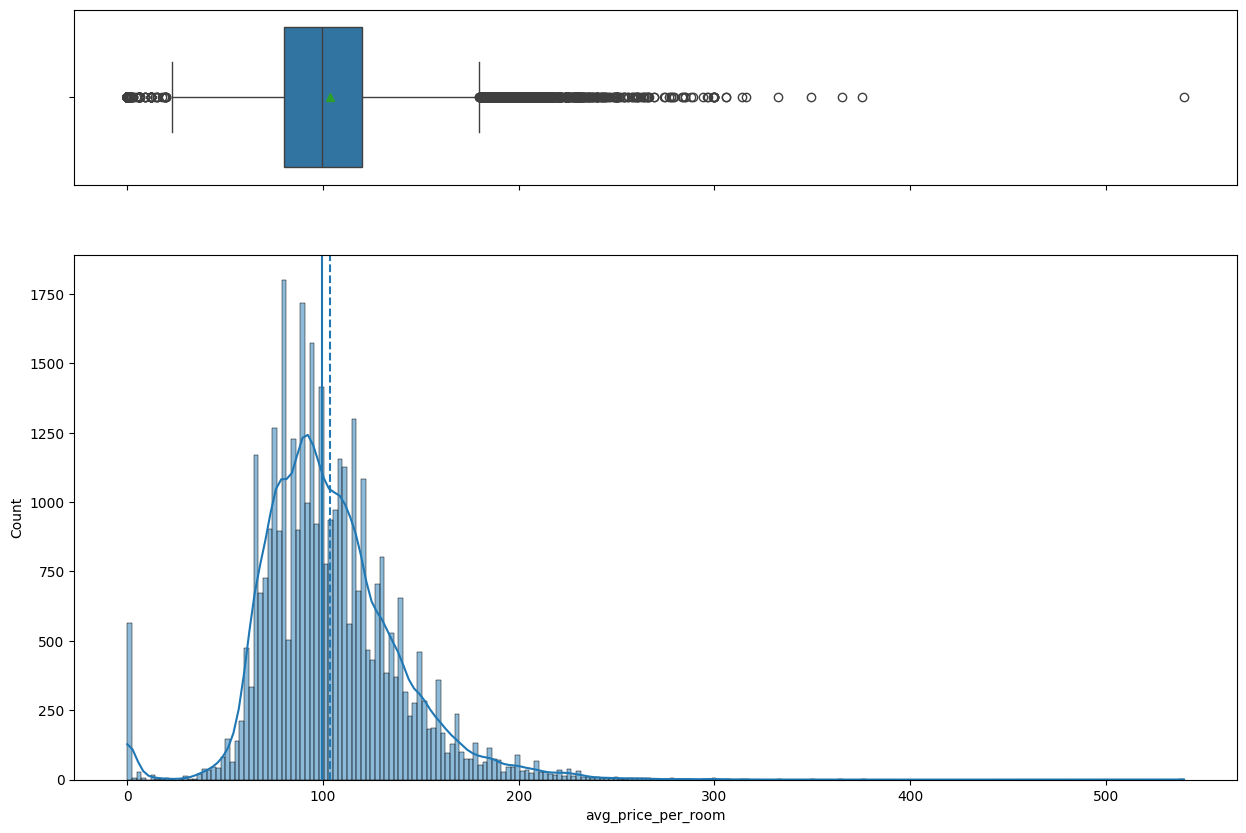

In [50]:
histogram_boxplot(df, "avg_price_per_room", kde=True)

##### Observations:

* The `avg_price_per_room` variable has a right-skewed distribution with outliers.

* The `minimum`, `average`, and `maximum` `avg_price_per_room` are *`0 Euro`*, *`around 103 Euros`* and *`540 Euros`* respectively.

#### Distribution of **`required_car_parking_space`** *(Categorical Column)*

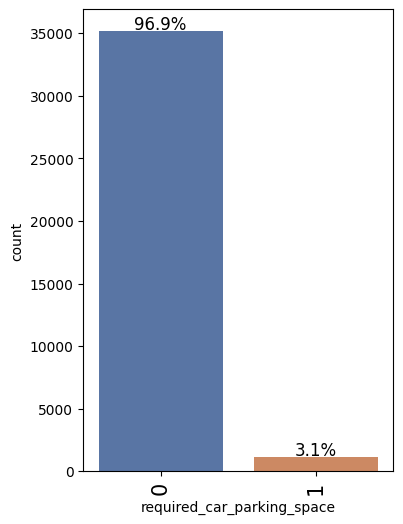

In [51]:
labeled_barplot(df, 'required_car_parking_space', perc=True);

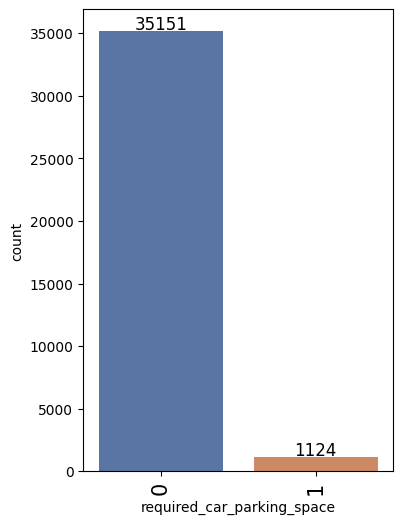

In [52]:
labeled_barplot(df, 'required_car_parking_space');

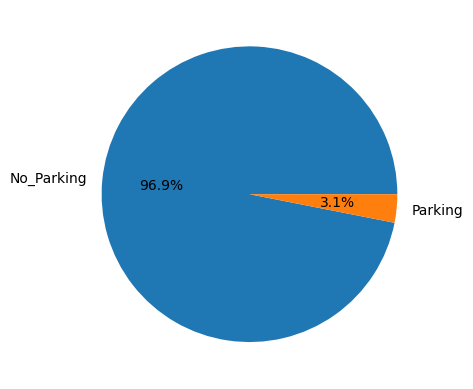

In [53]:
plt.pie(df['required_car_parking_space'].value_counts(), labels=['No_Parking', 'Parking'], autopct='%1.1f%%');

##### Observations:

* `1124 bookings` (`approximately 3.1%` of the total bookings) *`required parking`*, while `35151 bookings` (`around 96.9%` of the total bookings) *`did not require parking`*.

#### Distribution of **`repeated_guest`** *(Categorical Column)*

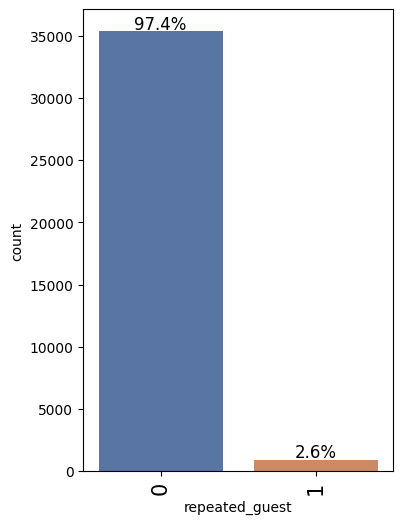

In [54]:
labeled_barplot(df, 'repeated_guest', perc=True);

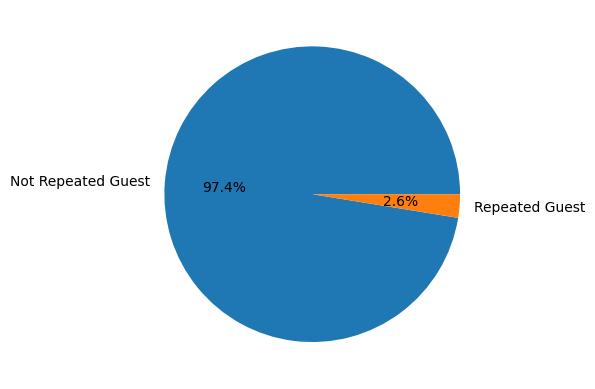

In [55]:
plt.pie(df['repeated_guest'].value_counts(), labels=['Not Repeated Guest', 'Repeated Guest'], autopct='%1.1f%%');

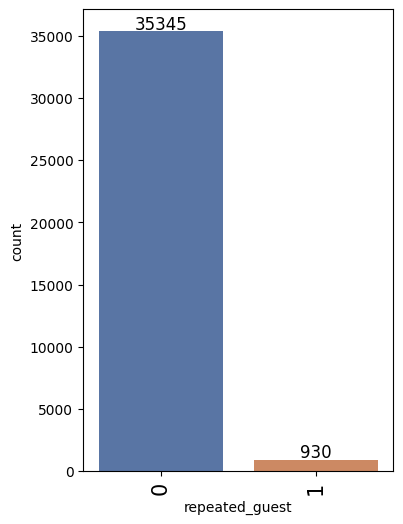

In [56]:
labeled_barplot(df, 'repeated_guest');

##### Observations:

* `35345 bookings` (`approximately 97.4%` of the total bookings) were *`not booked twice`*, while `930 bookings` (`around 2.6%` of the total bookings) were *`booked twice`*.

#### Distribution of **`no_of_special_requests`** *(Categorical Column)*

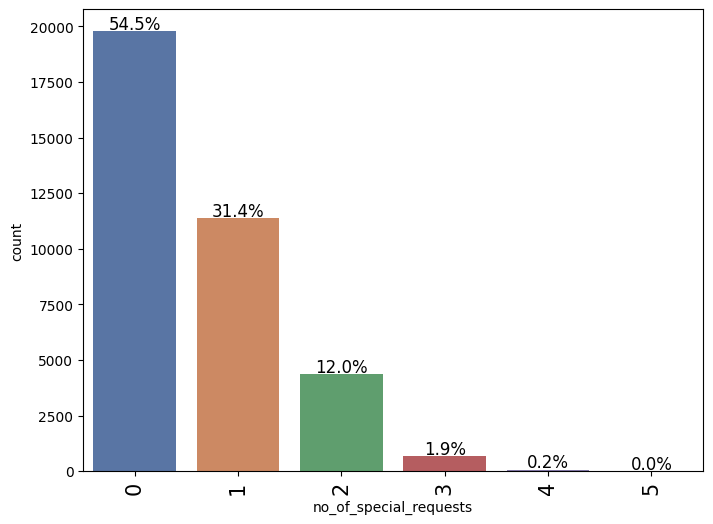

In [57]:
labeled_barplot(df, 'no_of_special_requests', perc=True);

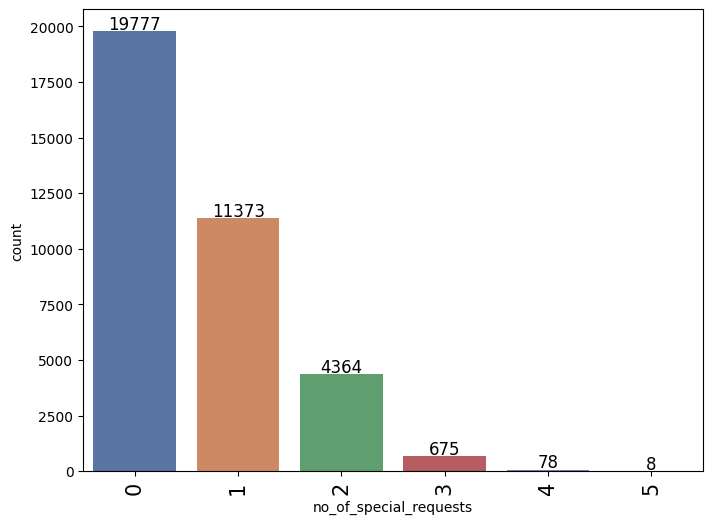

In [58]:
labeled_barplot(df, 'no_of_special_requests');

##### Observations:

* The majority of customers, approximately `54.5%` of the total (`19777 bookings`), had `zero` *`no_of_special_requests`*

#### Distribution of **`type_of_meal_plan`** *(Categorical Column)*

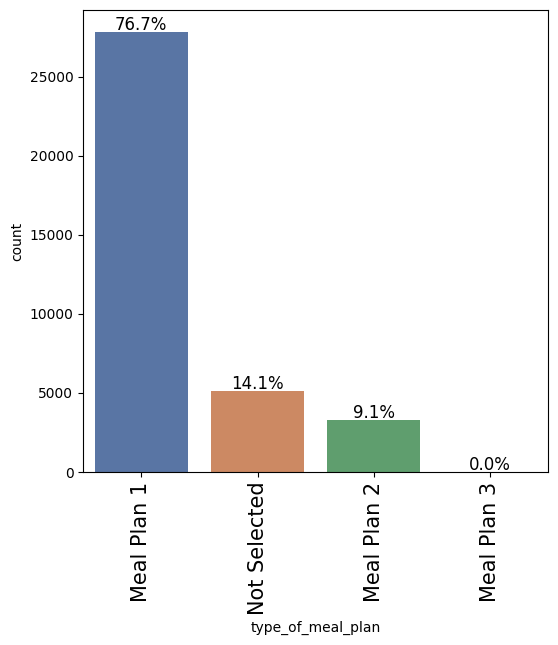

In [59]:
labeled_barplot(df, 'type_of_meal_plan', perc=True);

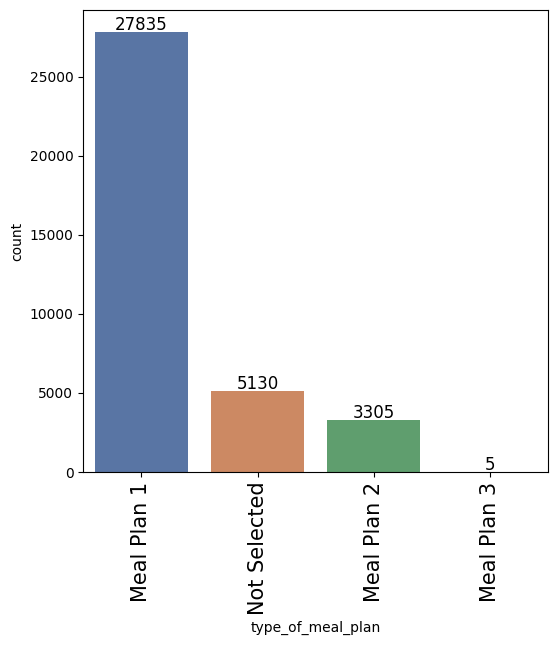

In [60]:
labeled_barplot(df, 'type_of_meal_plan');

##### Observations:

* `Most customers` chose `Meal Plan 1` (which includes just breakfast), with *`27835 bookings`*, accounting for *`approximately 76.7%`* of the total bookings.

* About `5130 bookings, approximately 14.1%` of the total, `did not select` any meal plan.

#### Distribution of **`room_type_reserved`** *(Categorical Column)*

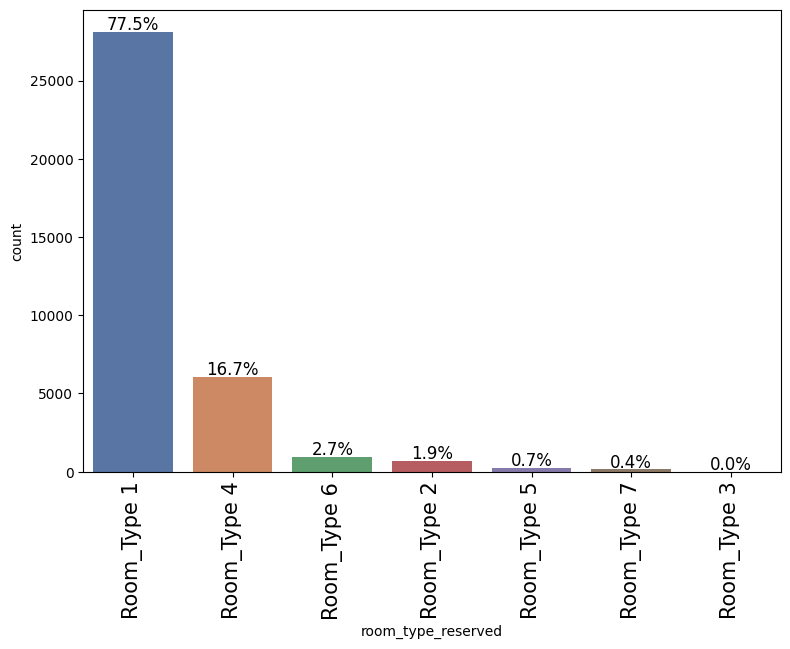

In [61]:
labeled_barplot(df, 'room_type_reserved', perc=True);

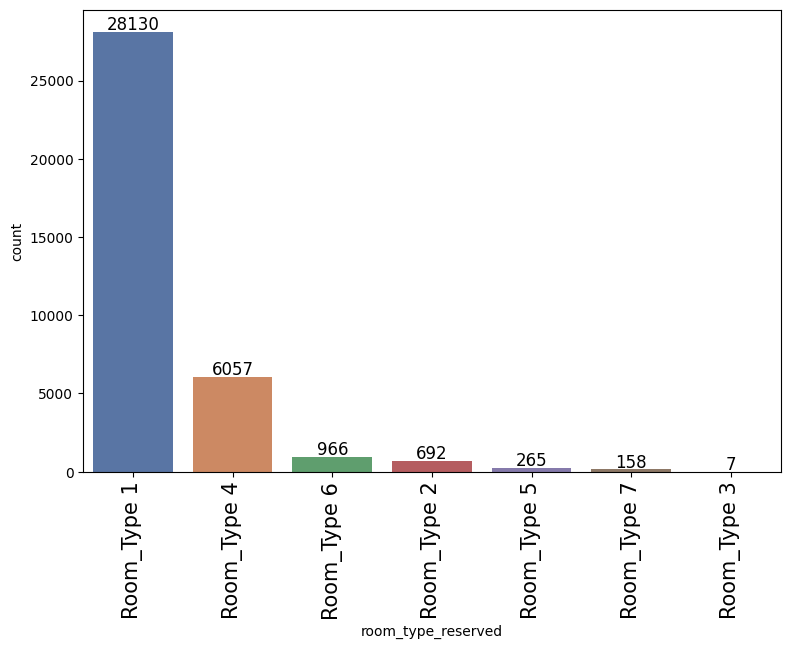

In [62]:
labeled_barplot(df, 'room_type_reserved');

##### Observations:

* `28130 bookings, approximately 77.5%` of the total, preferred *`Room_Type 1`*, followed by `6057 bookings, around 16.7%` of the total, which preferred *`Room_Type 4`*, and so on.

#### Distribution of **`market_segment_type`** *(Categorical Column)*

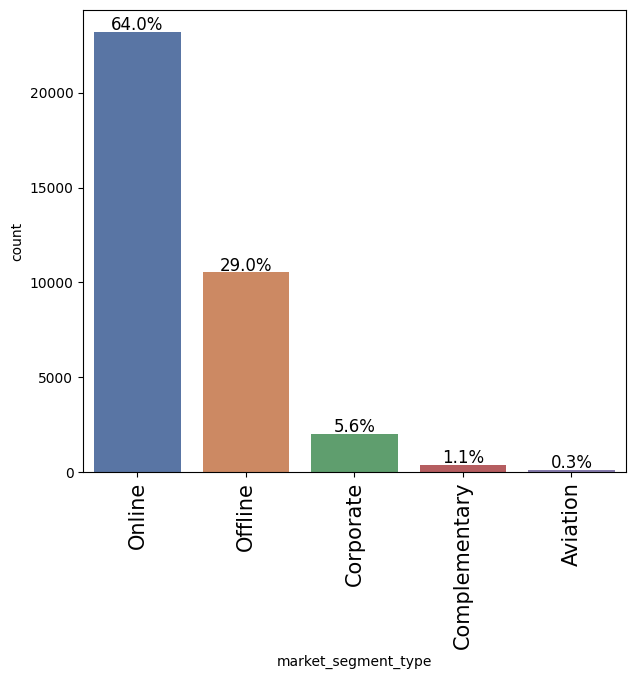

In [63]:
labeled_barplot(df, 'market_segment_type', perc=True);

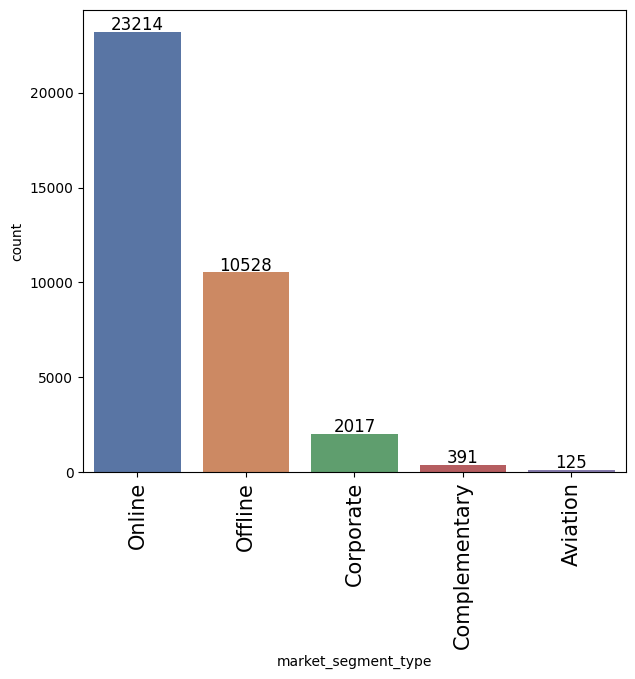

In [64]:
labeled_barplot(df, 'market_segment_type');

##### Observations:

* The majority of the guest come from *`Online`* `market_segment_type`, followed by *`Offline`*, *`Corporate`* and so on.

* The *`online`* `market_segment_type` has *`23214 bookings, around 64%`* of the total.

* The *`Offline`* `market_segment_type` has *`10528 bookings, approximately 29%`* of the total.

* The *`rest (Aviation, Corporate, Complementary)`* `market_segment_type` has around *`7%`* of the total.

#### Distribution of **`booking_status`** *(Categorical Column)*

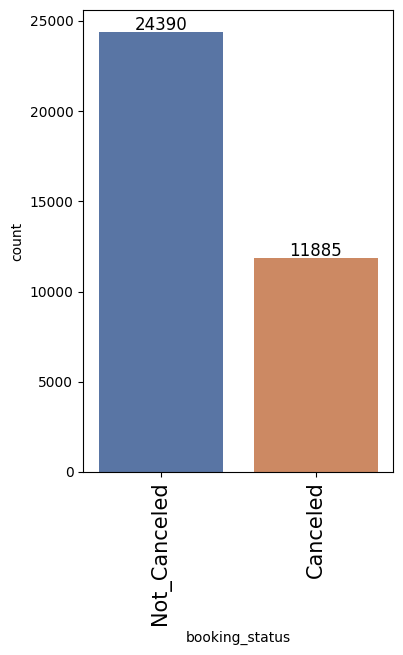

In [65]:
labeled_barplot(df, 'booking_status');

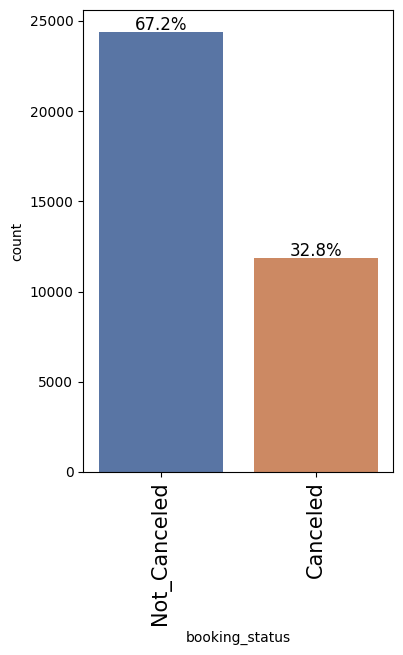

In [66]:
labeled_barplot(df, 'booking_status', perc=True);

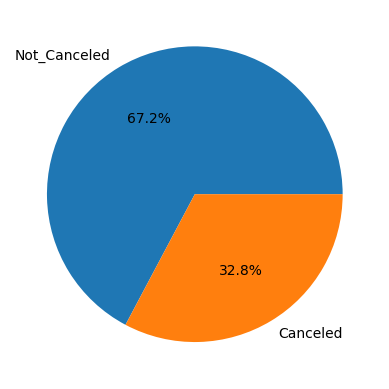

In [67]:
plt.pie(df['booking_status'].value_counts(), labels=['Not_Canceled', 'Canceled'], autopct='%1.1f%%');

##### Observations:

* `24390 bookings` (`approximately 67.2%` of the total bookings) were *`Not_Canceled`*, while `11885 bookings` (`around 32.8%` of the total bookings) were *`Canceled`*.

### Bivariate analysis

#### Correlation check

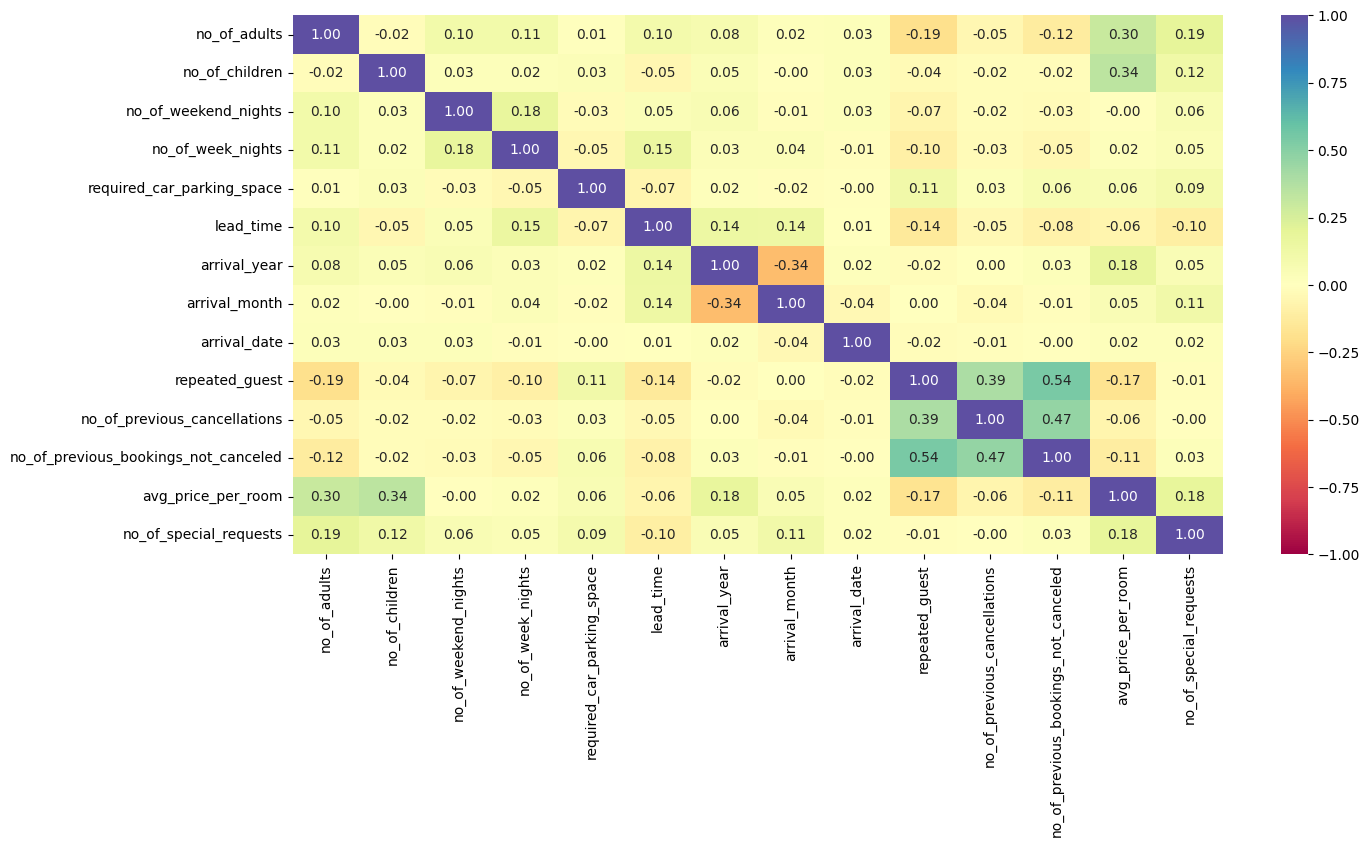

In [68]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

##### Observations:

* There is a positive correlation (approximately 30%) between no_of_adults and avg_price_per_room, suggesting that as the number of adults increases, the average price per room also increases.

* Similarly, there is a positive correlation (around 34%) between no_of_children and avg_price_per_room, indicating that as the number of children increases, the average price per room also increases.

* A negative correlation (approximately 19%) exists between repeated_guest and no_of_adults, suggesting that repeated guests tend to have fewer adults in their bookings.

* There is a small positive correlation (about 18%) between no_of_weekend_nights and no_of_week_nights.

* A small positive correlation (approximately 15%) is observed between no_of_week_nights and lead_time.

* There is a small positive correlation (around 11%) between required_car_parking_space and repeated_guest.

* A negative correlation (approximately 34%) is observed between arrival_month and arrival_year.

* A small positive correlation (about 18%) exists between arrival_year and avg_price_per_room.

* There is a positive correlation (approximately 39%) between repeated_guest and no_of_previous_cancellation.

* A stronger positive correlation (approximately 54%) is seen between repeated_guest and no_of_previous_bookings_not_canceled.

* A negative correlation (approximately 17%) is observed between repeated_guest and avg_price_per_room.

* There is a positive correlation (about 47%) between no_of_previous_bookings_not_canceled and no_of_previous_cancellation.

* A small positive correlation (approximately 18%) exists between avg_price_per_room and no_of_special_requests.

#### Distribution of **`booking_status`** vs **`no_of_adults`** *(Categorical column & Numerical Column)*

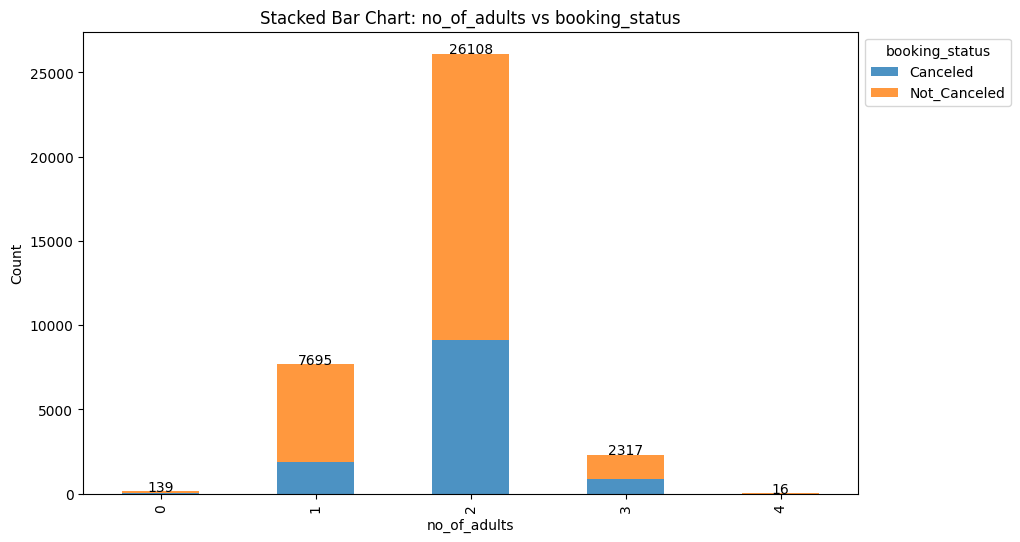

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
no_of_adults,,,,,
0,44,95,139,31.65,68.35
1,1856,5839,7695,24.12,75.88
2,9119,16989,26108,34.93,65.07
3,863,1454,2317,37.25,62.75
4,3,13,16,18.75,81.25


In [69]:
stacked_barplot(df, 'no_of_adults', 'booking_status')

##### Observations:

* The highest number of both canceled and not canceled bookings occurred with 2 no_of_adults, with 9,119 canceled and 16,989 not canceled, making a total of 26,108 bookings.

* The least number of canceled bookings occurred with 4 no_of_adults, with a total of just 16 bookings.

#### Distribution of **`booking_status`** vs **`no_of_children`** *(Categorical column & Numerical Column)*

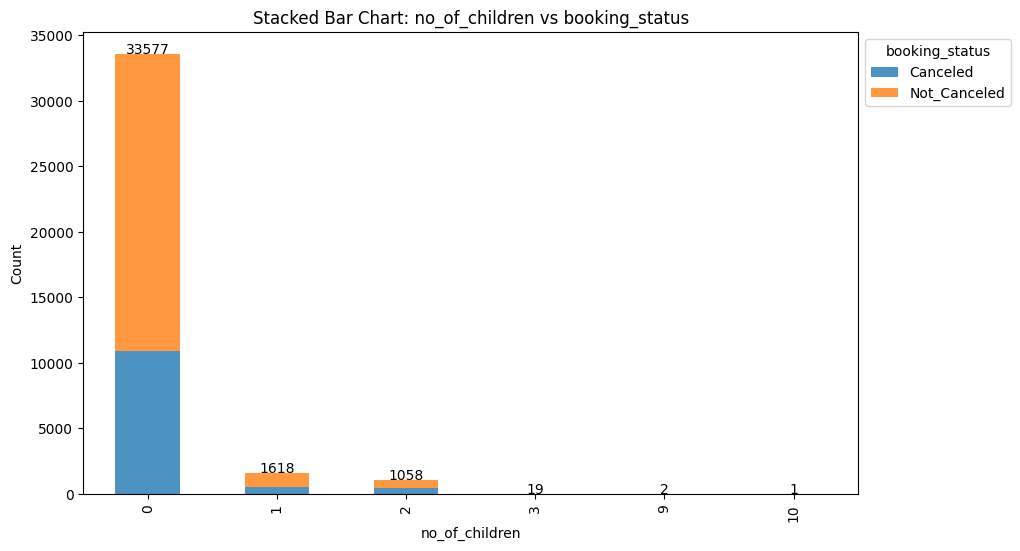

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
no_of_children,,,,,
0,10882,22695,33577,32.41,67.59
1,540,1078,1618,33.37,66.63
2,457,601,1058,43.19,56.81
3,5,14,19,26.32,73.68
9,1,1,2,50.00,50.00
10,0,1,1,0.00,100.00


In [70]:
stacked_barplot(df, 'no_of_children', 'booking_status')

##### Observations:

* The highest number of both canceled and not canceled bookings occurred with Zero no_of_children, with 10882 canceled and 22695 not canceled, making a total of 33577 bookings.

* The least number of not canceled bookings occurred with 10 no_of_children, with only 1 booking, which may be an outlier.

#### Distribution of **`booking_status`** vs **`no_of_weekend_nights`** *(Categorical column & Numerical Column)*

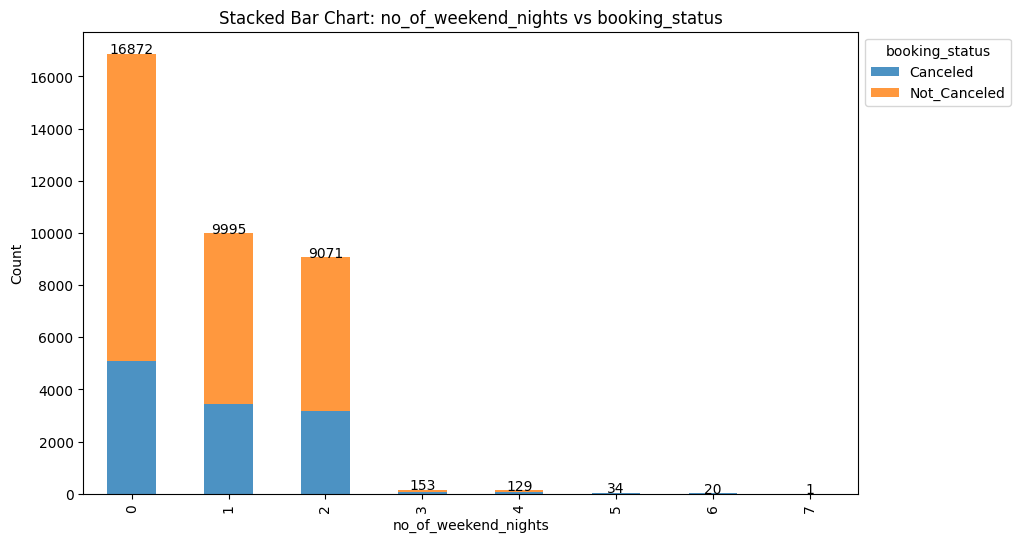

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
no_of_weekend_nights,,,,,
0,5093,11779,16872,30.19,69.81
1,3432,6563,9995,34.34,65.66
2,3157,5914,9071,34.80,65.20
3,74,79,153,48.37,51.63
4,83,46,129,64.34,35.66
5,29,5,34,85.29,14.71
6,16,4,20,80.00,20.00
7,1,0,1,100.00,0.00


In [71]:
stacked_barplot(df, 'no_of_weekend_nights', 'booking_status')

##### Observations:

* The majority of the bookings had zero no_of_weekend_nights, with 16,872 bookings out of a total of 36,275.

* The least number of bookings were with 7 no_of_weekend_nights, and unfortunately, it was canceled.

#### Distribution of **`booking_status`** vs **`no_of_week_nights`** *(Categorical column & Numerical Column)*

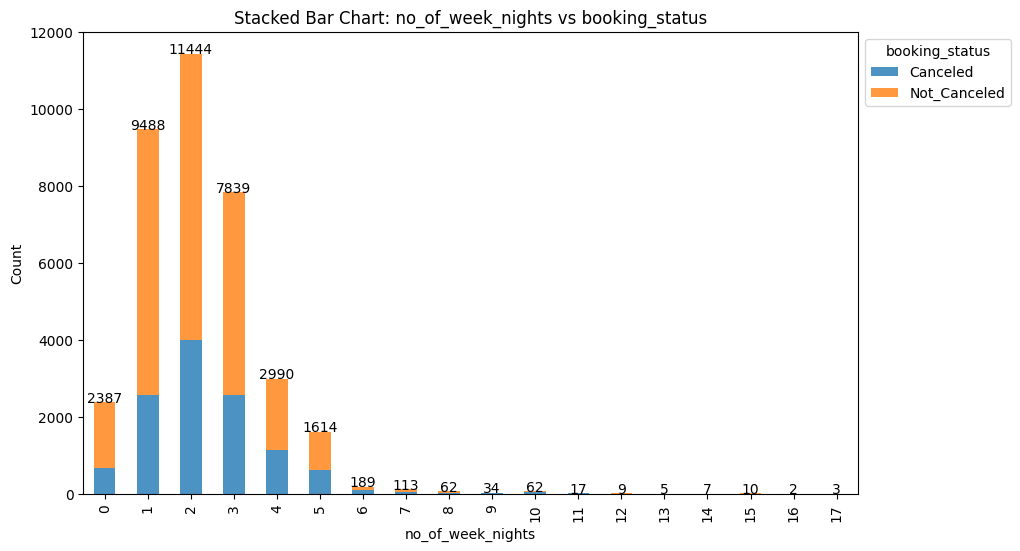

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
no_of_week_nights,,,,,
0,679,1708,2387,28.45,71.55
1,2572,6916,9488,27.11,72.89
2,3997,7447,11444,34.93,65.07
3,2574,5265,7839,32.84,67.16
4,1143,1847,2990,38.23,61.77
5,632,982,1614,39.16,60.84
6,88,101,189,46.56,53.44
7,52,61,113,46.02,53.98
8,32,30,62,51.61,48.39


In [72]:
stacked_barplot(df, 'no_of_week_nights', 'booking_status')

In [73]:
df[df['no_of_week_nights'] > 8]['booking_status'].value_counts()

,count
booking_status,
Canceled,116
Not_Canceled,33


##### Observations:

* The majority of the bookings had 2 no_of_week_nights, with 11444 bookings out of a total of 36275.

* The least number of bookings occurred with 17 no_of_week_nights, with 2 bookings canceled out of a total of 3.

* All bookings were canceled when the no_of_week_nights was 13 (5 out of 5 bookings) and 16 (2 out of 2 bookings).

* Most bookings were canceled when the no_of_week_nights exceeded 8, with 116 bookings canceled out of a total of 149 (approximately 78%).

#### Distribution of **`booking_status`** vs **`required_car_parking_space`** *(Categorical column & Categorical Column)*

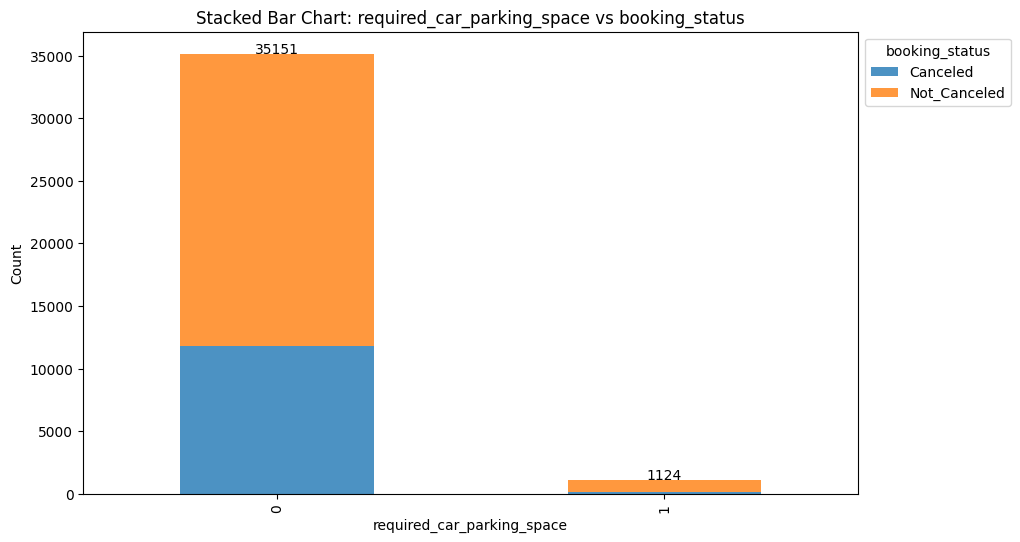

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
required_car_parking_space,,,,,
0,11771,23380,35151,33.49,66.51
1,114,1010,1124,10.14,89.86


In [74]:
stacked_barplot(df, 'required_car_parking_space', 'booking_status')

##### Observations:

* The maximum number of bookings were canceled when there was no required_car_parking_space, with 11771 cancellations out of 35151 bookings.

* The percentage of not-canceled bookings was higher for customers who required a car_parking_space, approximately 90% (1010 bookings out of 1124).

#### Distribution of **`booking_status`** vs **`lead_time`** *(Categorical column & Numerical Column)*

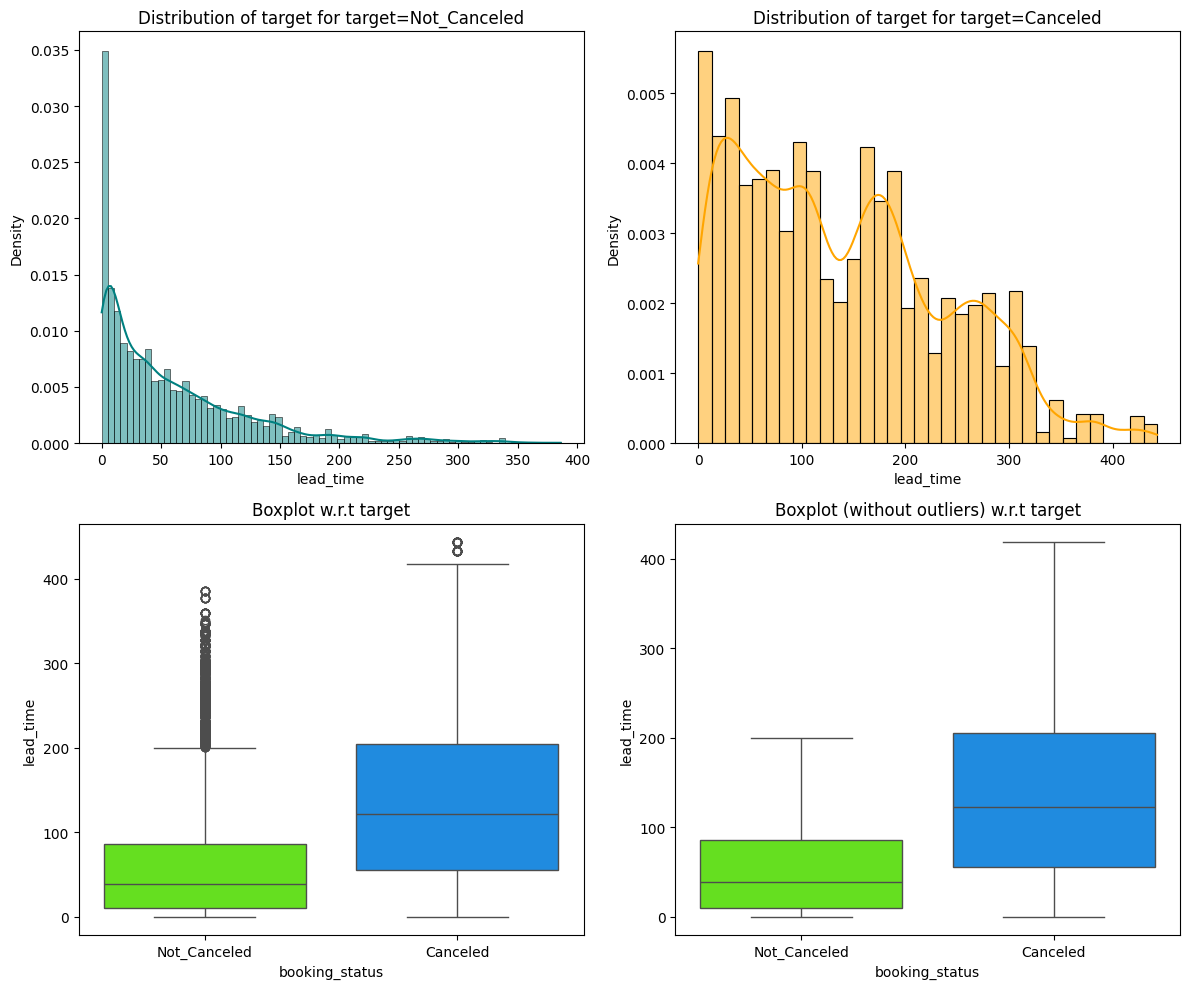

In [75]:
distribution_plot_wrt_target(df, 'lead_time', 'booking_status');

#### Distribution of **`booking_status`** vs **`arrival_year`** *(Categorical column & Numerical Column)*

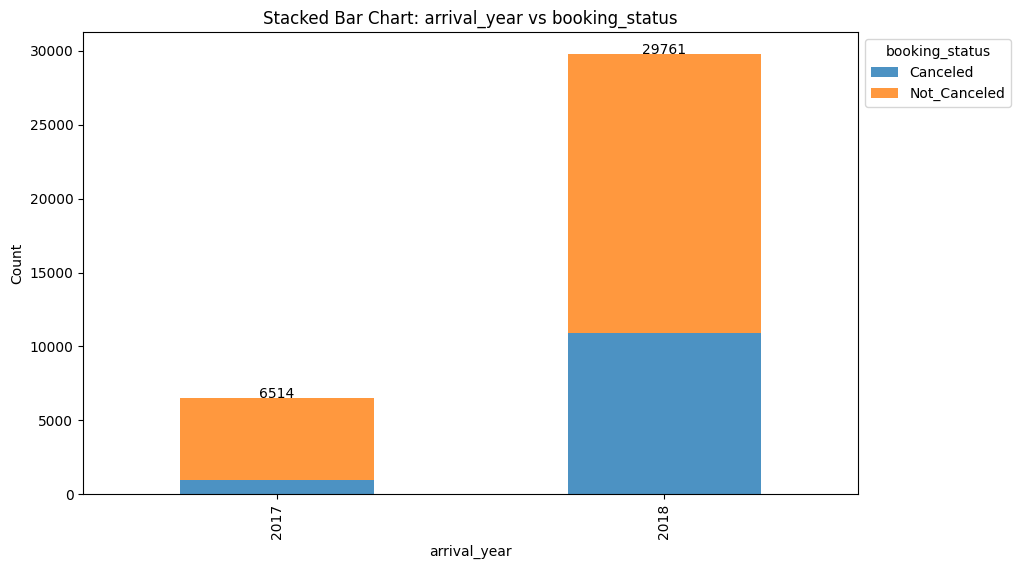

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
arrival_year,,,,,
2017,961,5553,6514,14.75,85.25
2018,10924,18837,29761,36.71,63.29


In [76]:
stacked_barplot(df, 'arrival_year', 'booking_status')

##### Observations:

* The maximum number of canceled and not-canceled bookings occurred in 2018, with 10924 canceled bookings and 18837 not-canceled bookings, representing approximately 36.7% (10,924 out of 29,761 bookings).

* In contrast, the percentage of canceled bookings in 2017 was lower compared to 2018, at approximately 14.7% (961 canceled bookings out of 6514 bookings).

#### Distribution of **`booking_status`** vs **`arrival_month`** *(Categorical column & Numerical Column)*

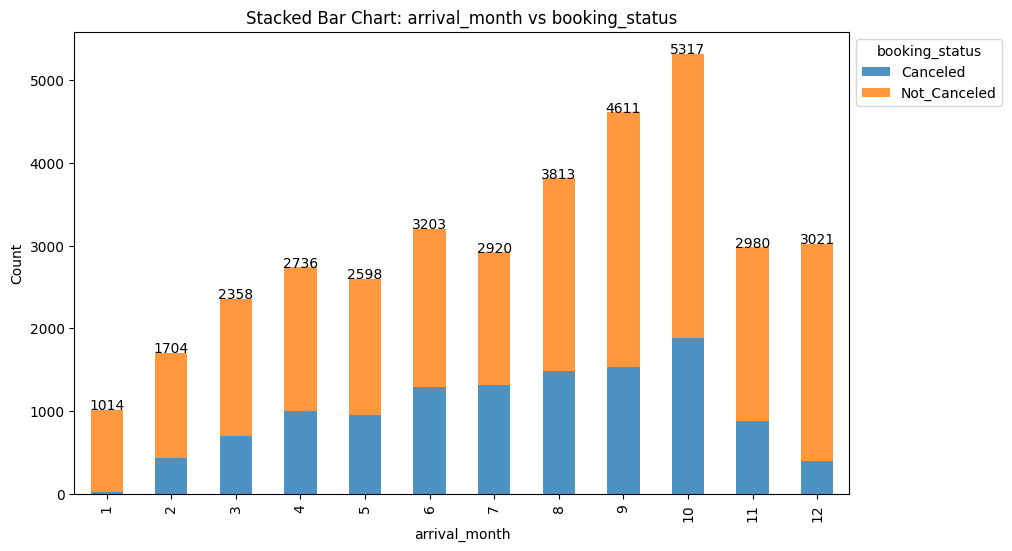

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
arrival_month,,,,,
1,24,990,1014,2.37,97.63
2,430,1274,1704,25.23,74.77
3,700,1658,2358,29.69,70.31
4,995,1741,2736,36.37,63.63
5,948,1650,2598,36.49,63.51
6,1291,1912,3203,40.31,59.69
7,1314,1606,2920,45.00,55.00
8,1488,2325,3813,39.02,60.98
9,1538,3073,4611,33.36,66.64


In [77]:
stacked_barplot(df, 'arrival_month', 'booking_status')

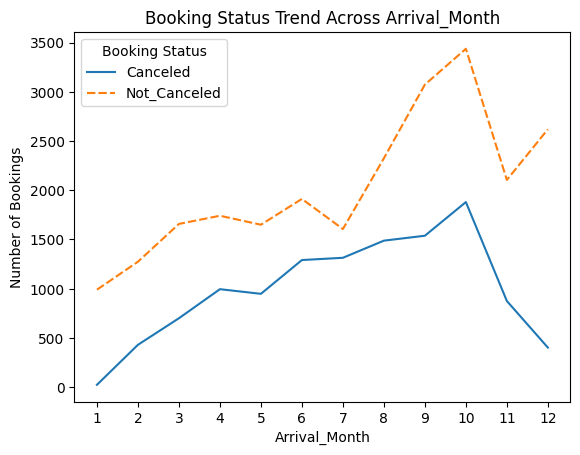

In [78]:
line_plot_with_two_lines(df, 'arrival_month', 'booking_status');

##### Observations:

* The maximum percentage of bookings were canceled in July (month 7), with approximately 45% cancellations (1314 canceled bookings out of 2920 total bookings).

* The second-highest cancellation percentage occurred in June (month 6), with around 40.31% cancellations (1291 canceled bookings out of 3203 total bookings).

* The month with the highest percentage of Not_Canceled bookings was January (month 1), with about 97.64% not-canceled bookings (990 not_cancellations out of 1014 total bookings).

#### Distribution of **`booking_status`** vs **`arrival_date`** *(Categorical column & Numerical Column)*

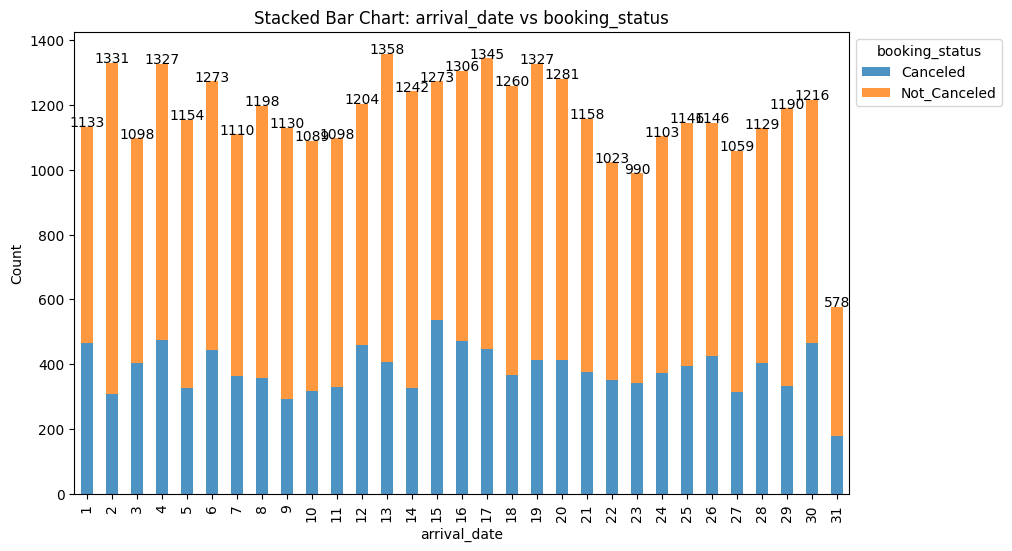

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
arrival_date,,,,,
1,465,668,1133,41.04,58.96
2,308,1023,1331,23.14,76.86
3,403,695,1098,36.70,63.30
4,474,853,1327,35.72,64.28
5,328,826,1154,28.42,71.58
6,444,829,1273,34.88,65.12
7,364,746,1110,32.79,67.21
8,356,842,1198,29.72,70.28
9,294,836,1130,26.02,73.98


In [79]:
stacked_barplot(df, 'arrival_date', 'booking_status')

##### Observations:

* The maximum number of bookings were canceled on the 15th (538 canceled bookings out of 1273 total bookings), followed by the 4th (474 canceled bookings out of 1327 total bookings) and the 16th (473 canceled bookings out of 1306 total bookings), and so on.

#### Distribution of **`booking_status`** vs **`repeated_guest`** *(Categorical column & Categorical Column)*

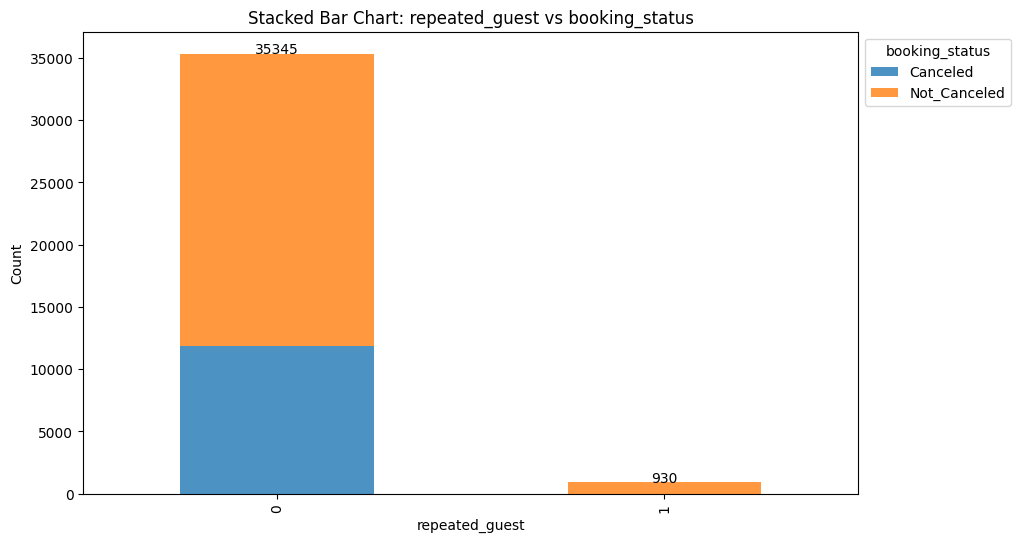

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
repeated_guest,,,,,
0,11869,23476,35345,33.58,66.42
1,16,914,930,1.72,98.28


In [80]:
stacked_barplot(df, 'repeated_guest', 'booking_status')

##### Observations:

* The maximum number of canceled bookings occurred with no repeated_guest, with a canceled percentage of 33.6% (11869 canceled bookings out of 35345 total bookings).

* For repeated_guest, the canceled percentage was much lower, approximately 1.72% (16 canceled bookings out of 930 total bookings).

#### Distribution of **`booking_status`** vs **`no_of_previous_cancellations`** *(Categorical column & Numerical Column)*

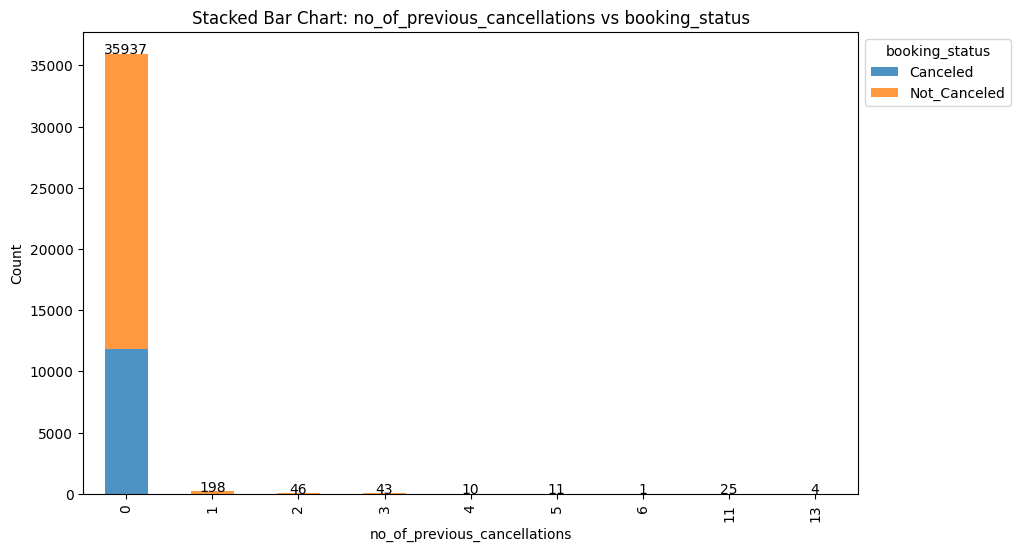

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
no_of_previous_cancellations,,,,,
0,11869,24068,35937,33.03,66.97
1,11,187,198,5.56,94.44
2,0,46,46,0.00,100.00
3,1,42,43,2.33,97.67
4,0,10,10,0.00,100.00
5,0,11,11,0.00,100.00
6,0,1,1,0.00,100.00
11,0,25,25,0.00,100.00
13,4,0,4,100.00,0.00


In [81]:
stacked_barplot(df, 'no_of_previous_cancellations', 'booking_status')

#### Distribution of **`booking_status`** vs **`no_of_previous_bookings_not_canceled`** *(Categorical column & Numerical Column)*

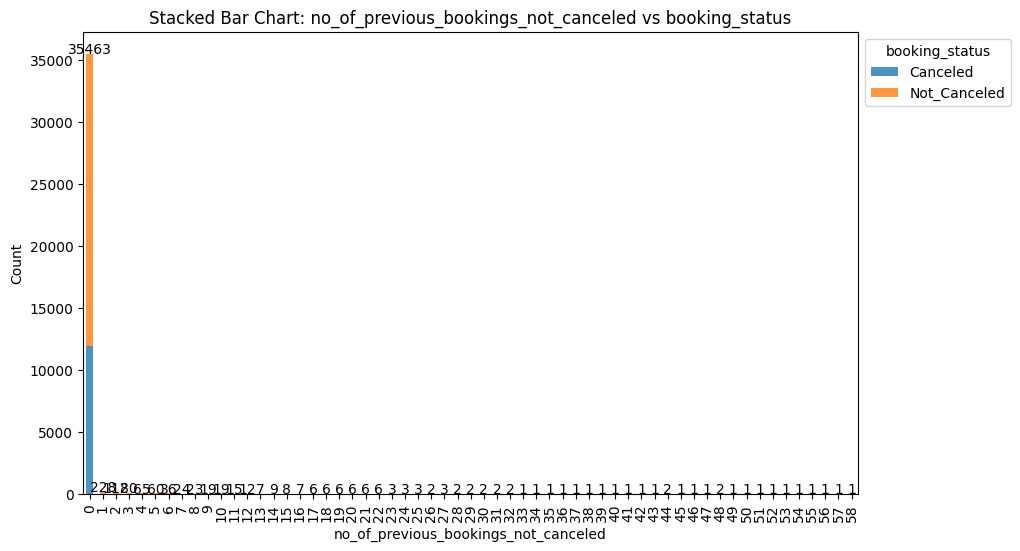

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
no_of_previous_bookings_not_canceled,,,,,
0,11878,23585,35463,33.49,66.51
1,4,224,228,1.75,98.25
2,0,112,112,0.00,100.00
3,0,80,80,0.00,100.00
4,1,64,65,1.54,98.46
5,0,60,60,0.00,100.00
6,1,35,36,2.78,97.22
7,0,24,24,0.00,100.00
8,0,23,23,0.00,100.00


In [82]:
stacked_barplot(df, 'no_of_previous_bookings_not_canceled', 'booking_status')

#### Distribution of **`booking_status`** vs **`avg_price_per_room`** *(Categorical column & Numerical Column)*

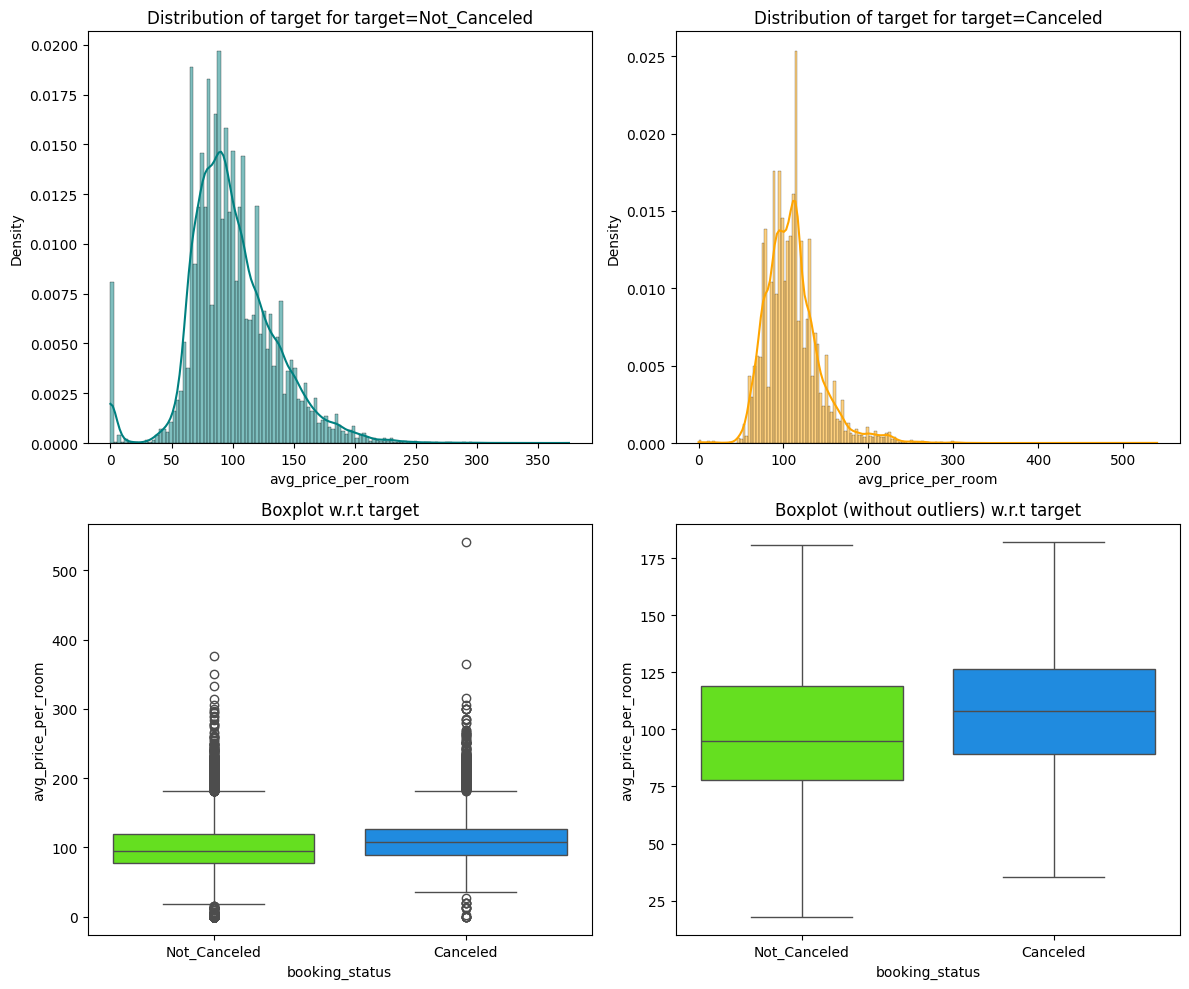

In [83]:
distribution_plot_wrt_target(df, 'avg_price_per_room', 'booking_status');

#### Distribution of **`booking_status`** vs **`no_of_special_requests`** *(Categorical column & Categorical Column)*

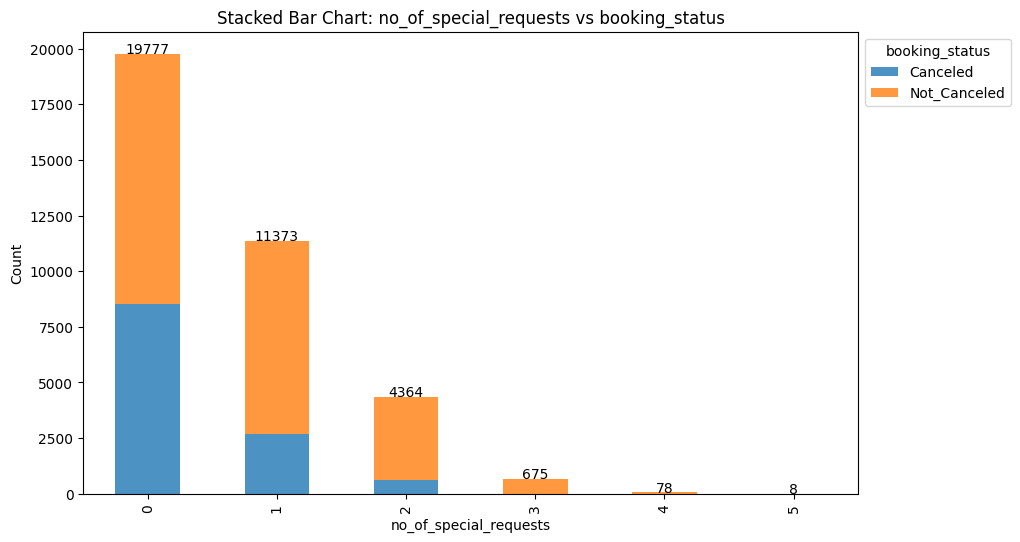

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
no_of_special_requests,,,,,
0,8545,11232,19777,43.21,56.79
1,2703,8670,11373,23.77,76.23
2,637,3727,4364,14.60,85.40
3,0,675,675,0.00,100.00
4,0,78,78,0.00,100.00
5,0,8,8,0.00,100.00


In [84]:
stacked_barplot(df, 'no_of_special_requests', 'booking_status')

##### Observations:

* Based on observations, the booking status was predominantly Not_Canceled if the no_of_special_requests was more than 2.

* The maximum number of canceled bookings occurred when the no_of_special_requests was zero, indicating that customers who did not make any special requests were more likely to cancel their bookings.

* The maximum percentage fo canceled booking was 43.21% (8545 canceled booking out of 19777 total bookings).

#### Distribution of **`booking_status`** vs **`type_of_meal_plan`** *(Categorical column & Categorical Column)*

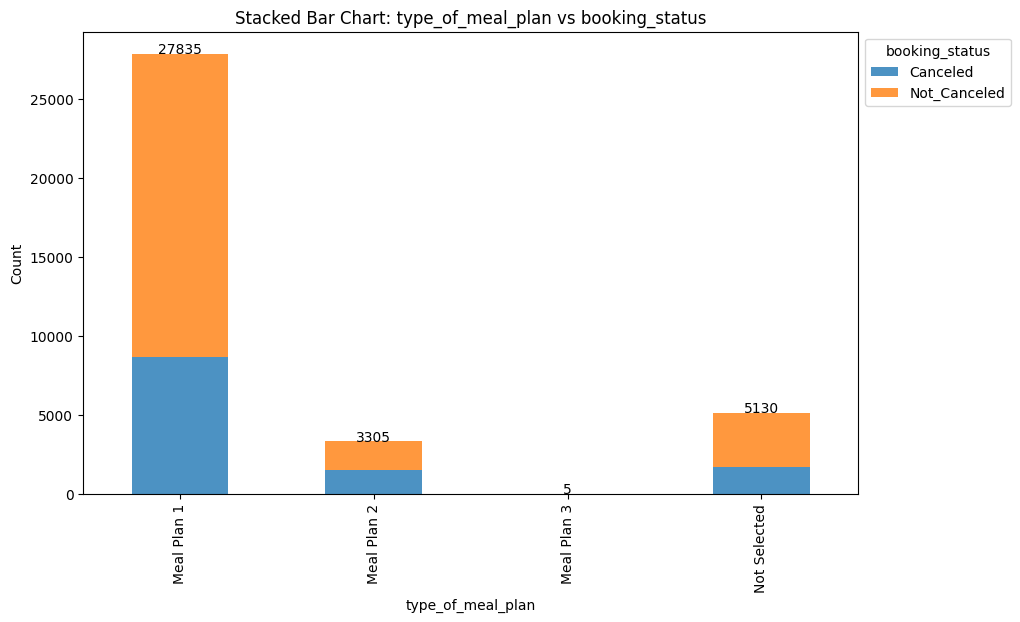

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
type_of_meal_plan,,,,,
Meal Plan 1,8679,19156,27835,31.18,68.82
Meal Plan 2,1506,1799,3305,45.57,54.43
Meal Plan 3,1,4,5,20.00,80.00
Not Selected,1699,3431,5130,33.12,66.88


In [85]:
stacked_barplot(df, 'type_of_meal_plan', 'booking_status')

##### Observations:

* The maximum number of canceled bookings occurred when the type_of_meal_plan was Meal Plan 1, with around 31.2% cancellations (8679 canceled bookings out of 27835 total bookings).

* The highest percentage of canceled booking was Meal Plan 2, with approximately 45.6% cancellations (1506 canceled bookings out of 3305 total bookings).

* The second highest percentage of canceled bookings was observed when users did not select any meal plan, at approximately 33.12% (1699 canceled bookings out of 5130 total bookings).

#### Distribution of **`booking_status`** vs **`room_type_reserved`** *(Categorical column & Categorical Column)*

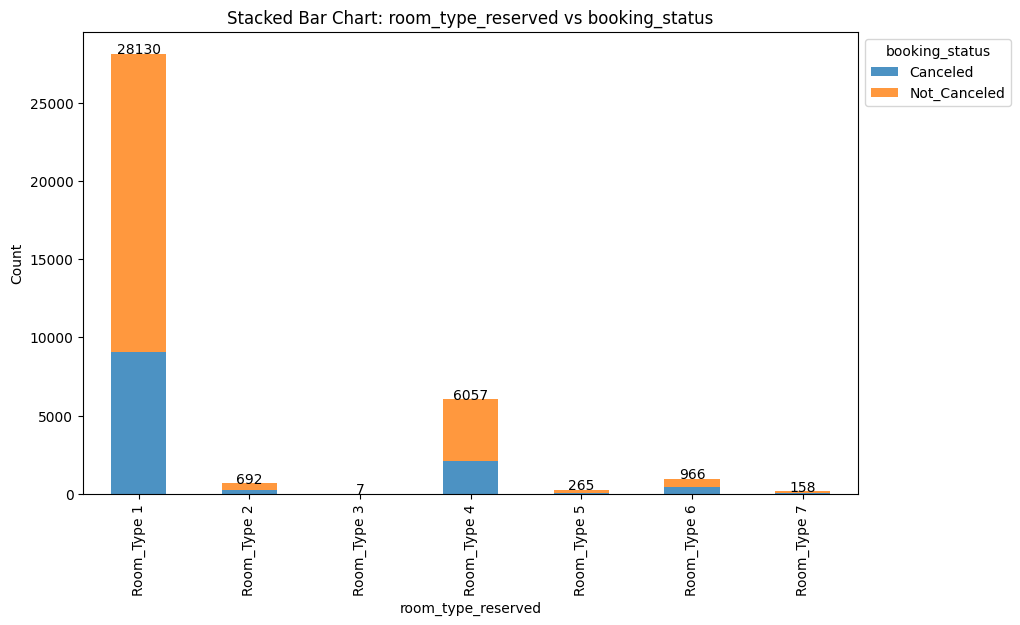

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
room_type_reserved,,,,,
Room_Type 1,9072,19058,28130,32.25,67.75
Room_Type 2,228,464,692,32.95,67.05
Room_Type 3,2,5,7,28.57,71.43
Room_Type 4,2069,3988,6057,34.16,65.84
Room_Type 5,72,193,265,27.17,72.83
Room_Type 6,406,560,966,42.03,57.97
Room_Type 7,36,122,158,22.78,77.22


In [86]:
stacked_barplot(df, 'room_type_reserved', 'booking_status')

##### Observations:

* The maximum number of canceled bookings occurred when the room_type_reserved was Room_Type 1, with around 32.25% cancellations (9072 canceled bookings out of 28130 total bookings).

* The highest percentage of canceled booking was Room_Type 6, with approximately 42% cancellations (406 canceled bookings out of 966 total bookings).

* The second highest percentage of canceled bookings was Room_Type 4, with approximately 34.2% cancellations (2069 canceled bookings out of 6057 total bookings).

#### Distribution of **`booking_status`** vs **`market_segment_type`** *(Categorical column & Categorical Column)*

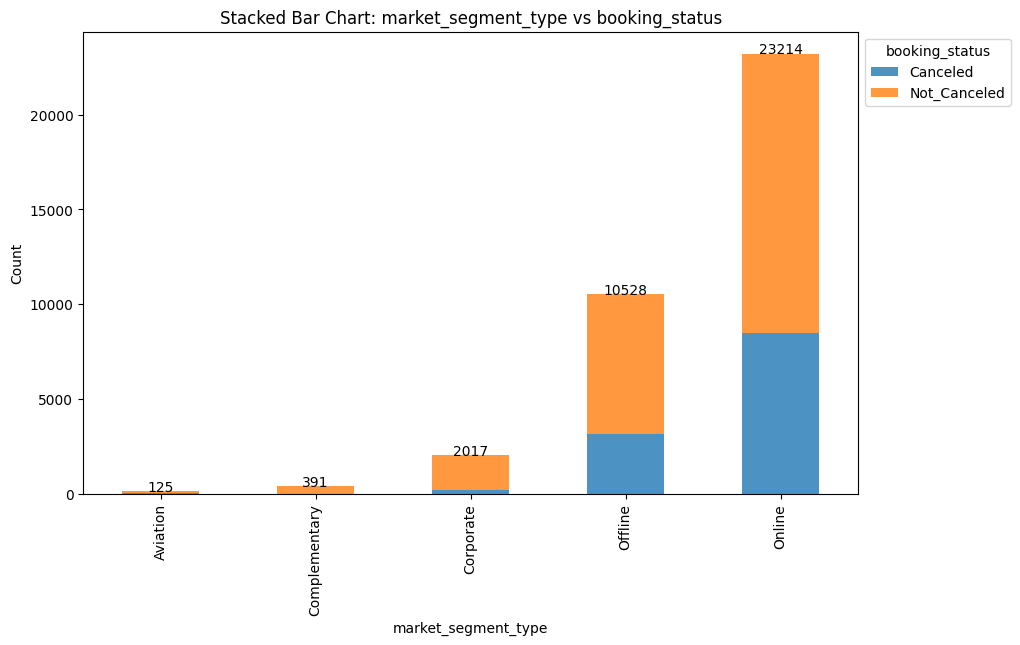

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
market_segment_type,,,,,
Aviation,37,88,125,29.60,70.40
Complementary,0,391,391,0.00,100.00
Corporate,220,1797,2017,10.91,89.09
Offline,3153,7375,10528,29.95,70.05
Online,8475,14739,23214,36.51,63.49


In [87]:
stacked_barplot(df, 'market_segment_type', 'booking_status')

##### Observations:

* The maximum number of canceled bookings occurred in the Online market_segment_type, with approximately 36.51% cancellations (8475 canceled bookings out of 23214 total bookings).

* The second-highest percentage of canceled bookings was observed in the Aviation market_segment_type, with approximately 29.6% cancellations (37 canceled bookings out of 125 total bookings).

* The highest percentage of not-canceled bookings was in the Complementary market_segment_type, with 100% not-canceled bookings (0 canceled bookings out of 391 total bookings), followed by the Corporate market_segment_type, with approximately 89.1% not-canceled bookings (220 canceled bookings out of 2,017 total bookings).

#### Distribution of **`avg_price_per_room`** vs **`arrival_month`**  *(Numerical column &  Categorical Column)*

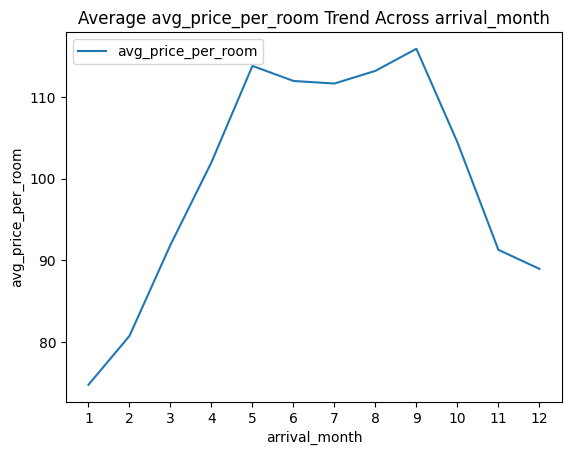

In [88]:
line_plot(df, 'avg_price_per_room', 'arrival_month')

##### Observations:

* `The highest avg_price_per_room` occurred in *`September`*, followed by *`May`*

#### Distribution of **`avg_price_per_room`** vs **`market_segment_type`** *(Numerical column &  Categorical Column)*

In [89]:
segment_avg_price = df.groupby('market_segment_type').agg({'avg_price_per_room':'mean'}).sort_values(by='avg_price_per_room', ascending=False).reset_index()
segment_avg_price['avg_price_per_room'] = segment_avg_price['avg_price_per_room'].round(2)
segment_avg_price

,market_segment_type,avg_price_per_room
0,Online,112.26
1,Aviation,100.70
2,Offline,91.63
3,Corporate,82.91
4,Complementary,3.14


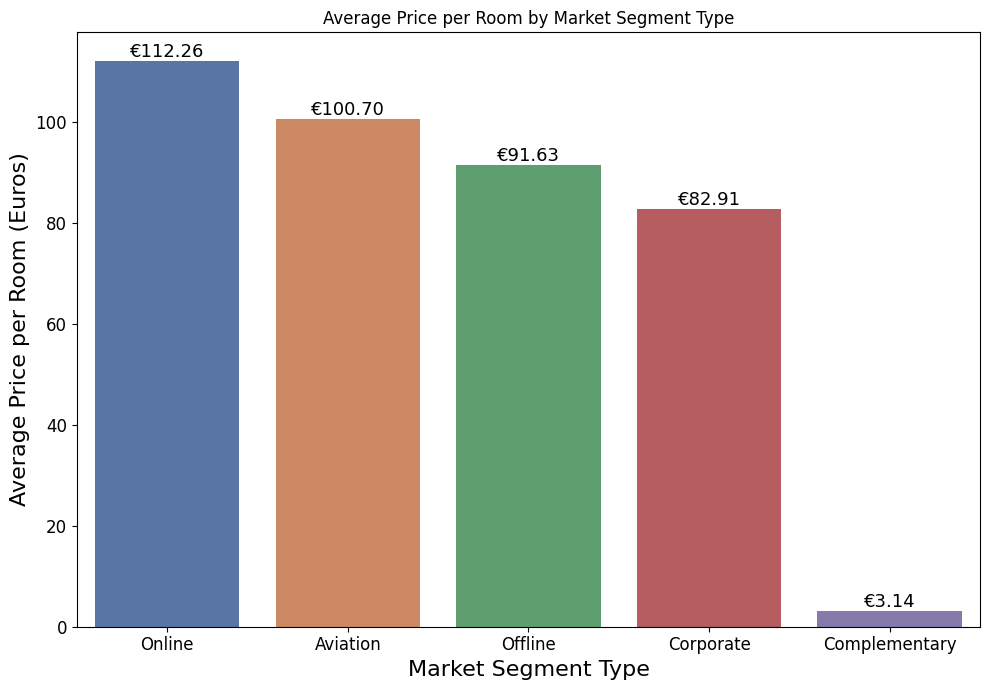

In [90]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x='market_segment_type',
    y='avg_price_per_room',
    data=segment_avg_price,
    palette='deep'
)
ax.set_title('Average Price per Room by Market Segment Type', fontsize=12)
ax.set_xlabel('Market Segment Type', fontsize=16)
ax.set_ylabel('Average Price per Room (Euros)', fontsize=16)
ax.tick_params(axis='both', labelsize=12)


for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'€{height:.2f}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=13
    )

plt.tight_layout()
plt.show()

##### Observations:
* The room prices vary across different market_segment_type.

* The `Online` market_segment_type has most expensive arund `€112.26` avg price per room.

* On the other hand Aviation market_segment_type has second most expensive avg_price_per_room approximately `€100.70` followed by Offline around `€91.63` and so on.

* The least expensive avg_price_per_room is `Complementary` market_segment_type.

## **Questions**

#### **Q1 What are the busiest months in the hotel?**

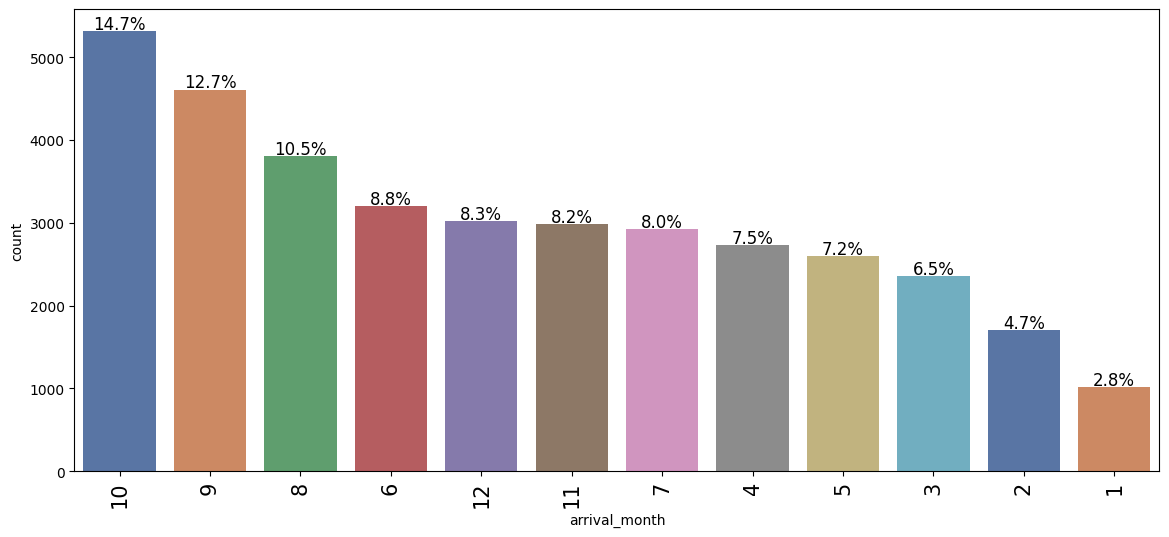

In [91]:
labeled_barplot(df, 'arrival_month', perc=True);

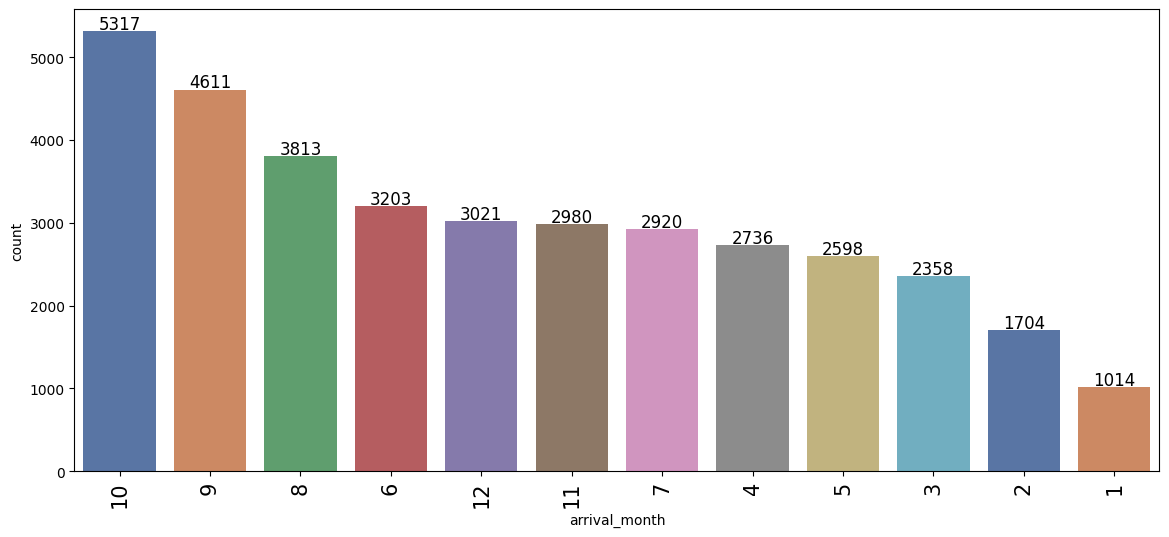

In [92]:
labeled_barplot(df, 'arrival_month');

##### Observations:
* The busiest month is *`October`* with around *`14.7%`* of the total bookings.
* The second busiest month is September with approximately 12.7% of the total booking, followed by August with 10.5% of the total bookings.

#### **Q2 Which market segment do most of the guests come from?**

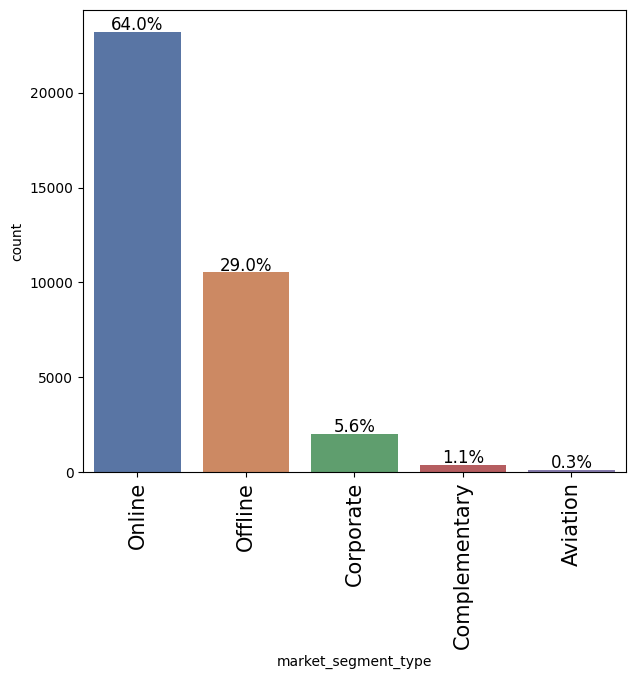

In [93]:
labeled_barplot(df, 'market_segment_type', perc=True);

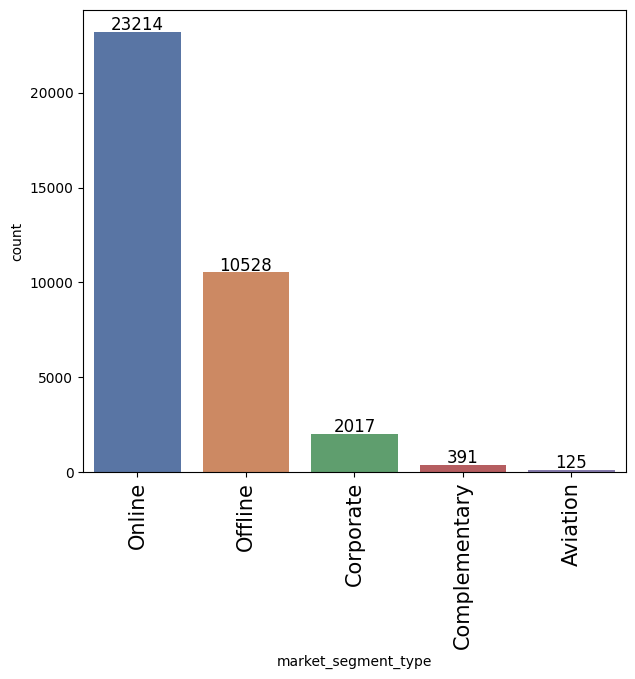

In [94]:
labeled_barplot(df, 'market_segment_type');

##### Observations:

* The majority of the guest come from *`Online`* `market_segment_type`, followed by *`Offline`*, *`Corporate`* and so on.

* The *`online`* `market_segment_type` has *`23214 bookings, around 64%`* of the total.

* The *`Offline`* `market_segment_type` has *`10528 bookings, approximately 29%`* of the total.

* The *`rest (Aviation, Corporate, Complementary)`* `market_segment_type` has around *`7%`* of the total.

#### **Q3 Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?**

In [95]:
segment_avg_price = df.groupby('market_segment_type').agg({'avg_price_per_room':'mean'}).sort_values(by='avg_price_per_room', ascending=False).reset_index()
segment_avg_price['avg_price_per_room'] = segment_avg_price['avg_price_per_room'].round(2)
segment_avg_price

,market_segment_type,avg_price_per_room
0,Online,112.26
1,Aviation,100.70
2,Offline,91.63
3,Corporate,82.91
4,Complementary,3.14


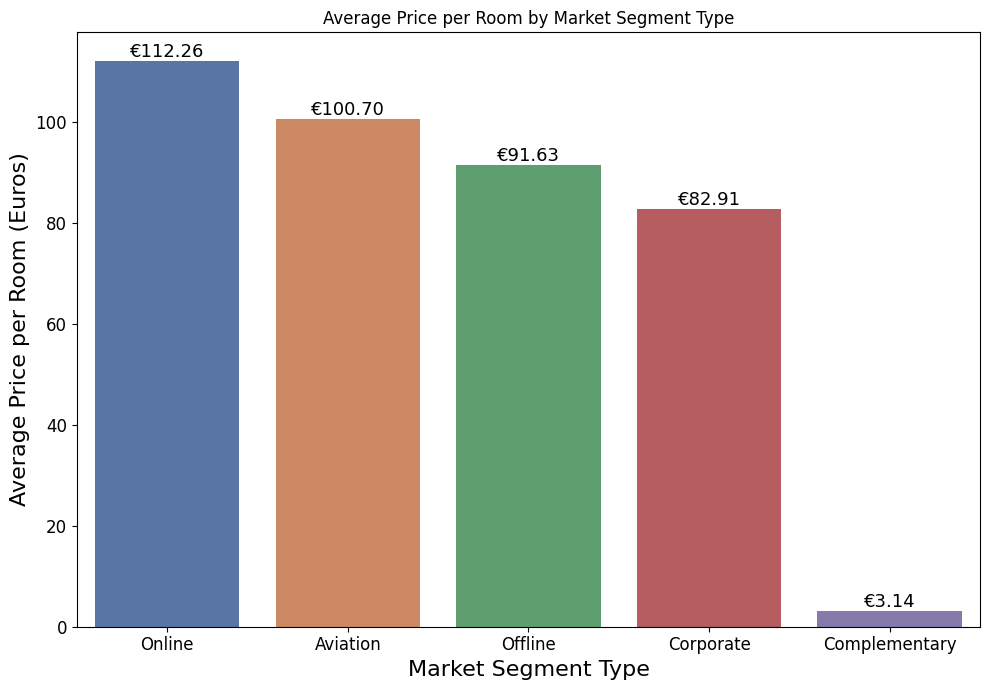

In [96]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x='market_segment_type',
    y='avg_price_per_room',
    data=segment_avg_price,
    palette='deep'
)
ax.set_title('Average Price per Room by Market Segment Type', fontsize=12)
ax.set_xlabel('Market Segment Type', fontsize=16)
ax.set_ylabel('Average Price per Room (Euros)', fontsize=16)
ax.tick_params(axis='both', labelsize=12)


for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'€{height:.2f}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=13
    )

plt.tight_layout()
plt.show()

##### Observations:
* The room prices vary across different market_segment_type.
* The `Online` market_segment_type has most expensive arund `€112.26` avg price per room.
* On the other hand Aviation market_segment_type has second most expensive avg_price_per_room approximately `€100.70` followed by Offline around `€91.63 `and so on.
* The least expensive avg_price_per_room is `Complementary` market_segment_type.

#### **Q4 What percentage of bookings are canceled?**

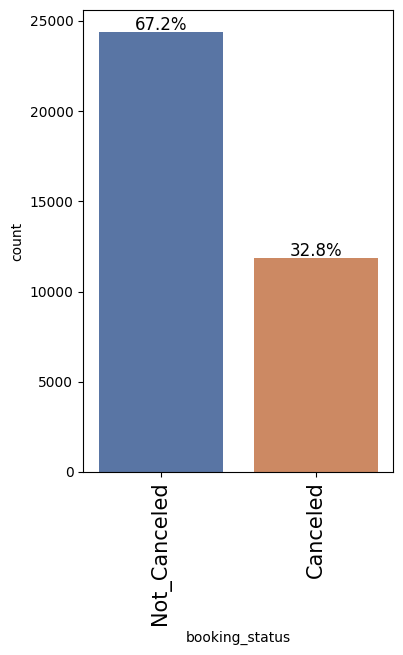

In [97]:
labeled_barplot(df, 'booking_status', perc=True);

##### Observations:

* Approximately `32.8%` of bookings are canceled.

#### **Q5 Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?**

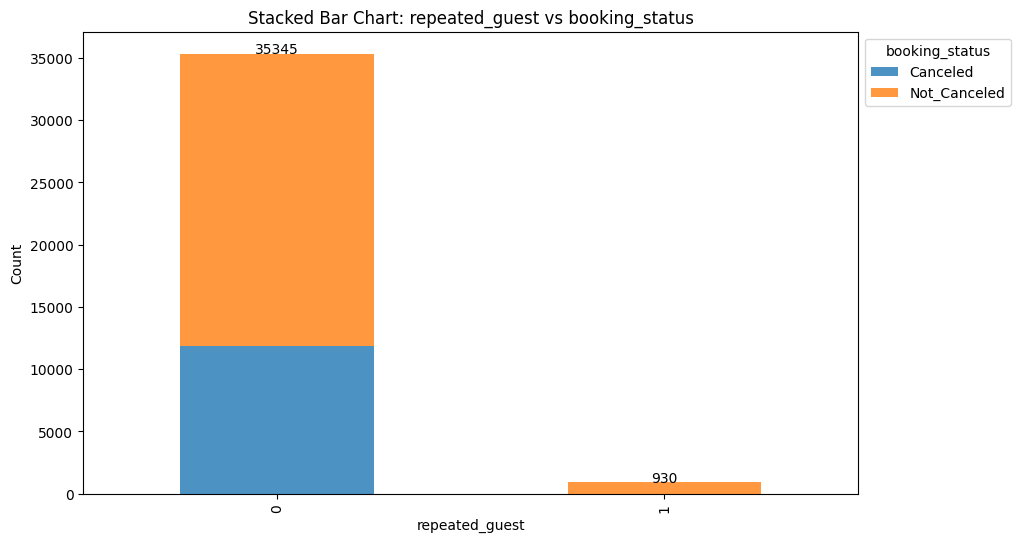

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
repeated_guest,,,,,
0,11869,23476,35345,33.58,66.42
1,16,914,930,1.72,98.28


In [98]:
stacked_barplot(df, 'repeated_guest', 'booking_status')

##### Observations:
* About `1.72%` of repeating guests cancel.

#### **Q6 Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?**

##### Hypothesis Analysis

In [99]:
# level of significance = 5%  given for the statistical analysis
alpha = 0.05

###### **Step1:** Formulate the null & alternate hypothesis based on above question:

* `Null Hypothesis H0`: **Number of special requests is independent of booking status**
* `Alternate Hypothesis Ha`: **Number of special requests is dependent of booking status**

###### **Step 2:** Select the appropiate test
Assumptions:
* We have two categorical variables i.e. `no_of_special_requests` status and `booking_status`.
* Random sampling from the population.
* Expected value of the number of sample observations in each level of the varibale is atleast 5.

We'll use => **Chi_square_test of independence.**

formula is: **stats.`chi2_contingency`(`contingency_table`)**

* To perform the Chi-squared test of independance we need to create the contingency table.
* A contingency table is a tabular representation of categorical data.
* The pandas crosstab() function is used to create a contingency table.

In [100]:
contingency_table = pd.crosstab(df['no_of_special_requests'], df['booking_status'])
contingency_table

booking_status,Canceled,Not_Canceled
no_of_special_requests,,
0,8545,11232
1,2703,8670
2,637,3727
3,0,675
4,0,78
5,0,8


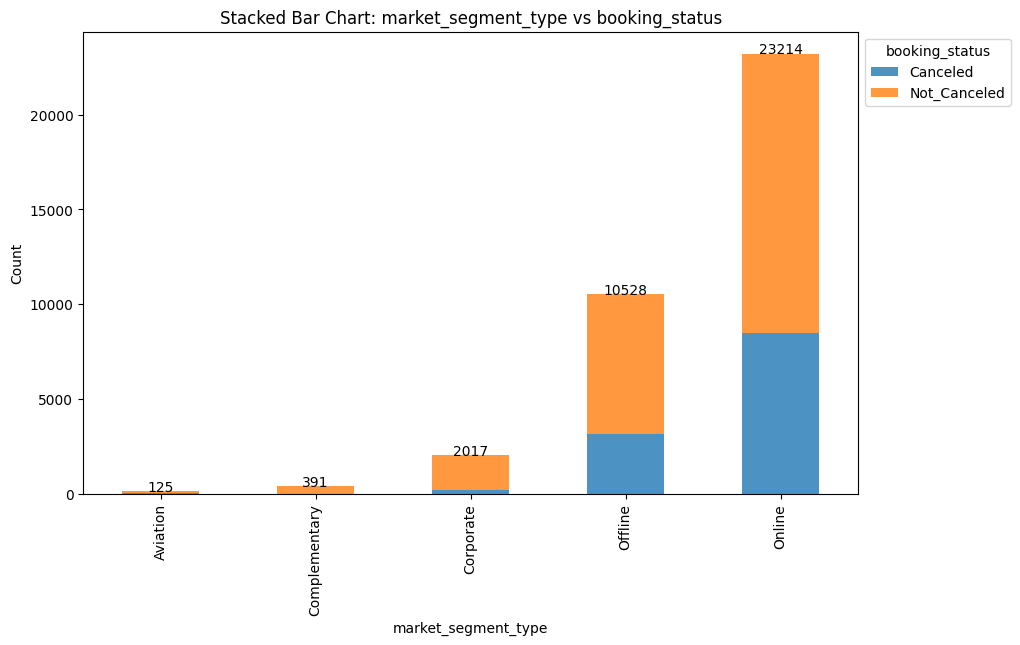

booking_status,Canceled,Not_Canceled,All,Canceled(%),Not_Canceled(%)
market_segment_type,,,,,
Aviation,37,88,125,29.60,70.40
Complementary,0,391,391,0.00,100.00
Corporate,220,1797,2017,10.91,89.09
Offline,3153,7375,10528,29.95,70.05
Online,8475,14739,23214,36.51,63.49


In [101]:
stacked_barplot(df, 'market_segment_type', 'booking_status')

###### **Step3:** Calculate the p-value

In [102]:
chi2_statistic, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print('chi2_statistic', chi2_statistic)
print('p_value', p_value)

chi2_statistic 2421.6187208019905
p_value 0.0


###### **Step4:** Inference based on the p-value

In [103]:
if p_value < 0.05:
    print(f'As the p-value {round(p_value,3)} is less than the level of significance({alpha}), we reject the null hypothesis.')
else:
    print(f'As the p-value {round(p_value,3)} is greater than the level of significance({alpha}), we fail to reject the null hypothesis.')

As the p-value 0.0 is less than the level of significance(0.05), we reject the null hypothesis.


##### Observations:
* At a 5% of significance level, we **`reject the null hypothesis`**. Hence, we have **enough statistical evidence** to say that the `no_of_special_requests` is **`dependent`** of `booking status`.

## **Data Preprocessing**

#### **Checking for null values**

In [104]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


##### Observations:
* As we can see, all the columns has `0 missing values`. It means, there are no missing values in the dataset.

#### **Dropping the column (Booking_ID) from the data frame**

In [105]:
df.Booking_ID.nunique()

36275

##### Observations:
* The `Booking_ID` column contains only unique values, so we can drop it.

In [106]:
# As the booking id has unique values we can drop the Booking_ID column from the data frame.
df = df.drop(labels="Booking_ID", axis=1)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [107]:
df.shape

(36275, 18)

##### Observations:
* There are *`18 columns`* (Previously 19 columns) in new data frame.

#### **Treat Outliers**

* All the values smaller than the lower whisker will be assigned the value of the lower whisker, and all the values above the upper whisker will be assigned the value of the upper whisker.

In [108]:
# functions to treat outliers by flooring and capping

def treat_outliers_all(df, col_list):
    """
    Treat outliers in a list of variables

    df: dataframe
    col_list: list of dataframe columns
    """
    for c in col_list:
        df = treat_outliers(df, c)

    return df


def treat_outliers(df, col):
    """
    Treats outliers in a variable

    df: dataframe
    col: dataframe column
    """
    Q1 = df[col].quantile(0.25)  # 25th quantile
    Q3 = df[col].quantile(0.75)  # 75th quantile
    IQR = Q3 - Q1
    Lower_Whisker = Q1 - 1.5 * IQR
    Upper_Whisker = Q3 + 1.5 * IQR

    # all the values smaller than Lower_Whisker will be assigned the value of Lower_Whisker
    # all the values greater than Upper_Whisker will be assigned the value of Upper_Whisker
    df[col] = np.clip(df[col], Lower_Whisker, Upper_Whisker)

    return df

#### Outlier Detection

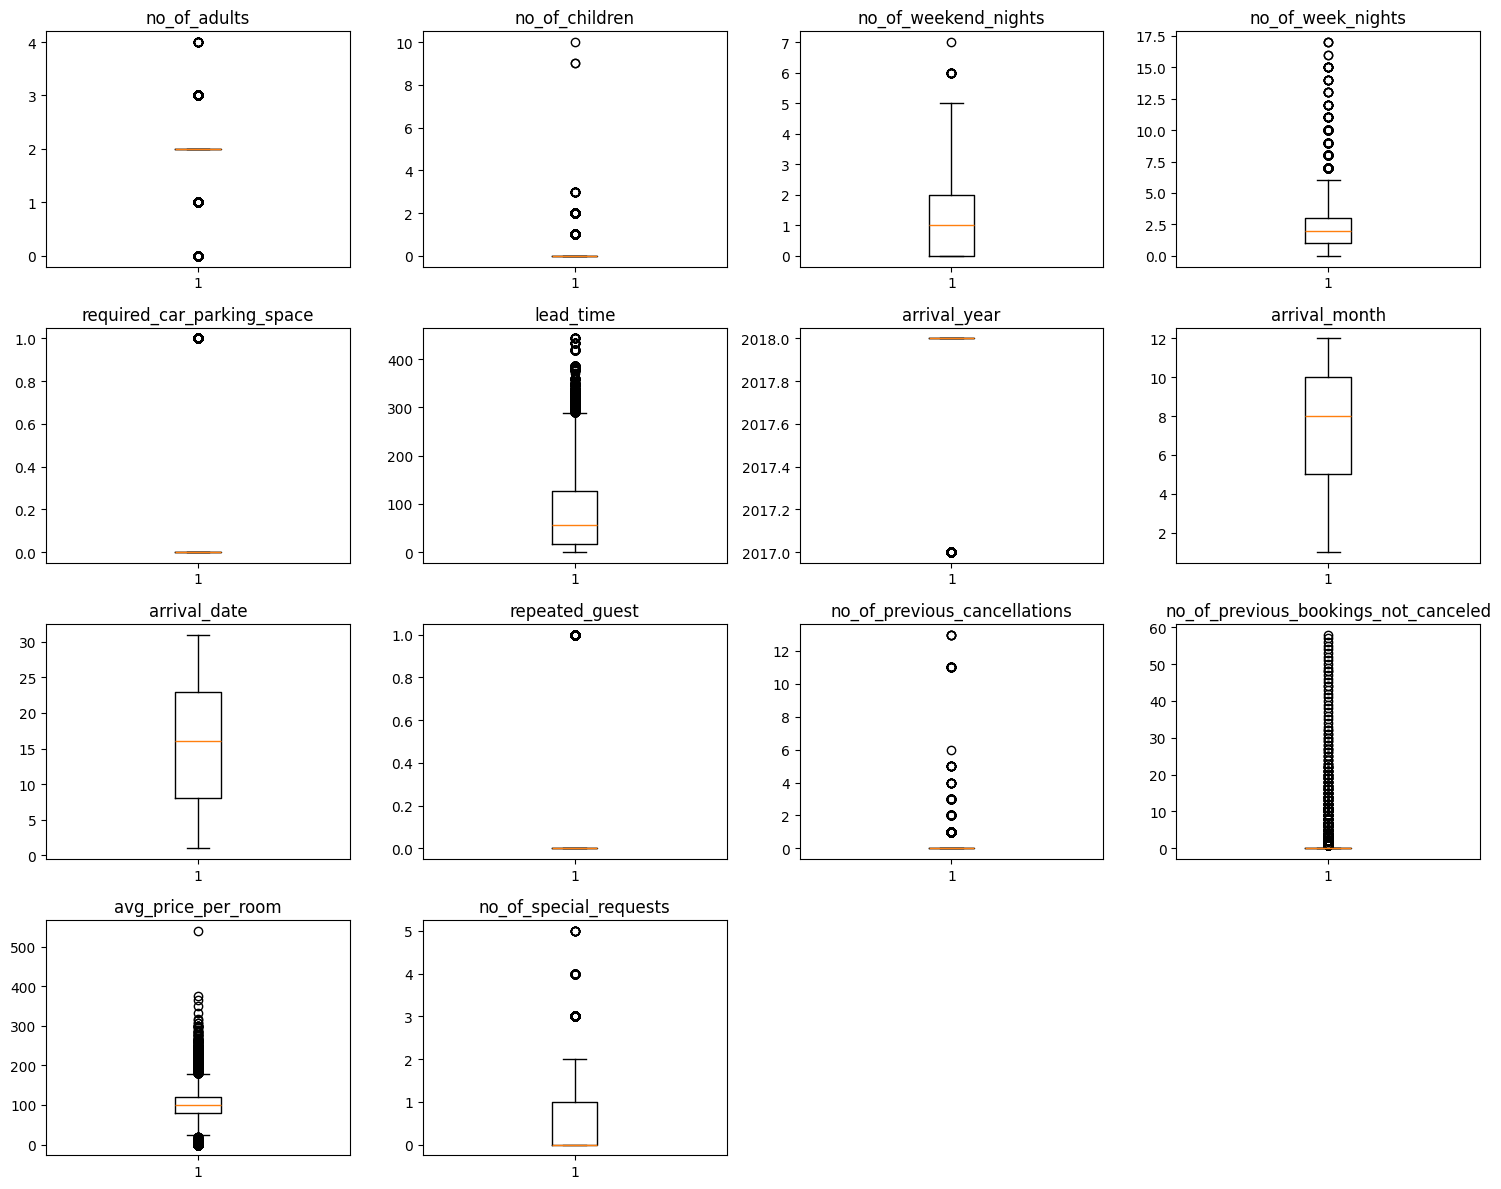

In [109]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

##### Observations

* We are going to `include the outliers` in our analysis because they contain valuable information.

#### Encoading Categorical Variables

In [110]:
# Convert Cancelled booking to 1 and Not-Cancelled to 0
df['booking_status'] = df['booking_status'].apply( lambda x: 1 if x=='Canceled' else 0)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,0
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,1
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,1
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,1


#### **Data Preparation**

In [111]:
# specifying the independent  and dependent variables
X = df.drop(['booking_status'], axis=1)
Y = df['booking_status']

# Adding constant
# X = sm.add_constant(X)
# creating dummy variables
X = pd.get_dummies(X,columns=X.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True,)

X.shape

(36275, 27)

In [112]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=1)

print("{0:0.2f}% of the data is allocated to the training set.".format((len(X_train)/len(df.index)) * 100))
print("{0:0.2f}% of the data is allocated to the test set.".format((len(X_test)/len(df.index)) * 100))

70.00% of the data is allocated to the training set.
30.00% of the data is allocated to the test set.


In [113]:
print('Shape of the training set:', X_train.shape[0])
print('Shape of test set:', X_test.shape[0])
print()
print("-"*50)
print('Percentage of Classes in Training Set:', Y_train.value_counts(normalize=True))
print()
print("-"*50)
print('Percentage of Classes in Test Set:', Y_test.value_counts(normalize=True))

Shape of the training set: 25392
Shape of test set: 10883

--------------------------------------------------
Percentage of Classes in Training Set: booking_status
0    0.670644
1    0.329356
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Test Set: booking_status
0    0.676376
1    0.323624
Name: proportion, dtype: float64


In [114]:
X.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0,False,False,False,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1,False,False,True,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,2018,2,28,0,0,0,60.00,0,False,False,False,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,2018,5,20,0,0,0,100.00,0,False,False,False,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,2018,4,11,0,0,0,94.50,0,False,False,True,False,False,False,False,False,False,False,False,False,True


In [115]:
Y.head()

,booking_status
0,0
1,0
2,1
3,1
4,1


In [116]:
# Making sure our data is of type float.
X = X.astype(float)
X.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2.0,0.0,1.0,2.0,0.0,224.0,2017.0,10.0,2.0,0.0,0.0,0.0,65.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2.0,0.0,2.0,3.0,0.0,5.0,2018.0,11.0,6.0,0.0,0.0,0.0,106.68,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,2.0,1.0,0.0,1.0,2018.0,2.0,28.0,0.0,0.0,0.0,60.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2.0,0.0,0.0,2.0,0.0,211.0,2018.0,5.0,20.0,0.0,0.0,0.0,100.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2.0,0.0,1.0,1.0,0.0,48.0,2018.0,4.0,11.0,0.0,0.0,0.0,94.50,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [117]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  float64
 1   no_of_children                        36275 non-null  float64
 2   no_of_weekend_nights                  36275 non-null  float64
 3   no_of_week_nights                     36275 non-null  float64
 4   required_car_parking_space            36275 non-null  float64
 5   lead_time                             36275 non-null  float64
 6   arrival_year                          36275 non-null  float64
 7   arrival_month                         36275 non-null  float64
 8   arrival_date                          36275 non-null  float64
 9   repeated_guest                        36275 non-null  float64
 10  no_of_previous_cancellations          36275 non-null  float64
 11  no_of_previous_

#### **Spliting the data**

In [118]:
# We will use 70% of data for training and 30% for testing.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=1)

print("{0:0.2f}% of the data is allocated to the training set.".format((len(X_train)/len(df.index)) * 100))
print("{0:0.2f}% of the data is allocated to the test set.".format((len(X_test)/len(df.index)) * 100))

70.00% of the data is allocated to the training set.
30.00% of the data is allocated to the test set.


In [119]:
print('Shape of the training set:', X_train.shape[0])
print('Shape of test set:', X_test.shape[0])
print()
print("-"*50)
print('Percentage of Classes in Training Set:', Y_train.value_counts(normalize=True))
print()
print("-"*50)
print('Percentage of Classes in Test Set:', Y_test.value_counts(normalize=True))

Shape of the training set: 25392
Shape of test set: 10883

--------------------------------------------------
Percentage of Classes in Training Set: booking_status
0    0.670644
1    0.329356
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Test Set: booking_status
0    0.676376
1    0.323624
Name: proportion, dtype: float64


## **Model Building**

### **Model evaluation criterion**

#### **Potential Errors in Predictions:**
The model might make incorrect predictions, such as:

* Predicting that a person will cancel their booking, but they do not.
* Predicting that a person will not cancel their booking, but they do.


**Which Scenario is More Critical?**

* Predicting cancellation when the booking is not canceled:
This could result in reallocating the room to another guest, leaving no room for the original customer upon arrival. The hotel might need to offer a complimentary upgrade, leading to financial losses, potential loss of customer loyalty, and negative reviews.

* Predicting no cancellation when the booking is canceled:
This would result in revenue loss from the unfulfilled reservation, additional costs for remarketing the room, and likely rebooking it at a discounted rate.

**How to Minimize Costs and Maximize True Positives?**

**Focus on F1 Score:**

* Maximizing the F1 score ensures a balanced approach to correctly identifying both classes (cancellations and non-cancellations), thereby reducing the likelihood of costly errors.

In [120]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels

def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [121]:
# Computing the confusion matrix

def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### **Logistic Regression**

#### **Model Support Functions**

In [122]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [123]:
# defining a function to plot the confusion_matrix of a classification model

def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=labels, fmt="", cmap='viridis')
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### **Logistic Regression with Sklearn library**

##### **Model Building**

In [124]:
def model_performance_logistic_regression(label, score_arr):
  metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1  "],
    "Score": score_arr
  }

  df_metrics = pd.DataFrame(metrics).T

  print("-"*10, label, "-"*10)
  print("\n", df_metrics.to_string(index=False, header=False))

  return

In [125]:
lg = LogisticRegression(solver="liblinear", random_state=1)
model = lg.fit(X_train, Y_train)

##### **Checking model performance on training set**

In [126]:
# predicting on training set
Y_pred_train = lg.predict(X_train)

In [127]:
score_arr = [
    accuracy_score(Y_train, Y_pred_train),
    precision_score(Y_train, Y_pred_train),
    recall_score(Y_train, Y_pred_train),
    f1_score(Y_train, Y_pred_train)
]

model_performance_logistic_regression("Training Set Performance", score_arr)

---------- Training Set Performance ----------

  Accuracy Precision    Recall      F1  
 0.798125  0.732376  0.609949  0.665579


##### **Checking performance on test set**

In [128]:
# predicting on the test set
Y_pred_test = lg.predict(X_test)

In [129]:
score_arr = [
    accuracy_score(Y_test, Y_pred_test),
    precision_score(Y_test, Y_pred_test),
    recall_score(Y_test, Y_pred_test),
    f1_score(Y_test, Y_pred_test)
]

model_performance_logistic_regression("Test Set Performance", score_arr)

---------- Test Set Performance ----------

  Accuracy Precision    Recall    F1  
 0.801985  0.730367  0.615275  0.6679


##### Observations:

* The precision rates for both the training and testing sets are approximately 0.73.

* The F1-scores for the training and testing sets are around 67%, which indicates a balance between precision and recall. The comparable values suggest that the model generalizes well and performs consistently on both datasets.

#### **Logistic Regression with statsmodels library**

##### **Model Building**

In [130]:
x = df.drop(["booking_status"], axis=1)
y = df["booking_status"]

x = pd.get_dummies(x, drop_first=True)

# adding constant
x = sm.add_constant(x)

In [131]:
# Making sure our data is of type float.
x = x.astype(float)
x.head()

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,1.0,2.0,0.0,1.0,2.0,0.0,224.0,2017.0,10.0,2.0,0.0,0.0,0.0,65.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,2.0,0.0,2.0,3.0,0.0,5.0,2018.0,11.0,6.0,0.0,0.0,0.0,106.68,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,1.0,0.0,2.0,1.0,0.0,1.0,2018.0,2.0,28.0,0.0,0.0,0.0,60.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,2.0,0.0,0.0,2.0,0.0,211.0,2018.0,5.0,20.0,0.0,0.0,0.0,100.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,2.0,0.0,1.0,1.0,0.0,48.0,2018.0,4.0,11.0,0.0,0.0,0.0,94.50,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [132]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   const                                 36275 non-null  float64
 1   no_of_adults                          36275 non-null  float64
 2   no_of_children                        36275 non-null  float64
 3   no_of_weekend_nights                  36275 non-null  float64
 4   no_of_week_nights                     36275 non-null  float64
 5   required_car_parking_space            36275 non-null  float64
 6   lead_time                             36275 non-null  float64
 7   arrival_year                          36275 non-null  float64
 8   arrival_month                         36275 non-null  float64
 9   arrival_date                          36275 non-null  float64
 10  repeated_guest                        36275 non-null  float64
 11  no_of_previous_

In [133]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

print("{0:0.2f}% of the data is allocated to the training set.".format((len(x_train)/len(df.index)) * 100))
print("{0:0.2f}% of the data is allocated to the test set.".format((len(x_test)/len(df.index)) * 100))

70.00% of the data is allocated to the training set.
30.00% of the data is allocated to the test set.


In [134]:
print('Shape of the training set:', x_train.shape[0])
print('Shape of test set:', x_test.shape[0])
print()
print("-"*50)
print('Percentage of Classes in Training Set:', y_train.value_counts(normalize=True))
print()
print("-"*50)
print('Percentage of Classes in Test Set:', y_test.value_counts(normalize=True))

Shape of the training set: 25392
Shape of test set: 10883

--------------------------------------------------
Percentage of Classes in Training Set: booking_status
0    0.670644
1    0.329356
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Test Set: booking_status
0    0.676376
1    0.323624
Name: proportion, dtype: float64


In [135]:
# fitting logistic regression model
logit = sm.Logit(y_train, x_train.astype(float))
lg = logit.fit(disp=False)

print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25364
Method:                           MLE   Df Model:                           27
Date:                Mon, 13 Jan 2025   Pseudo R-squ.:                  0.3293
Time:                        14:14:00   Log-Likelihood:                -10793.
converged:                      False   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -924.5923    120.817     -7.653      0.000   -1161.390    -687.795
no_of_adults                             0.1135      

In [136]:
print("-"*10, "Training performance model 1", "-"*10)
model_performance_classification_statsmodels(lg, x_train, y_train)

---------- Training performance model 1 ----------


,Accuracy,Recall,Precision,F1
0,0.806041,0.634222,0.739749,0.682933


###### Observations:

* `Negative coefficient` values indicate that the probability of booking cancellation decreases as the corresponding attribute value increases.

* `Positive coefficient` values indicate that the probability of booking cancellation increases as the corresponding attribute value increases.

* The `p-value` of a variable determines its statistical significance. At a significance level of 0.05 (5%), any variable with a p-value less than 0.05 is considered significant.

* The model's `F1 score` is approximately 0.68, and we aim to improve it further.

* `Multicollinearity` among the variables used to build the model can affect the reliability of the coefficients and p-values.

* To obtain reliable `coefficients and p-values`, we need to address and eliminate multicollinearity in the data.

#### **Model Performance Improvement:** `LRT with statsmodels library`


##### Checking Multicollinearity

In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

VIF standards:
* If VIF is between 1 and 5, then there is low multicollinearity.
* If VIF is between 5 and 10, we say there is moderate multicollinearity.
* If VIF is exceeding 10, it shows signs of high multicollinearity.

In [137]:
# Checking for multicollinearity using VIF
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["Features"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

In [138]:
vif_before = calculate_vif(x_train)
print("-"*15, "VIF before removing variables", "-"*15, "\n\n", vif_before)

--------------- VIF before removing variables --------------- 

                                 Features           VIF
0                                  const  3.946816e+07
1                           no_of_adults  1.348154e+00
2                         no_of_children  1.978229e+00
3                   no_of_weekend_nights  1.069475e+00
4                      no_of_week_nights  1.095667e+00
5             required_car_parking_space  1.039928e+00
6                              lead_time  1.394914e+00
7                           arrival_year  1.430830e+00
8                          arrival_month  1.275673e+00
9                           arrival_date  1.006738e+00
10                        repeated_guest  1.783516e+00
11          no_of_previous_cancellations  1.395689e+00
12  no_of_previous_bookings_not_canceled  1.651986e+00
13                    avg_price_per_room  2.050421e+00
14                no_of_special_requests  1.247278e+00
15         type_of_meal_plan_Meal Plan 2  1.271851e+00


In [139]:
vif_before = calculate_vif(x_train)[calculate_vif(x_train)["VIF"] > 5]
vif_before

,Features,VIF
0,const,3.946816e+07
25,market_segment_type_Corporate,1.692844e+01
26,market_segment_type_Offline,6.411392e+01
27,market_segment_type_Online,7.117643e+01


###### **Observations**

* Excluding the dummy variables, none of the other predictor variables have a VIF exceeding 5, indicating no multicollinearity among them.

* The predictors show no multicollinearity in the data.

* Since there is no multicollinearity, we can evaluate the p-values of the predictor variables to assess their significance.

* Out of the 20 variables in the logistic regression model, 7 predictor variables are statistically insignificant (p-value > 0.05).

* It is important to note that p-values may change after removing a variable. Therefore, the following iterative process will be used:

* Build the model and examine the p-values of the variables. Remove the variable with the highest p-value if it exceeds 0.05.

* Rebuild the model without the dropped variable, reassess the p-values, and remove the next variable with the highest p-value if necessary.

* Repeat this process until all remaining variables have a p-value ≤ 0.05.

##### **Removing high p-value variables**

In [140]:
# running a loop to drop variables with high p-value

# initial list of columns
cols = x_train.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = x_train[cols]

    # fitting the model
    model = sm.Logit(y_train, x_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'repeated_guest', 'no_of_previous_cancellations', 'avg_price_per_room', 'no_of_special_requests', 'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7', 'market_segment_type_Corporate', 'market_segment_type_Offline']


In [141]:
x_train1 = x_train[selected_features]
x_test1 = x_test[selected_features]

In [142]:
# Fit the lg1 model
logit1 = sm.Logit(y_train, x_train1.astype(float))
lg1 = logit1.fit()

print(lg1.summary())

Optimization terminated successfully.
         Current function value: 0.425677
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25370
Method:                           MLE   Df Model:                           21
Date:                Mon, 13 Jan 2025   Pseudo R-squ.:                  0.3283
Time:                        14:14:10   Log-Likelihood:                -10809.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           -917.2860    120.456     -7.615    

###### Observations

* Now no feature has p-value greater than 0.05, so we'll consider the features in X_train1 as the final ones and lg1 as final model.

##### **Coefficient interpretations**

* `Positive Coefficients:` Factors such as the number of adults, lead time prior to booking, arrival year (2018 vs. 2017), number of previous cancellations, average room price, total nights booked, selecting Meal Plan 2, and not selecting a meal plan have positive coefficients. This indicates that an increase in these factors raises the likelihood of a hotel booking being canceled.

* `Negative Coefficients:` Factors such as requiring a parking space, arrival month, being a repeat guest, number of special requests, and market segments for Corporate and Offline have negative coefficients. This indicates that an increase in these factors reduces the likelihood of a hotel booking being canceled.

###### **Converting coefficients to odds**

In [143]:
# converting coefficients to odds
odds = np.exp(lg1.params)

# finding the percentage change
perc_change_odds = (np.exp(lg1.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=x_train1.columns)

,Odds,Change_odd%
const,0.000000,-100.000000
no_of_adults,1.114754,11.475363
no_of_children,1.164360,16.436009
no_of_weekend_nights,1.114753,11.475256
no_of_week_nights,1.042636,4.263629
required_car_parking_space,0.203048,-79.695231
lead_time,1.015835,1.583521
arrival_year,1.573235,57.323511
arrival_month,0.958528,-4.147245
repeated_guest,0.064797,-93.520258


**Coefficient interpretations**

* `no_of_adults:` Holding all other features constant, a unit increase in the number of adults will increase the odds of a booking being canceled by 1.115 times, or an 11.48% increase in the odds of cancellation.

* `no_of_children:` Holding all other features constant, a unit increase in the number of children will increase the odds of a booking being canceled by 1.164 times, or a 16.44% increase in the odds of cancellation.

* `no_of_previous_cancellations:` Holding all other features constant, a unit increase in the number of previous cancellations will increase the odds of a booking being canceled by 1.257 times, or a 25.72% increase in the odds of cancellation.

* `required_car_parking_space:` Holding all other features constant, requiring a parking space will decrease the odds of a booking being canceled by 0.203 times, or a 79.70% decrease in the odds of cancellation.

* `lead_time:` Holding all other features constant, a unit increase in lead time will increase the odds of a booking being canceled by 1.016 times, or a 1.58% increase in the odds of cancellation.

* `repeated_guest:` Holding all other features constant, being a repeated guest will decrease the odds of a booking being canceled by 0.065 times, or a 93.52% decrease in the odds of cancellation.

* `avg_price_per_room:` Holding all other features constant, a unit increase in the average price per room will increase the odds of a booking being canceled by 1.019 times, or a 1.93% increase in the odds of cancellation.

* `no_of_special_requests:` Holding all other features constant, a unit increase in the number of special requests will decrease the odds of a booking being canceled by 0.230 times, or a 77.01% decrease in the odds of cancellation.

* `market_segment_type_Corporate:` Holding all other features constant, being in the Corporate market segment will decrease the odds of a booking being canceled by 0.453 times, or a 54.74% decrease in the odds of cancellation.

* `market_segment_type_Offline:` Holding all other features constant, being in the Offline market segment will decrease the odds of a booking being canceled by 0.168 times, or an 83.25% decrease in the odds of cancellation.

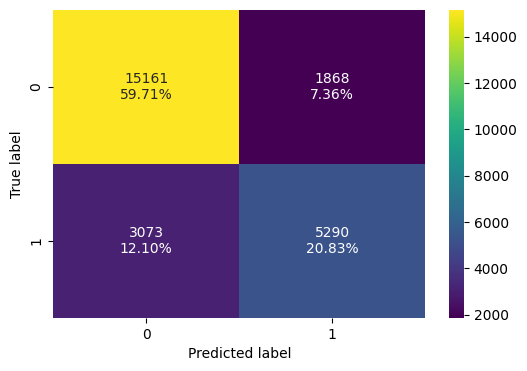

In [144]:
# creating confusion matrix
confusion_matrix_statsmodels(lg1, x_train1, y_train)

In [145]:
log_model_train_perf = model_performance_classification_statsmodels(lg1, x_train1, y_train)
log_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.805411,0.632548,0.739033,0.681657


We can see after dropping p-values there is no significant change in the model performance as compared to initial model.

In [146]:
# let's check the VIF of the predictors
vif_series1 = pd.Series(
    [variance_inflation_factor(x_train1.values, i) for i in range(x_train1.shape[1])],
    index=x_train1.columns,
    dtype=float,
)
print("VIF values: \n\n{}\n".format(vif_series1))

VIF values: 

const                             3.919313e+07
no_of_adults                      1.330888e+00
no_of_children                    1.975708e+00
no_of_weekend_nights              1.060484e+00
no_of_week_nights                 1.089929e+00
required_car_parking_space        1.039211e+00
lead_time                         1.375971e+00
arrival_year                      1.421149e+00
arrival_month                     1.266975e+00
repeated_guest                    1.531278e+00
no_of_previous_cancellations      1.203896e+00
avg_price_per_room                1.723392e+00
no_of_special_requests            1.237767e+00
type_of_meal_plan_Meal Plan 2     1.257758e+00
type_of_meal_plan_Not Selected    1.251531e+00
room_type_reserved_Room_Type 2    1.100851e+00
room_type_reserved_Room_Type 4    1.344786e+00
room_type_reserved_Room_Type 5    1.017588e+00
room_type_reserved_Room_Type 6    1.943614e+00
room_type_reserved_Room_Type 7    1.058229e+00
market_segment_type_Corporate     1.452903e+00

In [147]:
print("-"*15, "Training performance model 1", "-"*15)
model_performance_classification_statsmodels(lg, x_train, y_train)

--------------- Training performance model 1 ---------------


,Accuracy,Recall,Precision,F1
0,0.806041,0.634222,0.739749,0.682933


In [148]:
print("-"*15, "Training performance model 2", "-"*15)
model_performance_classification_statsmodels(lg1, x_train1, y_train)

--------------- Training performance model 2 ---------------


,Accuracy,Recall,Precision,F1
0,0.805411,0.632548,0.739033,0.681657


##### ROC Curve and ROC-AUC

###### ROC-AUC training set

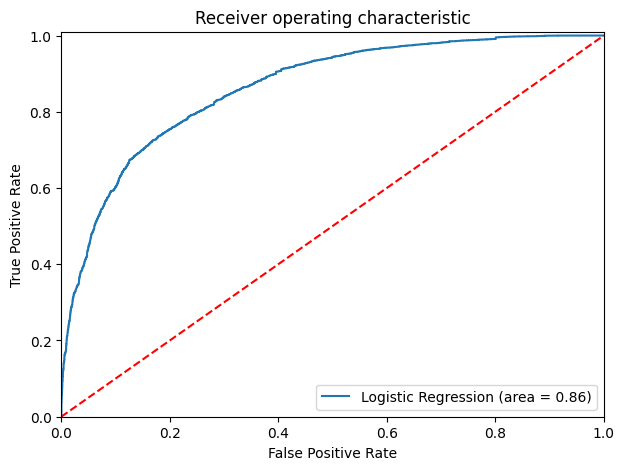

In [149]:
logit_roc_auc_train = roc_auc_score(y_train, lg1.predict(x_train1))
fpr, tpr, thresholds = roc_curve(y_train, lg1.predict(x_train1))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [150]:
fpr, tpr, thresholds = roc_curve(y_train, lg1.predict(x_train1))

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
optimal_threshold_auc_roc

0.37104666234890077

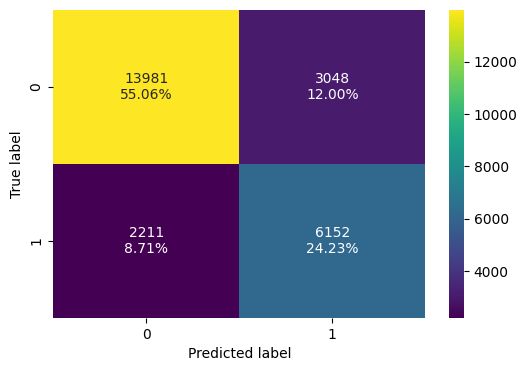

In [151]:
# creating confusion matrix
confusion_matrix_statsmodels(lg1, x_train1, y_train, threshold=optimal_threshold_auc_roc)

In [152]:
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_statsmodels(lg1, x_train1, y_train, threshold=optimal_threshold_auc_roc)

print("-"*15, "Training performance", "-"*15)
log_reg_model_train_perf_threshold_auc_roc

--------------- Training performance ---------------


,Accuracy,Recall,Precision,F1
0,0.792888,0.735621,0.668696,0.700564


Let's use Precision-Recall curve and see if we can find a better threshold

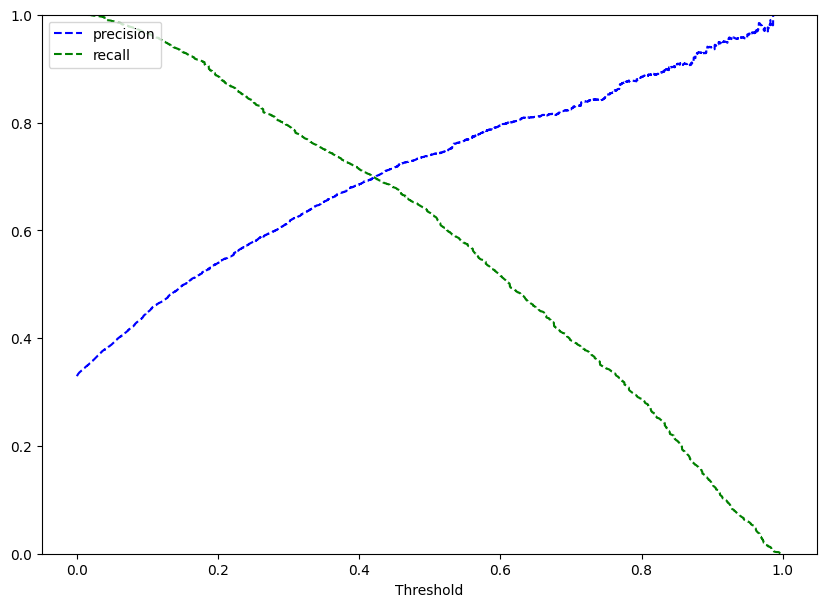

In [153]:
y_scores = lg1.predict(x_train1)
prec, rec, tre = precision_recall_curve(y_train, y_scores,)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

* At the threshold of approximately 0.42, we reach a balance of recall and precision scores.

In [154]:
# setting the threshold
optimal_threshold_curve = 0.42

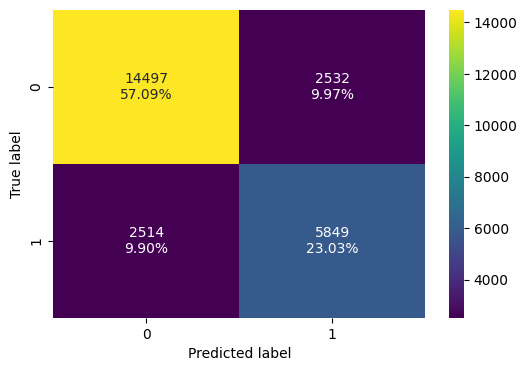

In [155]:
# creating confusion matrix
confusion_matrix_statsmodels(lg1,  x_train1, y_train, threshold=optimal_threshold_curve)

In [156]:
log_reg_model_train_perf_threshold_curve = model_performance_classification_statsmodels(lg1, x_train1, y_train, threshold=optimal_threshold_curve)

print("-"*15, "Training performance", "-"*15)
log_reg_model_train_perf_threshold_curve

--------------- Training performance ---------------


,Accuracy,Recall,Precision,F1
0,0.801276,0.69939,0.697888,0.698638


It seems that the F1 score has slightly decreased when compared to the optimal threshold obtained from the AUC-ROC curve.

Let's check the performance on the test set

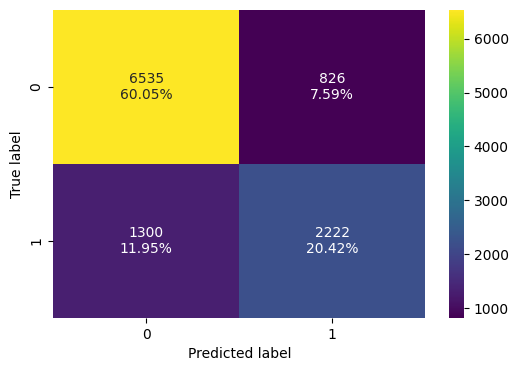

In [157]:
# creating confusion matrix
confusion_matrix_statsmodels(lg1, x_test1, y_test)

In [158]:
log_reg_model_test_perf = model_performance_classification_statsmodels(lg1, x_test1, y_test)

print("-"*15, "Test performance", "-"*15)
log_reg_model_test_perf

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.804649,0.630892,0.729003,0.676408


When applying our model to the test data using the default threshold, we obtained an F1 score of 0.67651.

###### ROC curve on test set

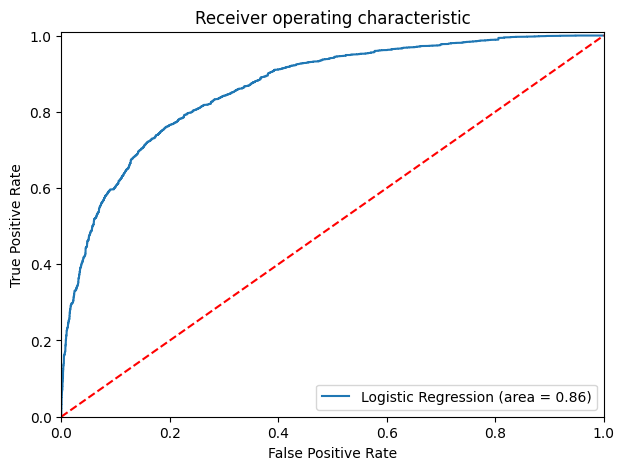

In [159]:
logit_roc_auc_train = roc_auc_score(y_test, lg1.predict(x_test1))
fpr, tpr, thresholds = roc_curve(y_test, lg1.predict(x_test1))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

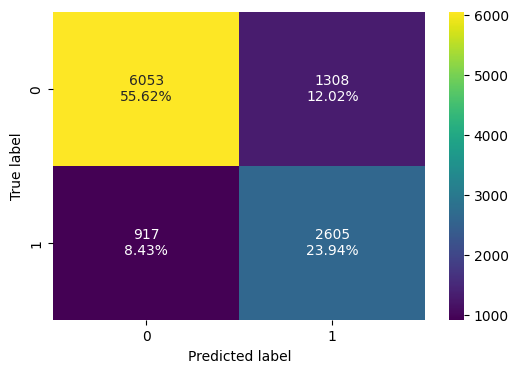

In [160]:
# creating confusion matrix
confusion_matrix_statsmodels(lg1, x_test1, y_test, threshold=0.37)

In [161]:
# checking model performance for this model
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_statsmodels(lg1, x_test1, y_test, threshold=optimal_threshold_auc_roc)

print("-"*15, "Test performance", "-"*15)
log_reg_model_test_perf_threshold_auc_roc

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.796012,0.739353,0.666667,0.701131


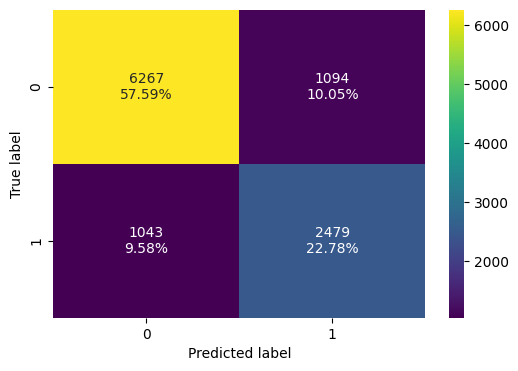

In [162]:
# creating confusion matrix
confusion_matrix_statsmodels(lg1, x_test1, y_test, threshold=0.42)

In [163]:
log_reg_model_test_perf_threshold_curve = model_performance_classification_statsmodels(lg1, x_test1, y_test, threshold=optimal_threshold_curve)

print("-"*15, "Test performance", "-"*15)
log_reg_model_test_perf_threshold_curve

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.803639,0.703861,0.693815,0.698802


#### **Model Performance Comparison:** **`LRT 0.5`** vs **`LRT 0.37`** vs **`LRT 0.42`**


In [164]:
models_train_comp_df = pd.concat(
    [
        log_model_train_perf.T,
        log_reg_model_train_perf_threshold_auc_roc.T,
        log_reg_model_train_perf_threshold_curve.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic_Regression_Threshold 0.5",
    "Logistic_Regression_Threshold 0.37",
    "Logistic_Regression_Threshold 0.42",
]

print("-"*40, "Training performance comparison", "-"*40)
models_train_comp_df

---------------------------------------- Training performance comparison ----------------------------------------


,Logistic_Regression_Threshold 0.5,Logistic_Regression_Threshold 0.37,Logistic_Regression_Threshold 0.42
Accuracy,0.805411,0.792888,0.801276
Recall,0.632548,0.735621,0.699390
Precision,0.739033,0.668696,0.697888
F1,0.681657,0.700564,0.698638


In [165]:
# test performance comparison

models_test_comp_df = pd.concat(
    [
        log_reg_model_test_perf.T,
        log_reg_model_test_perf_threshold_auc_roc.T,
        log_reg_model_test_perf_threshold_curve.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic_Regression_Threshold 0.5",
    "Logistic_Regression_Threshold 0.37",
    "Logistic_Regression_Threshold 0.42",
]

print("-"*40, "Test set performance comparison", "-"*40)
models_test_comp_df

---------------------------------------- Test set performance comparison ----------------------------------------


,Logistic_Regression_Threshold 0.5,Logistic_Regression_Threshold 0.37,Logistic_Regression_Threshold 0.42
Accuracy,0.804649,0.796012,0.803639
Recall,0.630892,0.739353,0.703861
Precision,0.729003,0.666667,0.693815
F1,0.676408,0.701131,0.698802


##### Observations

* All three models perform well on both the training and test data, suggesting they do not exhibit overfitting.

* Based on these results, we conclude that the `logistic regression model` with a **`threshold of 0.37`** provides `the best performance` across multiple metrics, including accuracy, recall, precision, and F1 score. As a result, it is recommended as the optimal model for predicting booking cancellations.

* This means that if the predicted probability of a booking being canceled exceeds 37%, it will be classified as a cancellation; if it is below 37%, it will be classified as a non-cancellation. This threshold selection ensures a balance between effectively identifying cancellations (high recall) and reducing false positives (high precision).



* We successfully built a predictive model for INN Hotels that can predict which bookings are likely to be canceled, achieving an F1 score of 0.70 on the training set.

* All logistic regression models have demonstrated generalized performance on both the training and test sets, indicating that the model is expected to perform similarly in production for INN Hotels.

* The coefficients for the number of adults, lead time prior to a booking, arrival year (e.g., 2018 vs. 2017), number of previous cancellations, average room price, total nights booked, selecting Meal Plan 2, and not selecting a meal plan are positive. This means an increase in these features will lead to a higher likelihood of a hotel booking being canceled.

* The coefficients for requiring a parking space, arrival month, being a repeat guest, number of special requests, and the market segments for Corporate and Offline are negative. This indicates that an increase in these features will reduce the likelihood of a hotel booking being canceled.

### **kNN Classifier**

#### **Model Support Functions**

In [166]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [167]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [168]:
# convert the features into z scores as we do not know what units / scales were used and store them in new dataframe
# It is always adviced to scale numeric attributes in models that calculate distances.

# convert all attributes to Z scale
XScaled  = X.apply(zscore)

# Check for NaN values and impute if necessary
imputer = SimpleImputer(strategy='mean') # or 'median', 'most_frequent'
XScaled = imputer.fit_transform(XScaled)

# Instead of using X.columns directly, get the columns of the scaled DataFrame
XScaled = pd.DataFrame(XScaled, columns=X.columns[~X.apply(zscore).isnull().all()]) # Getting the correct column names after zscore

XScaled.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,4.270112e-17,1.000014,-3.556844,0.298893,0.298893,0.298893,4.154629
no_of_children,36275.0,1.518044e-17,1.000014,-0.261470,-0.261470,-0.261470,-0.261470,24.574456
no_of_weekend_nights,36275.0,9.950536e-17,1.000014,-0.931190,-0.931190,0.217401,1.365993,7.108950
no_of_week_nights,36275.0,-1.165466e-16,1.000014,-1.562353,-0.853578,-0.144803,0.563972,10.486819
required_car_parking_space,36275.0,3.917534e-17,1.000014,-0.178819,-0.178819,-0.178819,-0.178819,5.592239
lead_time,36275.0,6.463931e-17,1.000014,-0.991888,-0.794052,-0.328554,0.474428,4.163493
arrival_year,36275.0,-2.254506e-13,1.000014,-2.137469,0.467843,0.467843,0.467843,0.467843
arrival_month,36275.0,1.436266e-16,1.000014,-2.092496,-0.789501,0.187744,0.839242,1.490739
arrival_date,36275.0,-4.701041e-17,1.000014,-1.670074,-0.869189,0.046109,0.846994,1.762292
repeated_guest,36275.0,1.704127e-17,1.000014,-0.162210,-0.162210,-0.162210,-0.162210,6.164850


#### **Build kNN model**

##### **k with different values**

In [169]:
neighbors = [i for i in range(3,20) if i%2 != 0]

recall_scores_train = []
recall_scores_test = []

# perform recall metrics
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)

    # predict on train and test
    y_pred_train = knn.predict(X_train)
    y_pred_test = knn.predict(X_test)

    # evaluate recall on train and test
    scores_train = recall_score(Y_train, y_pred_train)
    recall_scores_train.append(scores_train)
    scores_test = recall_score(Y_test, y_pred_test)
    recall_scores_test.append(scores_test)

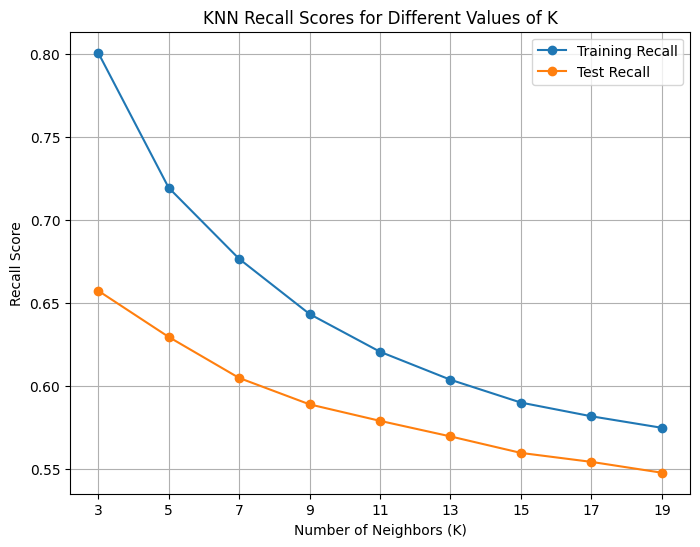

In [170]:
# Plot recall scores for training and test sets

plt.figure(figsize=(8, 6))
plt.plot(neighbors, recall_scores_train, label='Training Recall', marker='o')
plt.plot(neighbors, recall_scores_test, label='Test Recall', marker='o')
plt.title('KNN Recall Scores for Different Values of K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Recall Score')
plt.xticks(neighbors)
plt.legend()
plt.grid(True)
plt.show()

#### **Model Performance Improvement:**


##### **k=3**

In [171]:
knn_3 = KNeighborsClassifier(n_neighbors = 3)
knn_3.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=3)

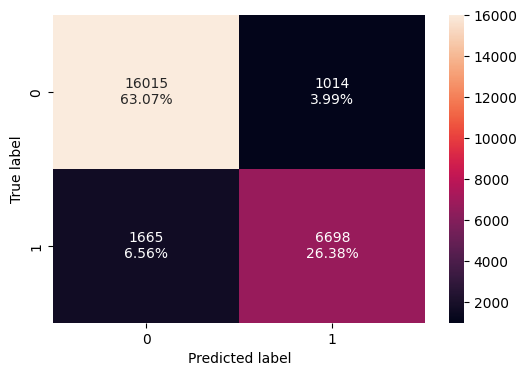

In [172]:
confusion_matrix_sklearn(knn_3, X_train, Y_train)

In [173]:
knn_perf_train_3 = model_performance_classification_sklearn(knn_3, X_train, Y_train)
knn_perf_train_3

,Accuracy,Recall,Precision,F1
0,0.894494,0.800909,0.868517,0.833344


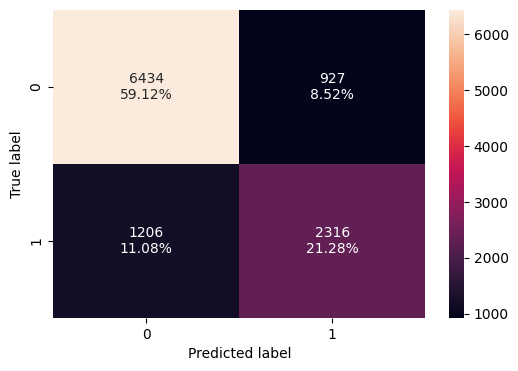

In [174]:
confusion_matrix_sklearn(knn_3, X_test, Y_test)

In [175]:
knn_perf_test_3 = model_performance_classification_sklearn(knn_3, X_test, Y_test)
knn_perf_test_3

,Accuracy,Recall,Precision,F1
0,0.804006,0.657581,0.714154,0.684701


##### **k=5**

In [176]:
knn_5 = KNeighborsClassifier(n_neighbors = 5)
knn_5.fit(X_train, Y_train)

KNeighborsClassifier()

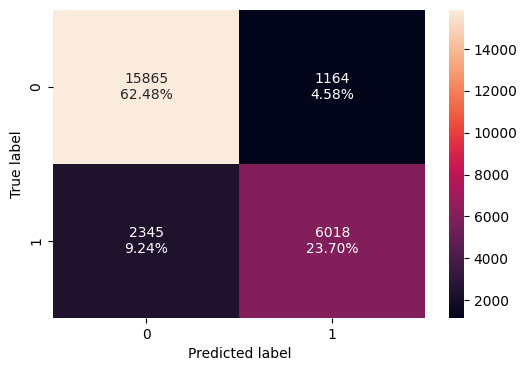

In [177]:
confusion_matrix_sklearn(knn_5, X_train, Y_train)

In [178]:
knn_perf_train_5 = model_performance_classification_sklearn(knn_5, X_train, Y_train)
knn_perf_train_5

,Accuracy,Recall,Precision,F1
0,0.861807,0.719598,0.837928,0.774268


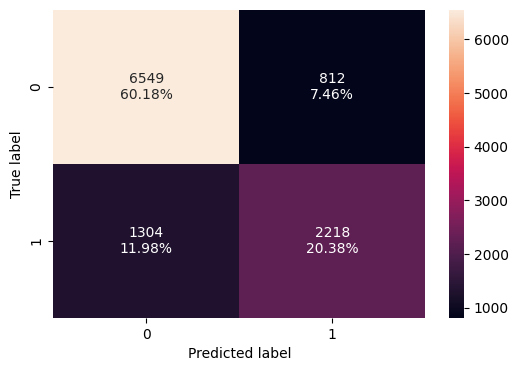

In [179]:
confusion_matrix_sklearn(knn_5, X_test, Y_test)

In [180]:
knn_perf_test_5 = model_performance_classification_sklearn(knn_5, X_test, Y_test)
knn_perf_test_5

,Accuracy,Recall,Precision,F1
0,0.805568,0.629756,0.732013,0.677045


#### **Model Performance Comparison:** **`kNN_k=3`** vs **`kNN_k=5`** vs **`Multiple kNN values`**

In [181]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        knn_perf_train_3.T,
        knn_perf_train_5.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "kNN_k=3",
    "kNN_k=5",
]
print("-"*10, "Training performance comparison", "-"*10)
models_train_comp_df

---------- Training performance comparison ----------


,kNN_k=3,kNN_k=5
Accuracy,0.894494,0.861807
Recall,0.800909,0.719598
Precision,0.868517,0.837928
F1,0.833344,0.774268


In [182]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        knn_perf_test_3.T,
        knn_perf_test_5.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "kNN_k=3",
    "kNN_k=5",
]
print("-"*15, "Test set performance comparison", "-"*15)
models_test_comp_df

--------------- Test set performance comparison ---------------


,kNN_k=3,kNN_k=5
Accuracy,0.804006,0.805568
Recall,0.657581,0.629756
Precision,0.714154,0.732013
F1,0.684701,0.677045


##### Observations:

* The recall scores for both the training and test sets are highest when k=3. This suggests that with k=3, the model performs better at identifying positive instances in both datasets compared to other values of k.

* As the value of k increases beyond 3, the recall scores tend to decrease for both the training and test sets. This indicates a potential risk of the model failing to identify the underlying patterns in the data.

* Based on the observed recall scores, k=3 appears to be the most suitable choice, as it effectively balances the model's ability to capture positive instances while generalizing well to new data.

### **Naive-Bayes Classifier**

#### Build Naive-Bayes Model

In [183]:
nb = GaussianNB()
nb.fit(X_train, Y_train)

GaussianNB()

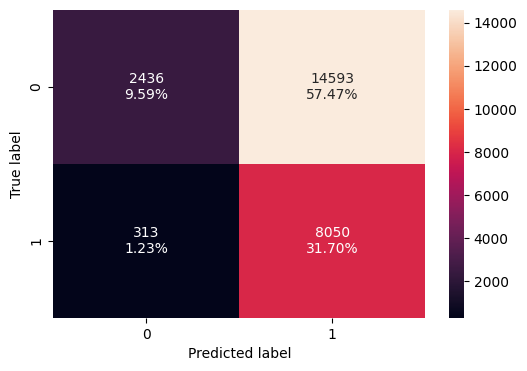

In [184]:
confusion_matrix_sklearn(nb, X_train, Y_train)

In [185]:
nb_perf_train = model_performance_classification_sklearn(nb, X_train, Y_train)
nb_perf_train

,Accuracy,Recall,Precision,F1
0,0.412965,0.962573,0.355518,0.519254


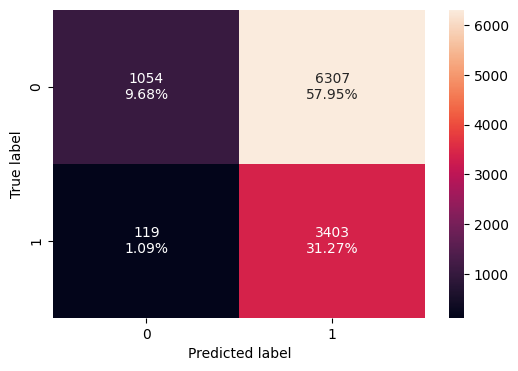

In [186]:
confusion_matrix_sklearn(nb, X_test, Y_test)

In [187]:
nb_perf_test = model_performance_classification_sklearn(nb, X_test, Y_test)
nb_perf_test

,Accuracy,Recall,Precision,F1
0,0.409538,0.966212,0.350463,0.514359


#### **Model Performance Comparison:** **`kNN_k=3`** vs **`Naive Bayes`**

In [188]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        knn_perf_train_3.T,
        nb_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "kNN_k=3",
    "Naive_Bayes",
]
print("-"*10, "Training performance comparison", "-"*10)
models_train_comp_df

---------- Training performance comparison ----------


,kNN_k=3,Naive_Bayes
Accuracy,0.894494,0.412965
Recall,0.800909,0.962573
Precision,0.868517,0.355518
F1,0.833344,0.519254


In [189]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        knn_perf_test_3.T,
        nb_perf_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "kNN_k=3",
    "Naive_Bayes",
]
print("-"*15, "Test set performance comparison", "-"*15)
models_test_comp_df

--------------- Test set performance comparison ---------------


,kNN_k=3,Naive_Bayes
Accuracy,0.804006,0.409538
Recall,0.657581,0.966212
Precision,0.714154,0.350463
F1,0.684701,0.514359


###### Observations:

* In both the training and test sets, the **`k-Nearest Neighbor (kNN) model with k=3`** achieves the *`highest recall`* among all compared models. This demonstrates that the KNN model with k=3 is more effective at correctly identifying positive instances compared to models with other k values and Naive Bayes.

* **`Naive Bayes`** consistently exhibits *`lower recall values than the kNN models`* with varying k values. This suggests that Naive Bayes may struggle to capture positive instances as effectively as kNN models in both training and test datasets, indicating potential limitations in its performance for this specific task.

### **SVM Classifier**

#### **Model Support Functions**

In [190]:
# defining a function to compute different metrics to check performance of a classification model
def model_performance_classification(
    model, predictors, target
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting the class labels.
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [191]:
# defining a function to plot the confusion_matrix of a classification model

def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(y_true=target,y_pred= y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### **SVM(kernel='linear')**

In [192]:
# fitting SVM model
svm = SVC(kernel='linear')
svm.fit(X_train, Y_train)

SVC(kernel='linear')

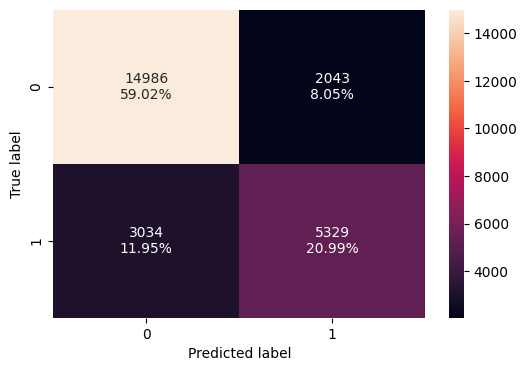

In [193]:
confusion_matrix_sklearn(model=svm, predictors=X_train, target=Y_train)

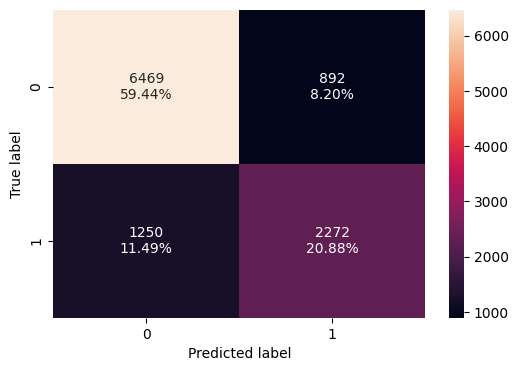

In [194]:
confusion_matrix_sklearn(model=svm, predictors= X_test, target=Y_test)

In [195]:
print("-"*15, "Training performance", "-"*15)
model_lin_kern = model_performance_classification(model=svm, predictors=X_train, target=Y_train)
model_lin_kern

--------------- Training performance ---------------


,Accuracy,Recall,Precision,F1
0,0.800055,0.637212,0.72287,0.677344


In [196]:
print("-"*15, "Test performance", "-"*15)
model_lin_kern_test = model_performance_classification(model=svm, predictors=X_test, target=Y_test)
model_lin_kern_test

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.803179,0.645088,0.718078,0.679629


##### **Observations**

- The train and test f1_score of the model is around 68% and we will try to improve it further

#### **Model Performance Improvement**

* Let's see if the f1_score can be improved further by changing the hyperparameters i.e, the kernel, C and gamma.

#### **SVM(kernel='linear', C=0.001)**

In [197]:
# fitting SVM model
svm = SVC(kernel='linear', C=0.001)
svm.fit(X_train, Y_train)

SVC(C=0.001, kernel='linear')

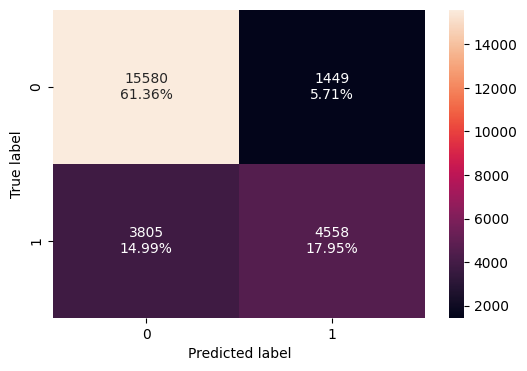

In [198]:
confusion_matrix_sklearn(model=svm,predictors=X_train, target=Y_train)

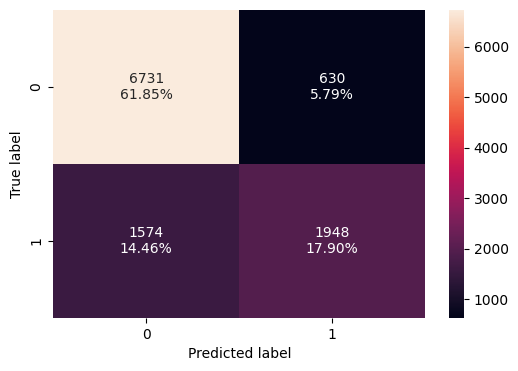

In [199]:
confusion_matrix_sklearn(model=svm,predictors= X_test, target=Y_test)

In [200]:
print("-"*15, "Training performance", "-"*15)
model_lin_kern_c = model_performance_classification(model=svm, predictors=X_train, target=Y_train)
model_lin_kern_c

--------------- Training performance ---------------


,Accuracy,Recall,Precision,F1
0,0.793084,0.54502,0.758781,0.634377


In [201]:
print("-"*15, "Test performance", "-"*15)
model_lin_kern_test_c = model_performance_classification(model=svm, predictors=X_test, target=Y_test)
model_lin_kern_test_c

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.797482,0.553095,0.755625,0.638689


##### **Observations**

* The performance is lower than that of the previous model.

#### **SVM(kernel='linear', C=100)**

In [202]:
# fitting SVM model
svm = SVC(kernel='linear', C=100)
svm.fit(X_train, Y_train)

SVC(C=100, kernel='linear')

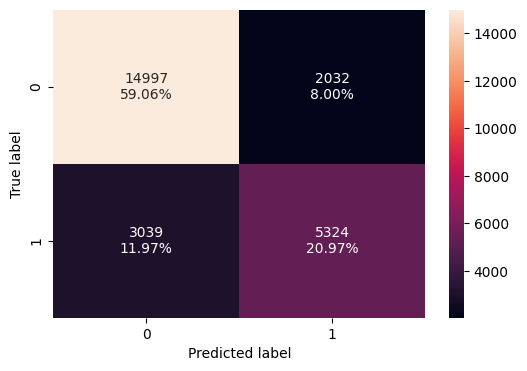

In [203]:
confusion_matrix_sklearn(model=svm,predictors=X_train, target=Y_train)

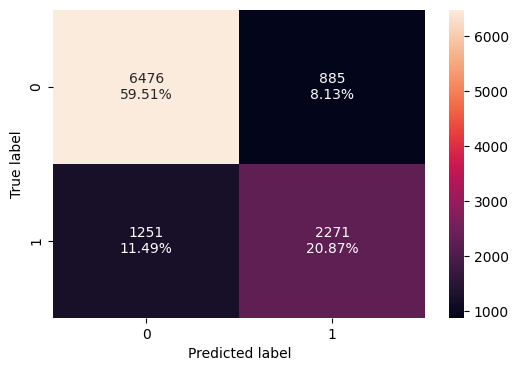

In [204]:
confusion_matrix_sklearn(model=svm,predictors= X_test, target=Y_test)

In [205]:
print("-"*15, "Training performance", "-"*15)
model_lin_kern_c100 = model_performance_classification(model=svm, predictors=X_train, target=Y_train)
model_lin_kern_c100

--------------- Training performance ---------------


,Accuracy,Recall,Precision,F1
0,0.800291,0.636614,0.723763,0.677397


In [206]:
print("-"*15, "Test performance", "-"*15)
model_lin_kern_test_c100 = model_performance_classification(model=svm, predictors=X_test, target=Y_test)
model_lin_kern_test_c100

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.803731,0.644804,0.719582,0.680144


##### **Observations**

* There has been no improvement.

#### **SVM(kernel='poly', degree=2)**

In [207]:
# fitting SVM model
svm = SVC(kernel='poly', degree=2)
svm.fit(X_train, Y_train)

SVC(degree=2, kernel='poly')

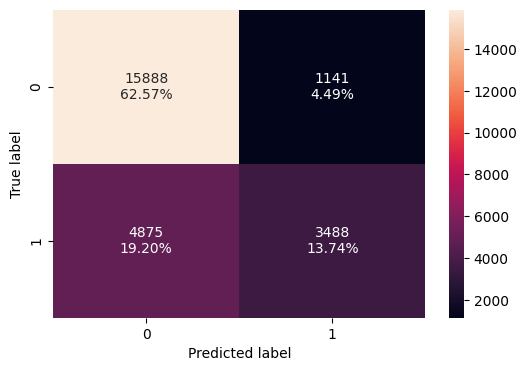

In [208]:
confusion_matrix_sklearn(model=svm, predictors= X_train, target=Y_train)

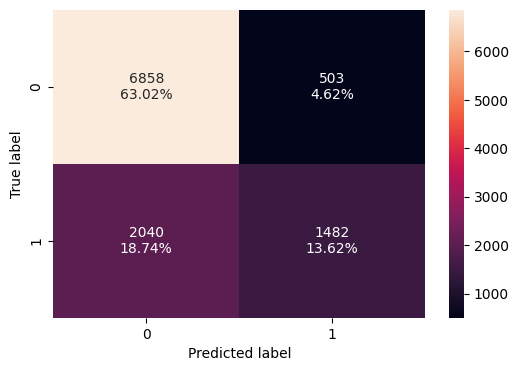

In [209]:
confusion_matrix_sklearn(model=svm, predictors=X_test, target=Y_test)

In [210]:
print("-"*15, "Training performance", "-"*15)
model_poly_kern = model_performance_classification(model=svm, predictors=X_train, target=Y_train)
model_poly_kern

--------------- Training performance ---------------


,Accuracy,Recall,Precision,F1
0,0.763075,0.417075,0.75351,0.536946


In [211]:
print("-"*15, "Test performance", "-"*15)
model_poly_kern_test = model_performance_classification(model=svm, predictors=X_test, target=Y_test)
model_poly_kern_test

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.766333,0.420784,0.746599,0.538224


##### **Observations**

- Both the train and test performance has been not-improved.

Let's increase the degree of the polynomial.

#### **SVM(kernel='poly', degree=3)**

In [212]:
# fitting SVM model
svm = SVC(kernel='poly', degree=3)
svm.fit(X_train, Y_train)

SVC(kernel='poly')

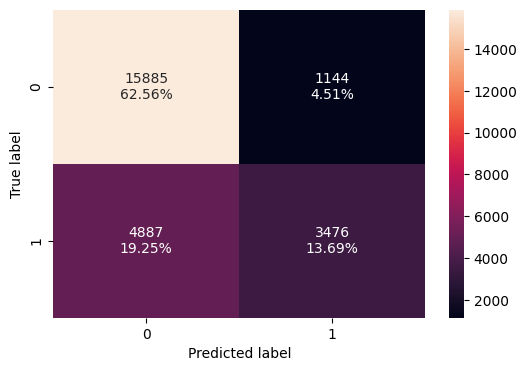

In [213]:
confusion_matrix_sklearn(model=svm,predictors=X_train, target=Y_train)

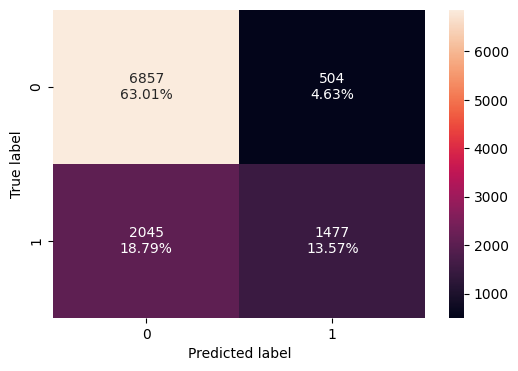

In [214]:
confusion_matrix_sklearn(model=svm,predictors=X_test, target=Y_test)

In [215]:
print("-"*15, "Training performance", "-"*15)
model_poly_kern_3 = model_performance_classification(model=svm, predictors=X_train, target=Y_train)
model_poly_kern_3

--------------- Training performance ---------------


,Accuracy,Recall,Precision,F1
0,0.762484,0.41564,0.752381,0.535469


In [216]:
print("-"*15, "Test performance", "-"*15)
model_poly_kern_3_test = model_performance_classification(model=svm, predictors=X_test, target=y_test)
model_poly_kern_3_test

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.765781,0.419364,0.745583,0.536798


##### **Observations**

* Increasing the degree of the polynomial has not improved performance.

* Let's switch the kernel to RBF.

#### **SVM(kernel='rbf)**

In [217]:
# fitting SVM model
svm = SVC(kernel='rbf')
svm.fit(X_train, Y_train)

SVC()

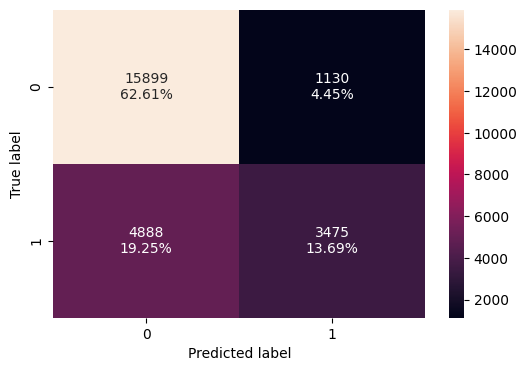

In [218]:
confusion_matrix_sklearn(model=svm,predictors= X_train, target=Y_train)

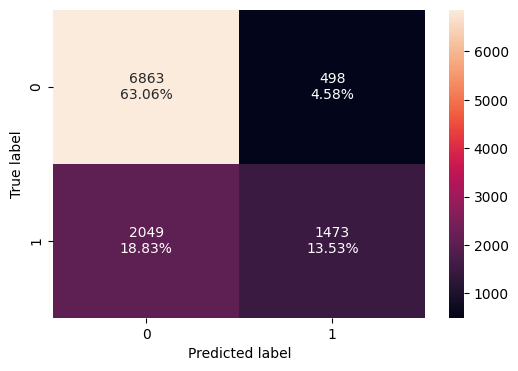

In [219]:
confusion_matrix_sklearn(model=svm,predictors= X_test, target=Y_test)

In [220]:
print("-"*15, "Training performance:", "-"*15)
model_rbf_kern = model_performance_classification(model=svm, predictors=X_train, target=Y_train)
model_rbf_kern

--------------- Training performance: ---------------


,Accuracy,Recall,Precision,F1
0,0.762996,0.415521,0.754615,0.535935


In [221]:
print("-"*15, "Test performance", "-"*15)
model_rbf_kern_test = model_performance_classification(model=svm, predictors=X_test, target=y_test)
model_rbf_kern_test

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.765965,0.418228,0.747336,0.536319


##### **Observations**

* There is not much improvment.

* Let's include degree, gamma, and C.

#### **SVM(kernel='rbf', degree=3, gamma=0.3, c=0.1)**

In [222]:
# fitting SVM model
svm = SVC(kernel='rbf', degree=3, gamma=0.3, C=0.1)
svm.fit(X_train, Y_train)

SVC(C=0.1, gamma=0.3)

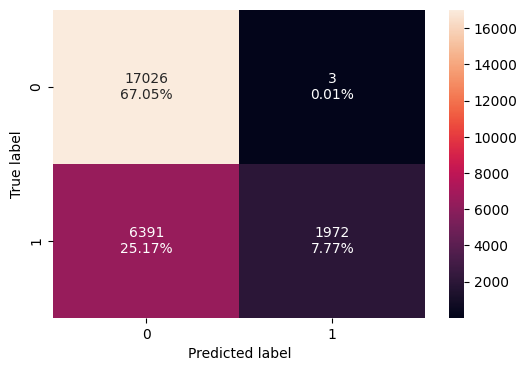

In [223]:
confusion_matrix_sklearn(model=svm, predictors=X_train, target=Y_train)

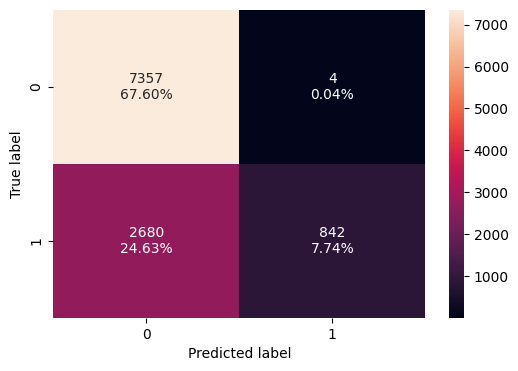

In [224]:
confusion_matrix_sklearn(model=svm,predictors=X_test, target=Y_test)

In [225]:
print("-"*15, "Training performance", "-"*15)
model_rbf_gamma = model_performance_classification(model=svm, predictors=X_train, target=Y_train)
model_rbf_gamma

--------------- Training performance ---------------


,Accuracy,Recall,Precision,F1
0,0.748188,0.235801,0.998481,0.381505


In [226]:
print("-"*15, "Test performance", "-"*15)
model_rbf_gamma_test = model_performance_classification(model=svm, predictors=X_test, target=Y_test)
model_rbf_gamma_test

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.753377,0.239069,0.995272,0.385531


##### **Observations**

- Eventhough the performance is not as good as before, the difference in the train and test scores is very less comparitively.

Let's increase the value of gamma.

#### **SVM(kernel='poly', degree=3, gamma=0.001)**

In [227]:
# fitting SVM model
svm = SVC(kernel='poly', degree=3, gamma=0.001)
svm.fit(X_train, Y_train)

SVC(gamma=0.001, kernel='poly')

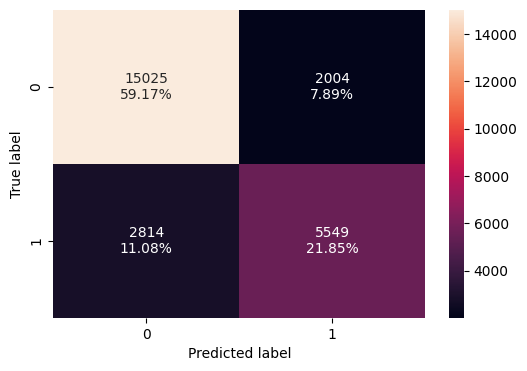

In [228]:
confusion_matrix_sklearn(model=svm, predictors=X_train, target=Y_train)

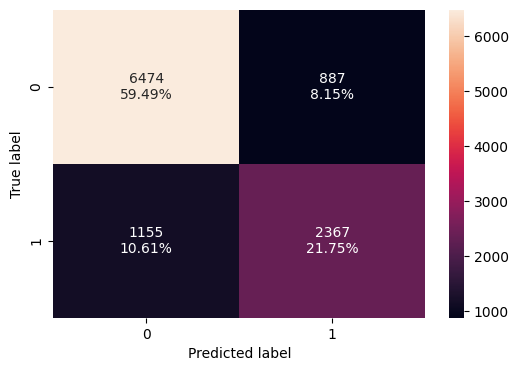

In [229]:
confusion_matrix_sklearn(model=svm,predictors=X_test, target=Y_test)

In [230]:
print("-"*15, "Training performance", "-"*15)
model_poly_gamma = model_performance_classification(model=svm, predictors=X_train, target=Y_train)
model_poly_gamma

--------------- Training performance ---------------


,Accuracy,Recall,Precision,F1
0,0.810255,0.663518,0.734675,0.697286


In [231]:
print("-"*15, "Test performance", "-"*15)
model_poly_gamma_test = model_performance_classification(model=svm, predictors=X_test, target=Y_test)
model_poly_gamma_test

--------------- Test performance ---------------


,Accuracy,Recall,Precision,F1
0,0.812368,0.672061,0.727412,0.698642


##### Observations:

* The performance of the above model has improved.

* Let's try gamma=0.005

#### **Model Performance Comparison:** `All SVM models`

In [232]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_lin_kern.T,
        model_lin_kern_c.T,
        model_lin_kern_c100.T,
        model_poly_kern.T,
        model_poly_kern_3.T,
        model_poly_gamma.T,
        model_rbf_kern.T,
        model_rbf_gamma.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "kernel=linear",
    "kernel=linear, C=0.001",
    "kernel=linear, C=100",
    "kernel=poly, degree=2",
    "kernel=poly, degree=3",
    "kernel=poly, degree=3, gamma=0.001",
    "kernel=rbf",
    "kernel=rbf,  degree=3, gamma=0.3, c=0.1"
]

print("Training performance comparison")
models_train_comp_df

Training performance comparison


,kernel=linear,"kernel=linear, C=0.001","kernel=linear, C=100","kernel=poly, degree=2","kernel=poly, degree=3","kernel=poly, degree=3, gamma=0.001",kernel=rbf,"kernel=rbf, degree=3, gamma=0.3, c=0.1"
Accuracy,0.800055,0.793084,0.800291,0.763075,0.762484,0.810255,0.762996,0.748188
Recall,0.637212,0.545020,0.636614,0.417075,0.415640,0.663518,0.415521,0.235801
Precision,0.722870,0.758781,0.723763,0.753510,0.752381,0.734675,0.754615,0.998481
F1,0.677344,0.634377,0.677397,0.536946,0.535469,0.697286,0.535935,0.381505


In [233]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
      model_lin_kern_test.T,
      model_lin_kern_test_c.T,
      model_lin_kern_test_c100.T,
      model_poly_kern_test.T,
      model_poly_kern_3_test.T,
      model_poly_gamma_test.T,
      model_rbf_kern_test.T,
      model_rbf_gamma_test.T
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "kernel=linear",
    "kernel=linear, C=0.001",
    "kernel=linear, C=100",
    "kernel=poly, degree=2",
    "kernel=poly, degree=3",
    "kernel=poly, degree=3, gamma=0.001",
    "kernel=rbf",
    "kernel=rbf,  degree=3, gamma=0.3, c=0.1"
]

print("Test set performance comparison")
models_test_comp_df

Test set performance comparison


,kernel=linear,"kernel=linear, C=0.001","kernel=linear, C=100","kernel=poly, degree=2","kernel=poly, degree=3","kernel=poly, degree=3, gamma=0.001",kernel=rbf,"kernel=rbf, degree=3, gamma=0.3, c=0.1"
Accuracy,0.803179,0.797482,0.803731,0.766333,0.765781,0.812368,0.765965,0.753377
Recall,0.645088,0.553095,0.644804,0.420784,0.419364,0.672061,0.418228,0.239069
Precision,0.718078,0.755625,0.719582,0.746599,0.745583,0.727412,0.747336,0.995272
F1,0.679629,0.638689,0.680144,0.538224,0.536798,0.698642,0.536319,0.385531


- All the models performed well on both training and test data.
- The model ( SVM-Polynomial Kernel , degree = 3 , gamma = 0.3 ) is the best in terms of the train and test scores.


## Model Performance Comparison and Final Model Selection

### **Analysis for Each Models**

---

#### **1. Logistic Regression**
* **Best Model:** Threshold = 0.37  
  * **Test Recall:** **74**  
  * **Test Precision:** **67**  
  * **Test F1 Score:** **70**  

* **Pros:**  
  * High recall (captures more true cancellations) with balanced precision.  
  * Best F1 Score among all models, ensuring reduced false positives and false negatives.  

* **Cons:**  
  * Recall is slightly lower than Naïve-Bayes (97), but the trade-off for precision makes it more reliable.  

---

#### **2. k-Nearest Neighbors (k-NN)**
* **Best Model:** k = 3  
  * **Test Recall:** **66**  
  * **Test Precision:** **71**  
  * **Test F1 Score:** **69**  

* **Pros:**  
  * Good balance of precision and recall, comparable to Logistic Regression.  
  * Simplicity in implementation.  

* **Cons:**  
  * Recall is lower than Logistic Regression (74), leading to more false negatives.  
  * Performance drops slightly when k = 5 (F1 = 68).  

---

#### **3. Naïve-Bayes (GaussianNB)**
* **Performance:**  
  * **Test Recall:** **97** (highest recall).  
  * **Test Precision:** **35** (very low).  
  * **Test F1 Score:** **51**.  

* **Pros:**  
  * Extremely high recall, meaning almost all cancellations are predicted correctly.  

* **Cons:**  
  * Very low precision leads to many false positives (predicting cancellations that don’t happen).  
  * F1 Score is the worst among all models, making it unreliable for balanced decision-making.  

---

#### **4. Support Vector Machine (SVM)**
* **Best Model:** Kernel = Poly (degree = 3, gamma = 0.001)  
  * **Test Recall:** **67**  
  * **Test Precision:** **73**  
  * **Test F1 Score:** **70**  

* **Pros:**  
  * Recall and F1 score are comparable to Logistic Regression.  
  * Performs well with non-linear relationships in the data.  

* **Cons:**  
  * Slightly lower recall than Logistic Regression (74).  
  * Requires more computational resources compared to Logistic Regression and k-NN.  

---

### **Final Recommendation**

#### **1. Primary Choice:** **Logistic Regression (Threshold = 0.37)**  
* Balanced performance with the best F1 Score (70) and high recall (74).  
* Simpler to implement and computationally efficient.  

#### **2. Alternative Choice:** **SVM (Poly kernel, degree=3, gamma=0.001)**  
* Use this model if the dataset has non-linear patterns that Logistic Regression cannot capture effectively.  

#### **3. Reserve Option:** **k-NN (k = 3)**  
* Use this as a fallback if simplicity and interpretability are critical.  

#### **4. Avoid:** **Naïve-Bayes (GaussianNB)** due to its extremely low F1 Score (51).  

---

## **Actionable Insights & Recommendations**

### **Conclusions & Recommendations:**
---

#### **Guest Behavior and Booking Trends:**
- Our exploratory data analysis and predictive models reveal key trends:
  - Guests booking **cheaper rooms**, with **shorter lead times**, requiring **parking**, being **repeat guests**, making **more special requests**, and booking through **corporate or offline channels** are **less likely to cancel**.
  - Conversely, guests booking **expensive rooms**, with **longer lead times**, and using **online channels** are **more likely to cancel**.

---

#### **Policy Recommendations for Cancellations and Refunds:**
- **Dynamic Refund Policy:**
  - Implement a sliding refund scale where the refund amount decreases as the check-in date approaches. This encourages early cancellations, allowing for room rebooking opportunities.

- **Flexible Modification Options:**
  - Introduce policies that allow customers to modify reservations (e.g., dates or room type) up to a certain date before check-in to reduce cancellations caused by minor changes.

- **Non-Refundable Fees for Long Lead Times:**
  - For bookings made **150-200 days in advance**, include a **non-refundable fee** to minimize cancellations.

---

#### **Strategies to Attract and Retain Customers:**
- **Loyalty Programs:**
  - Offer rewards, discounts, or free stays based on a points system to encourage repeat bookings.
  - Waive non-refundable fees for repeat customers or provide additional perks such as complimentary breakfasts.

- **Targeted Marketing:**
  - Focus on attracting **repeat customers**, as data shows they are far less likely to cancel. A loyalty program with promotions and discounts can build long-term brand loyalty.
  - Design promotional campaigns during the **off-season** (e.g., winter months) to boost occupancy rates with attractive deals.
  - Highlight **kid-friendly amenities**, like a dedicated kids' room, to attract families and reduce cancellations.

---

#### **Operational Adjustments:**
- **Resource Allocation:**
  - Align staffing levels and resources with booking patterns to maintain high service quality. For **peak seasons**, hire additional staff, and during **off-peak periods**, optimize operations to reduce costs.

- **Customer Experience:**
  - Enhance customer service by accommodating special requests, ensuring satisfaction, and increasing retention rates.

---

#### **Revenue Optimization:**
- **Online Booking Premiums:**
  - Add a small premium to **online reservations**, as they constitute **64% of bookings** but have the highest cancellation rates (~35%).

- **Business Traveler Rewards:**
  - Develop incentives tailored for **business travelers**, such as discounts for frequent bookings, to enhance loyalty and reduce cancellations.

---

#### **Continuous Improvement:**
- **Cancellation Analysis:**
  - Regularly analyze the reasons behind cancellations and refine policies to address key drivers.

- **Price Strategy:**
  - Keep prices competitive during **high-demand periods** to attract more customers and reduce the likelihood of cancellations.

---

By implementing these strategies, **INN Hotels** can optimize its operations, increase revenue, and minimize cancellations while enhancing guest satisfaction.
